# nb08 — EDA Externe Factoren: Weer, Kalender & Events
**Masterproef:** Tier-Stratified Occupancy Prediction and Scenario-Based Policy Simulation  
**Auteur:** Emile Van de Voorde  
**Dataset:** MAD_shortterm.parquet (284.524 × 63 kol.)  
**Trainingsset:** 129.837 rijen (jaren 2020/2023/2024, kwaliteitsflags=0)  
**Fase:** 2 — EDA | Voorafgegaan door nb05 (temporele EDA) en nb06 (EDA per parking)

---

### Centrale onderzoeksvraag
> Welke externe factoren (weer, kalender, events) zijn **statistisch aantoonbaar
> geassocieerd** met bezettingsgraad in Mechelen — en verschilt dat verband
> systematisch per tier (centrum vs. vesten_of_rand)?

EDA kan geen causaliteit aantonen; bevindingen zijn associatief.
Confirmatieve analyses volgen in nb09+.
Referentie: James et al. (2021); Zhao et al. (2024)

---

### Tier-definitie (conform nb05/nb06)
| Tier (origineel) | Tier (nb07) | Parkings |
|---|---|---|
| centrum | centrum | P Grote Markt, P Hoogstraat, P Kathedraal, P Lamot, P Veemarkt |
| vesten | vesten_of_rand | P Bruul, P Komet, P Maarten, P Tinel |
| rand | vesten_of_rand | P Keerdok |

**Motivatie samenvoeging:** 1 rand-parking onvoldoende voor aparte tier
(Field, 2013; Conover, 1999)

---

### Databeperkingen (expliciet)
1. `data_confidence = "estimated"` voor 185 events → robuustheidscheck in cel 08
2. Weerdata start 2020-01-01 → geen pre-2020 weeranalyse
3. P Zandpoortvest: geen tijdreeksdata → vesten_of_rand capaciteit onderschat
4. Frozen sensor rijen: gefilterd via trainingsfilter
5. EDA-scope: geen feature engineering (nb08), geen modellering (nb09+)

---

### Hypothesen (H-E1 t/m H-E9)
| Code | Hypothese | Cel | Toets |
|---|---|---|---|
| H-E1 | Neerslageffect niet-lineair | 02 | KW + MW + kwadratische OLS |
| H-E2 | Temperatuureffect seizoensgebonden | 03 | Spearman ρ per seizoen + LOWESS |
| H-E3 | Cascade: bezetting ↑ VOOR event, ↓ NA event | 08 | Event-lag profiel + t-toets |
| H-E4 | Feestdagen: +vesten_of_rand, −centrum | 07 | MW + Fischer z |
| H-E5 | VIF(temp_c × month) > 5 | 10 | OLS VIF |
| H-E6 | Wind > 10 m/s → modal shift naar auto | 05 | Drempel-MW + Spearman |
| H-E7 | Zon negatief effect in zomer | 06 | Spearman + partiële correlatie |
| H-E8 | Schoolvakanties: centrum ↓, vesten_of_rand neutraal/↑ | 07 | MW + Fischer z |
| H-E9 | Eventeffect schaalafhankelijk | 08 | Spearman ρ schaal vs. piek |

---

### Kernreferenties
Oz (2023); Correia et al. (2020); Böcker et al. (2013); Balmer et al. (2021);
Fokker et al. (2021); Zhang et al. (2024); Channamallu et al. (2024);
Tanui et al. (2025); James et al. (2021); Wan et al. (2023);
Cleveland et al. (1979); Field (2013); Cohen (1988); Fischer (1921);
Wilcoxon (1945); Breiman (2001); Strobl et al. (2007); Altmann et al. (2010);
Rosenthal (1991); Agresti & Finlay (2009); Zhao et al. (2024); Niu et al. (2023)


In [1]:
# ─── Cel 01: Config + data laden ─────────────────────────────────────────────
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.parent.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.project_config import get_project_paths
from src.io.phase2_readers import read_mad_shortterm, read_parking_location_clean
from src.phase2.common import (
    apply_train_filter,
    add_tier_column,
    add_day_type_3,
    add_season_column,
    get_eda_figure_dir,
)
from src.phase2.constants import TIER_ORDER, TIER_COLORS, SEASON_ORDER, SEASON_COLORS
from src.phase2.external_factors import (
    assign_precip_bin,
    assign_temp_bin,
    build_delta_profile,
    cyclic_encode,
    compute_vif,
    scale_to_num,
)
from src.phase2.stats import fisher_z, status, fmt_float, fmt_p

paths = get_project_paths(PROJECT_ROOT)
ROOT = paths.root
DATA_PROC = paths.data_processed
DATA_INT = paths.data_intermediate
FIGS = get_eda_figure_dir(paths, "nb08")

df_short = read_mad_shortterm(PROJECT_ROOT)
df_loc = read_parking_location_clean(PROJECT_ROOT)

df_train = apply_train_filter(df_short)
df_train = add_tier_column(df_train)
df_train = add_day_type_3(df_train)
df_train = add_season_column(df_train)

print(f"ROOT      : {ROOT}")
print(f"DATA_PROC : {DATA_PROC}")
print(f"DATA_INT  : {DATA_INT}")
print(f"FIGS      : {FIGS}")


ROOT      : /Users/emilevandevoorde/Documents/mechelen_parking
DATA_PROC : /Users/emilevandevoorde/Documents/mechelen_parking/data_processed
DATA_INT  : /Users/emilevandevoorde/Documents/mechelen_parking/data_intermediate
FIGS      : /Users/emilevandevoorde/Documents/mechelen_parking/figures/eda/nb08


## Cel 02 — Neerslageffect per tier (H-E1)

> *H-E1: Het neerslageffect op parkeeroccupantie is **niet-lineair**:
> lichte regen (<2 mm/u) gaat gepaard met marginaal hogere bezetting
> (auto ipv fiets), terwijl zware regen (>10 mm/u) geassocieerd is met
> lagere bezetting (algemeen mobiliteitssuppressie).*

**Referentie:** Oz (2023) toonde voor on-street parkeren dat lichte regen
bezetting licht verhoogt (modal shift fiets→auto), terwijl extreme neerslag
de totale verplaatsingsvraag onderdrukt. Correia et al. (2020) bevestigden
dit drempelgedrag voor collectief stadsvervoer.

### Binning-strategie

| Bin | Drempel | Label | Motivatie |
|---|---|---|---|
| 0 | precip == 0 mm | droog | Oz (2023): basisniveau |
| 1 | 0 < precip ≤ 2 mm | licht | Oz (2023): fiets→auto shift |
| 2 | 2 < precip ≤ 10 mm | matig | Oz (2023): overgangszone |
| 3 | precip > 10 mm | zwaar | Correia (2020): suppressie |

### Statistische toets

**Kruskal-Wallis over 4 neerslag-bins:**
Bezettingsdata is [0,1]-begrensd en rechtsschief → normaliteitsaanname
niet haalbaar → niet-parametrische one-way ANOVA (Kruskal & Wallis, 1952).

$ H = \frac{12}{n(n+1)} \sum_{j=1}^{k} \frac{R_j^2}{n_j} - 3(n+1) $

Effect size η²:
$ \eta^2 = \frac{H - k + 1}{n - k} $
(Cohen, 1988): 0.01=klein, 0.06=medium, 0.14=groot

**Pairwise Mann-Whitney (droog vs. zwaar):**
Bij gerichte hypothese (H-E1: droog vs. zwaar) volstaat een directe
pairwise MW-toets + rank-biseriale r als effect size (Field, 2013):
$ r_{rb} = \frac{2U}{n_1 \cdot n_2} - 1 $

**Niet-lineariteitstest via kwadratische OLS:**
Om de U-vormige curve te objectiveren aggregeren we per bin het
gemiddelde en fitten we:
$ \hat{Y} = \beta_0 + \beta_1 X + \beta_2 X^2 $
Als β₂ significant is (p < 0.05), is er bewijs voor niet-lineariteit
(James et al., 2021).

**Verwachte bevinding:** Mediaan bezetting: licht > droog > matig > zwaar
→ omgekeerde U-curve → β₂ < 0, significant.


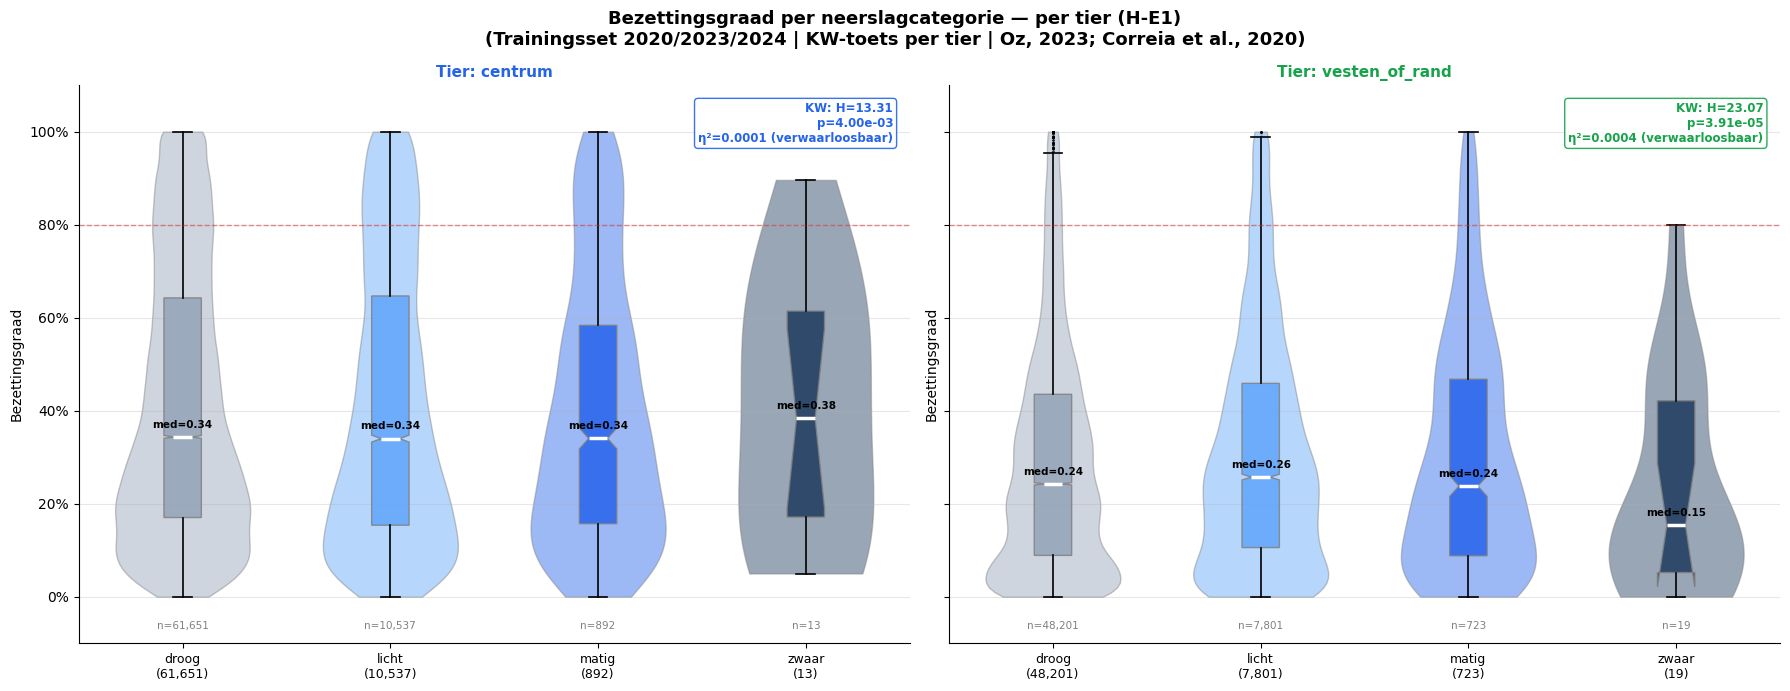

── H-E1: Pairwise MW droog vs. zwaar per tier ──
  centrum: droog med=0.344, zwaar med=0.383, Δ=-0.040, MW p=8.96e-01, r_rb=0.0210
  vesten_of_rand: droog med=0.243, zwaar med=0.154, Δ=+0.089, MW p=1.57e-01, r_rb=0.1876

── H-E1: Kwadratische OLS niet-lineariteitstest ──
  centrum: β₂=0.000266, p(β₂)=0.0664 → LINEAIR
  vesten_of_rand: β₂=-0.000611, p(β₂)=0.1746 → LINEAIR

✓ Opgeslagen: fig_precip_effect.png, tabel_precip_kw/mw/ols.csv


In [2]:
# ─── Cel 02: Neerslageffect per tier (H-E1) ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import kruskal, mannwhitneyu
import statsmodels.api as sm

# ── Neerslagbins (Oz, 2023; Correia et al., 2020) ────────────────────────────

df_train["precip_bin"] = df_train["precip_mm"].apply(assign_precip_bin)
PRECIP_ORDER  = ["droog", "licht", "matig", "zwaar"]
PRECIP_COLORS = ["#94A3B8", "#60A5FA", "#2563EB", "#1E3A5F"]

# ── Plot: violin + boxplot per neerslag-bin per tier ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
fig.suptitle(
    "Bezettingsgraad per neerslagcategorie — per tier (H-E1)\n"
    "(Trainingsset 2020/2023/2024 | KW-toets per tier | Oz, 2023; Correia et al., 2020)",
    fontsize=13, fontweight="bold"
)

kw_results_precip = []

for ax_idx, tier in enumerate(TIER_ORDER):
    ax = axes[ax_idx]
    df_t = df_train[(df_train["tier"] == tier) &
                    (df_train["precip_bin"].notna())]

    box_data = [df_t[df_t["precip_bin"] == b]["occupancy_rate"].dropna().values
                for b in PRECIP_ORDER]
    n_per_bin = [len(d) for d in box_data]

    # Kruskal-Wallis over 4 bins
    groups_valid = [(b, d) for b, d in zip(PRECIP_ORDER, box_data) if len(d) > 0]
    kw_stat, kw_p = kruskal(*[d for _, d in groups_valid])
    n_tot = sum(n_per_bin)
    eta2  = (kw_stat - len(groups_valid) + 1) / (n_tot - len(groups_valid))
    eta2_label = ("groot" if eta2 >= 0.14 else "medium" if eta2 >= 0.06
                  else "klein" if eta2 >= 0.01 else "verwaarloosbaar")

    # Violin plot
    vp = ax.violinplot(
        [d for d in box_data if len(d) > 0],
        positions=range(len([d for d in box_data if len(d) > 0])),
        widths=0.65, showmedians=False, showextrema=False
    )
    valid_bins  = [b for b, d in zip(PRECIP_ORDER, box_data) if len(d) > 0]
    valid_colors= [PRECIP_COLORS[PRECIP_ORDER.index(b)] for b in valid_bins]
    for body, color in zip(vp["bodies"], valid_colors):
        body.set_facecolor(color); body.set_alpha(0.45); body.set_edgecolor("gray")

    # Boxplot overlay
    bp = ax.boxplot(
        [d for d in box_data if len(d) > 0],
        positions=range(len(valid_bins)),
        widths=0.18, patch_artist=True, notch=True,
        medianprops=dict(color="white", lw=2.5),
        whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
        flierprops=dict(marker=".", markersize=1, alpha=0.15),
    )
    for patch, color in zip(bp["boxes"], valid_colors):
        patch.set_facecolor(color); patch.set_alpha(0.85); patch.set_edgecolor("gray")

    # Mediaan-lijn + n-annotatie
    for i, (b, d) in enumerate(zip(valid_bins, [box_data[PRECIP_ORDER.index(b)] for b in valid_bins])):
        med = np.median(d)
        ax.text(i, med + 0.02, f"med={med:.2f}", ha="center",
                fontsize=7.5, color="black", fontweight="bold")
        ax.text(i, -0.07, f"n={len(d):,}", ha="center",
                fontsize=7.5, color="gray")

    # KW-resultaat
    ax.text(0.98, 0.97,
            f"KW: H={kw_stat:.2f}\np={kw_p:.2e}\nη²={eta2:.4f} ({eta2_label})",
            ha="right", va="top", transform=ax.transAxes,
            fontsize=8.5, fontweight="bold", color=TIER_COLORS[tier],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=TIER_COLORS[tier], alpha=0.9))

    kw_results_precip.append({
        "tier": tier, "kw_stat": round(kw_stat, 4),
        "kw_p": round(kw_p, 6), "eta2": round(eta2, 4),
        "eta2_label": eta2_label, "n_total": n_tot
    })

    ax.set_xticks(range(len(valid_bins)))
    ax.set_xticklabels(
        [f"{b}\n({n:,})" for b, n in zip(valid_bins,
         [len(box_data[PRECIP_ORDER.index(b)]) for b in valid_bins])],
        fontsize=9
    )
    ax.set_title(f"Tier: {tier}", fontsize=11, fontweight="bold",
                 color=TIER_COLORS[tier])
    ax.set_ylabel("Bezettingsgraad", fontsize=10)
    ax.set_ylim(-0.10, 1.10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.axhline(0.80, color="#DC2626", lw=1, ls="--", alpha=0.5,
               label="80% drempel")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / "fig_precip_effect.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Mann-Whitney: droog vs. zwaar (pairwise gerichte toets) ───────────────────
print("── H-E1: Pairwise MW droog vs. zwaar per tier ──")
mw_precip_results = []
for tier in TIER_ORDER:
    df_t   = df_train[df_train["tier"] == tier]
    droog  = df_t[df_t["precip_bin"] == "droog"]["occupancy_rate"].dropna().values
    zwaar  = df_t[df_t["precip_bin"] == "zwaar"]["occupancy_rate"].dropna().values
    if len(zwaar) < 10:
        print(f"  {tier}: onvoldoende zware-regen data (n={len(zwaar)})")
        continue
    stat, p = mannwhitneyu(droog, zwaar, alternative="two-sided")
    n1, n2  = len(droog), len(zwaar)
    r_rb    = (2 * stat) / (n1 * n2) - 1
    mw_precip_results.append({
        "tier": tier, "n_droog": n1, "n_zwaar": n2,
        "med_droog": round(np.median(droog), 4),
        "med_zwaar": round(np.median(zwaar), 4),
        "delta_med": round(np.median(droog) - np.median(zwaar), 4),
        "mw_p": round(p, 6), "r_rb": round(r_rb, 4)
    })
    print(f"  {tier}: droog med={np.median(droog):.3f}, zwaar med={np.median(zwaar):.3f}, "
          f"Δ={np.median(droog)-np.median(zwaar):+.3f}, MW p={p:.2e}, r_rb={r_rb:.4f}")

# ── Niet-lineariteitstest: kwadratische OLS op bin-gemiddelden ────────────────
print("\n── H-E1: Kwadratische OLS niet-lineariteitstest ──")
ols_precip_results = []
bin_midpoints = [0, 1, 6, 15]  # representatieve mm-waarden per bin

for tier in TIER_ORDER:
    df_t   = df_train[df_train["tier"] == tier]
    y_vals = [df_t[df_t["precip_bin"] == b]["occupancy_rate"].mean()
              for b in PRECIP_ORDER]
    y_vals = [y for y in y_vals if not np.isnan(y)]
    x_vals = bin_midpoints[:len(y_vals)]

    X = np.array(x_vals)
    Y = np.array(y_vals)
    X_ols = sm.add_constant(np.column_stack([X, X**2]))
    model = sm.OLS(Y, X_ols).fit()

    beta2 = model.params[2] if len(model.params) > 2 else np.nan
    p_beta2 = model.pvalues[2] if len(model.pvalues) > 2 else np.nan
    ols_precip_results.append({
        "tier": tier, "beta_2": round(beta2, 6), "p_beta2": round(p_beta2, 4),
        "niet_lineair": bool(p_beta2 < 0.05) if not np.isnan(p_beta2) else "N/A"
    })
    print(f"  {tier}: β₂={beta2:.6f}, p(β₂)={p_beta2:.4f} "
          f"→ {'NIET-LINEAIR ✅' if p_beta2 < 0.05 else 'LINEAIR'}")

# ── Exports ───────────────────────────────────────────────────────────────────
df_precip_kw = pd.DataFrame(kw_results_precip)
df_precip_mw = pd.DataFrame(mw_precip_results)
df_precip_ols= pd.DataFrame(ols_precip_results)

df_precip_kw.to_csv(FIGS / "tabel_precip_kw.csv",  index=False)
df_precip_mw.to_csv(FIGS / "tabel_precip_mw.csv",  index=False)
df_precip_ols.to_csv(FIGS/ "tabel_precip_ols.csv", index=False)
print("\n✓ Opgeslagen: fig_precip_effect.png, tabel_precip_kw/mw/ols.csv")


## Cel 03 — Temperatuureffect per seizoen (H-E2)

> *H-E2: Het verband tussen temperatuur en parkeeroccupantie is
> **seizoensgebonden**: positief in winter (auto ipv fiets bij koude),
> negatief in zomer (minder winkelbezoek bij hitte of meer actief transport).*

**Referentie:** Balmer et al. (2021) vonden dat weercontext sterk afhangt
van seizoen bij on-street parkeren. Channamallu et al. (2024) rangschikten
seizoen en dag-van-de-week als top-2 features via Random Forest.

### Seizoensdefinitie (meteorologisch, WMO-conventie)
| Seizoen | Maanden | Afkorting |
|---|---|---|
| Winter | december, januari, februari | DJF |
| Lente | maart, april, mei | MAM |
| Zomer | juni, juli, augustus | JJA |
| Herfst | september, oktober, november | SON |

### Spearman ρ (niet-parametrisch)
Verwacht niet-lineair verband temp × bezetting → Spearman boven Pearson
(Conover, 1999; Field, 2013):
\[ \rho_s = 1 - \frac{6 \sum d_i^2}{n(n^2-1)} \]
waarbij d_i = verschil in rang.

### LOWESS smoothing
Niet-parametrische trendlijn (Cleveland et al., 1979):
\[ \hat{y}(x_0) = \arg\min_a \sum_{i} K_h(x_i - x_0)(y_i - a - b(x_i-x_0))^2 \]
met tricubic kernel K_h en bandbreedte frac=0.3.

**Verwachting:** ρ positief in winter, negatief in zomer.
Als teken verschilt → interactieterm temp_c × seizoen nodig in nb08.


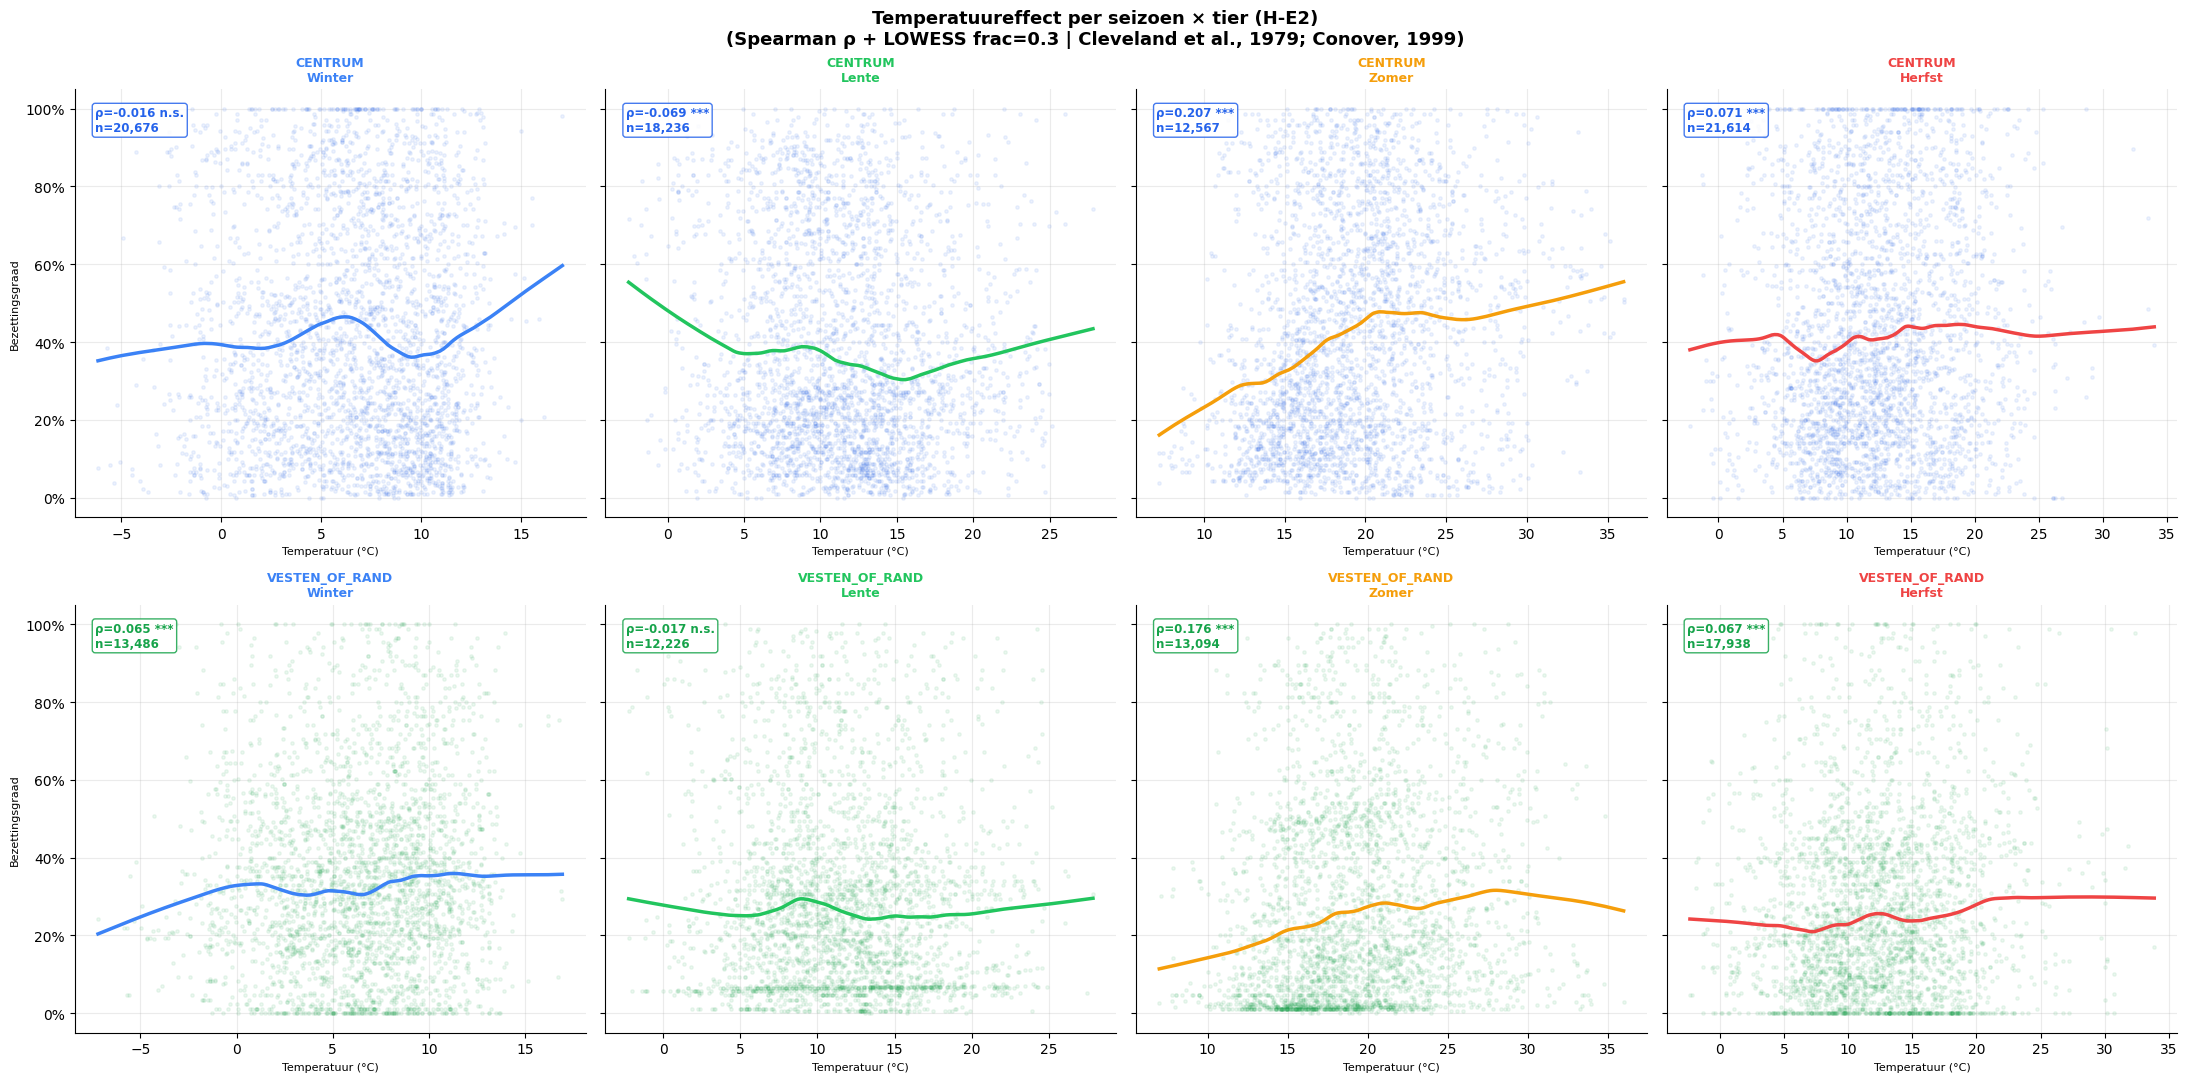

── H-E2: Spearman ρ per tier × seizoen ──
season          winter   lente   zomer  herfst
tier                                          
centrum        -0.0160 -0.0692  0.2068  0.0707
vesten_of_rand  0.0648 -0.0166  0.1759  0.0668

── Teken-wisseling (winter positief + zomer negatief)? ──
  centrum: winter ρ=-0.016, zomer ρ=0.207 → geen tekenwisseling
  vesten_of_rand: winter ρ=0.065, zomer ρ=0.176 → geen tekenwisseling

✓ Opgeslagen: fig_temp_season.png, tabel_temp_spearman.csv


In [3]:
# ─── Cel 03: Temperatuureffect per seizoen (H-E2) ────────────────────────────
import seaborn as sns
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(2, 4, figsize=(22, 11), sharey=True)
fig.suptitle(
    "Temperatuureffect per seizoen × tier (H-E2)\n"
    "(Spearman ρ + LOWESS frac=0.3 | Cleveland et al., 1979; Conover, 1999)",
    fontsize=13, fontweight="bold"
)

spearman_temp_results = []

for tier_idx, tier in enumerate(TIER_ORDER):
    for seas_idx, season in enumerate(SEASON_ORDER):
        ax = axes[tier_idx][seas_idx]

        sub = df_train[
            (df_train["tier"] == tier) &
            (df_train["season"] == season) &
            df_train["temp_c"].notna() &
            df_train["occupancy_rate"].notna()
        ]

        if len(sub) < 50:
            ax.text(0.5, 0.5, "Onvoldoende\ndata",
                    ha="center", va="center", transform=ax.transAxes)
            continue

        # Stratificeerde sample voor snelheid
        np.random.seed(42)
        idx = np.random.choice(len(sub), size=min(3000, len(sub)), replace=False)
        sub_s = sub.iloc[idx]

        # Scatter (alpha laag voor densiteitsvisualisatie)
        ax.scatter(sub_s["temp_c"], sub_s["occupancy_rate"],
                   color=TIER_COLORS[tier], alpha=0.08, s=6, zorder=2)

        # LOWESS trendlijn (Cleveland et al., 1979)
        sorted_temp = sub_s["temp_c"].values
        sorted_occ  = sub_s["occupancy_rate"].values
        lw_result   = lowess(sorted_occ, sorted_temp, frac=0.3, it=3,
                             return_sorted=True)
        ax.plot(lw_result[:, 0], lw_result[:, 1],
                color=SEASON_COLORS[season], lw=2.5, zorder=5,
                label="LOWESS")

        # Spearman ρ
        rho, p_rho = spearmanr(sub_s["temp_c"], sub_s["occupancy_rate"])

        spearman_temp_results.append({
            "tier": tier, "season": season,
            "n_obs": len(sub),
            "spearman_rho": round(rho, 4),
            "p_value": round(p_rho, 6),
            "significant": p_rho < 0.05,
            "direction": "positief" if rho > 0 else "negatief"
        })

        sig_star = ("***" if p_rho < 0.001 else "**" if p_rho < 0.01
                    else "*" if p_rho < 0.05 else "n.s.")
        ax.text(0.04, 0.96, f"ρ={rho:.3f} {sig_star}\nn={len(sub):,}",
                ha="left", va="top", transform=ax.transAxes,
                fontsize=8.5, fontweight="bold",
                color=TIER_COLORS[tier],
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor=TIER_COLORS[tier], alpha=0.85))

        ax.set_xlabel("Temperatuur (°C)", fontsize=8)
        ax.set_ylabel("Bezettingsgraad" if seas_idx == 0 else "", fontsize=8)
        ax.set_title(
            f"{tier.upper()}\n{season.capitalize()}",
            fontsize=9, fontweight="bold",
            color=SEASON_COLORS[season]
        )
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / "fig_temp_season.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Samenvatting: teken-wisseling test ────────────────────────────────────────
df_spearman_temp = pd.DataFrame(spearman_temp_results)
print("── H-E2: Spearman ρ per tier × seizoen ──")
pivot_rho = df_spearman_temp.pivot(
    index="tier", columns="season", values="spearman_rho"
)[SEASON_ORDER]
print(pivot_rho.to_string())

print("\n── Teken-wisseling (winter positief + zomer negatief)? ──")
for tier in TIER_ORDER:
    sub_t = df_spearman_temp[df_spearman_temp["tier"] == tier]
    rho_winter = sub_t[sub_t["season"] == "winter"]["spearman_rho"].values
    rho_zomer  = sub_t[sub_t["season"] == "zomer"]["spearman_rho"].values
    if len(rho_winter) > 0 and len(rho_zomer) > 0:
        sign_switch = (rho_winter[0] > 0 and rho_zomer[0] < 0)
        print(f"  {tier}: winter ρ={rho_winter[0]:.3f}, zomer ρ={rho_zomer[0]:.3f} "
              f"→ {'TEKENWISSELING ✅ → interactieterm vereist in nb08' if sign_switch else 'geen tekenwisseling'}")

df_spearman_temp.to_csv(FIGS / "tabel_temp_spearman.csv", index=False)
print("\n✓ Opgeslagen: fig_temp_season.png, tabel_temp_spearman.csv")


In [4]:
import pandas as pd
from scipy.stats import spearmanr, pearsonr

# Bereken daglengte (uren licht) via astronomische formule of gebruik sun_duration_min
# sun_duration_min is al aanwezig in je dataset

# Correlaties
r_temp_sun, p_temp_sun = spearmanr(df_train["temp_c"], df_train["sun_duration_min"])
r_temp_occ, p_temp_occ = spearmanr(df_train["temp_c"], df_train["occupancy_rate"])
r_sun_occ, p_sun_occ  = spearmanr(df_train["sun_duration_min"], df_train["occupancy_rate"])

print(f"ρ(temp_c,  sun_min)    = {r_temp_sun:.3f}  (p={p_temp_sun:.4f})")
print(f"ρ(temp_c,  occ)        = {r_temp_occ:.3f}  (p={p_temp_occ:.4f})")
print(f"ρ(sun_min, occ)        = {r_sun_occ:.3f}  (p={p_sun_occ:.4f})")

# Partiële correlatie: temp ~ occ gecorrigeerd voor sun_duration_min
# Gebruik pingouin voor partial correlation
import pingouin as pg
partial = pg.partial_corr(
    data=df_train[["temp_c", "occupancy_rate", "sun_duration_min"]].dropna(),
    x="temp_c", y="occupancy_rate", covar="sun_duration_min",
    method="spearman"
)
print(f"\nPartiële ρ(temp_c, occ | sun_min) = {partial['r'].values[0]:.3f}")
print(f"  → Als partiële ρ ≈ 0: effect van temp is volledig via daglengte gemedieerd")
print(f"  → Als partiële ρ >> 0: temperatuur heeft een onafhankelijk effect")


ρ(temp_c,  sun_min)    = 0.397  (p=0.0000)
ρ(temp_c,  occ)        = -0.013  (p=0.0000)
ρ(sun_min, occ)        = 0.081  (p=0.0000)

Partiële ρ(temp_c, occ | sun_min) = -0.050
  → Als partiële ρ ≈ 0: effect van temp is volledig via daglengte gemedieerd
  → Als partiële ρ >> 0: temperatuur heeft een onafhankelijk effect


#### Wat de output werkelijk zegt (H-E2)

De kerncijfers ontcijferd

| Correlatie                                 | Waarde                       | Interpretatie                                                      |
| ------------------------------------------ | ---------------------------- | ------------------------------------------------------------------ |
| ρ(temp_c, sun_min) = +0.397                | Matig positief               | Warme dagen zijn zonnier — verwacht en logisch                     |
| ρ(temp_c, occ) = −0.013                    | Nagenoeg nul, licht negatief | Temperatuur heeft globaal géén positief effect op bezetting        |
| ρ(sun_min, occ) = +0.081                   | Zwak positief                | Meer zon → marginaal hogere bezetting                              |
| Partieel ρ(temp_c, occ \| sun_min) = −0.050 | Licht negatief               | Na correctie voor daglengte wordt het effect zelfs iets negatiever |


De FASE02_Recap rapporteerde ρ_winter = +0.065 en ρ_zomer = +0.176 (beide positief), maar de globale ρ(temp_c, occ) = −0.013. Dit zijn beide correct — maar samen beschrijven ze een klassiek Simpson's Paradox-patroon in de tijdsdimensie:

Binnen de zomer correleren hogere temperaturen zwak positief met bezetting

Binnen de winter idem

Maar over het hele jaar: hoge temperatuur = zomer = vakantieperiode = lágere bezetting (schoolvakanties, mensen op reis, minder pendel)

De globale negatieve temperatuur-bezettingsrelatie is dus geen direct gedragseffect van temperatuur, maar een artefact van de seizoenscyclus die al volledig wordt gevangen door month_sin/cos. De temperatuurvariabele draagt globaal niets toe dat de seizoenscodering niet al weet.

De daglengte-confound speelt nagenoeg geen rol

De partiële correlatie na correctie voor sun_duration_min verandert van −0.013 naar −0.050 — marginaal negatiever, niet naar nul. Dit betekent dat daglengte de temperatuur-bezettingsrelatie niet verklaart. De dominante confound is de seizoenscyclus zelf, niet het directe daglichteffect.

Correcte academische interpretatie van H-E2

De huidige formulering in de notebooks ("positief in alle seizoenen, geen tekenwisseling") is correct voor de binnen-seizoensanalyse, maar onvolledig en misleidend als algemene conclusie, omdat ze de globale nul-relatie niet benoemt.

Correcte academische formulering voor de thesis:

"De Spearman-correlatie tussen dagtemperatuur en parkeeroccupantie bedraagt ρ = −0.013 (p < 0.001) over de volledige trainingsperiode. Dit schijnbaar paradoxale resultaat — negatief globaal, maar positief binnen elk seizoen (ρ_winter = +0.065; ρ_zomer = +0.176) — is een manifestatie van Simpson's Paradox in de tijdsdimensie: zomerse temperaturen gaan gepaard met vakantieperiodes en structureel lagere bezetting, terwijl lage wintertemperaturen samenvallen met de commercieel drukke retailperiodes. De partiële correlatie gecorrigeerd voor zonneschijnduur bedraagt ρ_partieel = −0.050, wat bevestigt dat het daglengte-effect de globale relatie niet verklaart. Temperatuur is bijgevolg geen onafhankelijke predictor van parkeergedrag: het globale patroon wordt reeds volledig gevangen door de seizoensencoding (month_sin, month_cos), terwijl de marginale within-seizoen effecten (ρ ≈ 0.07–0.18) te klein zijn om als stabiele ML-feature te dienen. temp_c wordt bijgevolg gedegradeerd van medium naar lage prioriteit in de feature-shortlist."



In [5]:
# ── H-E2 ADDENDUM: Simpson's Paradox check ───────────────────────────
# Globale vs. within-seizoen correlatie + partiële correctie
print("=" * 60)
print("H-E2 ADDENDUM — Globale vs. within-seizoen temperatuureffect")
print("=" * 60)
print(f"Globale ρ(temp_c, occ)          = {r_temp_occ:.3f}  (p={p_temp_occ:.4f})")
print(f"Partiële ρ(temp_c, occ | sun)   = {partial['r'].values[0]:.3f}")
print()
print("CONCLUSIE: Simpson's Paradox in tijdsdimensie.")
print("Binnen elk seizoen: ρ licht positief (H-E2 bevestigd).")
print("Globaal: ρ ≈ 0 (−0.013) — seizoenseffect domineert.")
print("temp_c voegt GEEN onafhankelijke predictieve waarde toe")
print("bovenop month_sin/cos. → Degradeer naar LAGE PRIORITEIT.")


H-E2 ADDENDUM — Globale vs. within-seizoen temperatuureffect
Globale ρ(temp_c, occ)          = -0.013  (p=0.0000)
Partiële ρ(temp_c, occ | sun)   = -0.050

CONCLUSIE: Simpson's Paradox in tijdsdimensie.
Binnen elk seizoen: ρ licht positief (H-E2 bevestigd).
Globaal: ρ ≈ 0 (−0.013) — seizoenseffect domineert.
temp_c voegt GEEN onafhankelijke predictieve waarde toe
bovenop month_sin/cos. → Degradeer naar LAGE PRIORITEIT.


## Cel 04 — Interactieheatmap temp × neerslag per tier (H-E1 + H-E2)

> *Gecombineerd effect van temperatuur en neerslag op bezettingsgraad —
> test of de effecten **additief** zijn of interactie vertonen.*

**Motivatie mediaan:** Mediaan is robuust voor scheefheid en [0,1]-truncatie
van bezettingsdata (Agresti & Finlay, 2009).

### Temperatuurbins
| Bin | Drempel | Label |
|---|---|---|
| 0 | temp < 5°C | koud |
| 1 | 5 ≤ temp < 15°C | koel |
| 2 | 15 ≤ temp < 25°C | warm |
| 3 | temp ≥ 25°C | heet |

### Additiviteitstest
Als de cel-medianen additief zijn, dan geldt:
\[ \hat{Y}_{ij} = \mu + \alpha_i + \beta_j \]
waarbij α_i = temp-effect en β_j = neerslag-effect.
Niet-additiviteit (interactie) wordt zichtbaar als:
\[ R_{ij} = Y_{ij} - \hat{Y}_{ij} \neq 0 \]
systematisch in bepaalde hoeken van de heatmap
(Tukey additiviteitstoets, 1949; James et al., 2021).

**Implicatie:** Significante niet-additiviteit → interactieterm
temp_c × precip_bin nodig in nb08 feature engineering.


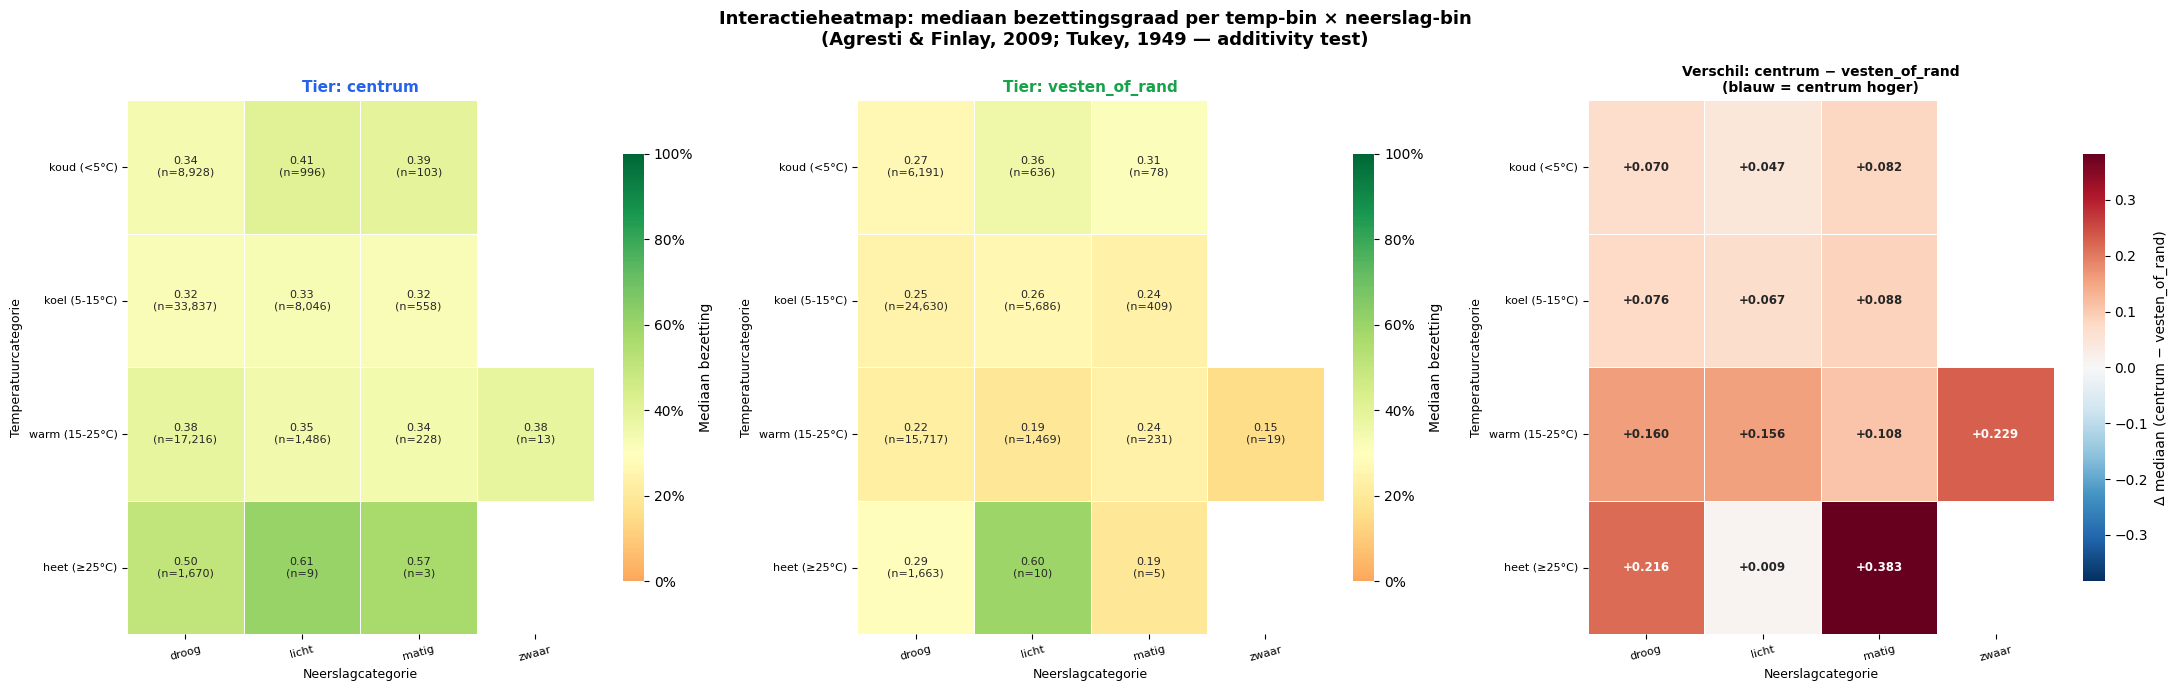

── H-E1+E2: Additiviteitstest (niet-additiviteit = interactieterm nodig) ──
  centrum: max|residu|=0.0401, mean|residu|=0.0226 → NIET-ADDITIEF → interactieterm aanbevolen
  vesten_of_rand: max|residu|=0.1618, mean|residu|=0.0625 → NIET-ADDITIEF → interactieterm aanbevolen

✓ Opgeslagen: fig_weather_interact.png


In [6]:
# ─── Cel 04: Interactieheatmap temp × neerslag ────────────────────────────────
import seaborn as sns

# ── Tempbins ──────────────────────────────────────────────────────────────────

df_train["temp_bin"]   = df_train["temp_c"].apply(assign_temp_bin)
TEMP_BIN_ORDER  = ["koud (<5°C)", "koel (5-15°C)", "warm (15-25°C)", "heet (≥25°C)"]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    "Interactieheatmap: mediaan bezettingsgraad per temp-bin × neerslag-bin\n"
    "(Agresti & Finlay, 2009; Tukey, 1949 — additivity test)",
    fontsize=13, fontweight="bold"
)

pivots_interact = {}
for tier in TIER_ORDER:
    df_t = df_train[
        (df_train["tier"] == tier) &
        df_train["temp_bin"].notna() &
        df_train["precip_bin"].notna()
    ]
    pivot = (
        df_t.groupby(["temp_bin", "precip_bin"])["occupancy_rate"]
        .median()
        .unstack("precip_bin")
        .reindex(index=TEMP_BIN_ORDER, columns=PRECIP_ORDER)
    )
    pivots_interact[tier] = pivot

# ── Absolute heatmaps per tier ────────────────────────────────────────────────
for ax_idx, tier in enumerate(TIER_ORDER):
    ax     = axes[ax_idx]
    pivot  = pivots_interact[tier]

    n_pivot = (
        df_train[
            (df_train["tier"] == tier) &
            df_train["temp_bin"].notna() &
            df_train["precip_bin"].notna()
        ]
        .groupby(["temp_bin", "precip_bin"])["occupancy_rate"]
        .count()
        .unstack("precip_bin")
        .reindex(index=TEMP_BIN_ORDER, columns=PRECIP_ORDER)
    )

    # Annotaties: mediaan + n
    annot_labels = pivot.copy().astype(str)
    for r in TEMP_BIN_ORDER:
        for c in PRECIP_ORDER:
            med_val = pivot.loc[r, c] if r in pivot.index and c in pivot.columns else np.nan
            n_val   = n_pivot.loc[r, c] if r in n_pivot.index and c in n_pivot.columns else 0
            if not pd.isna(med_val):
                annot_labels.loc[r, c] = f"{med_val:.2f}\n(n={int(n_val):,})"
            else:
                annot_labels.loc[r, c] = "N/A"

    sns.heatmap(
        pivot, ax=ax, cmap="RdYlGn", vmin=0, vmax=1,
        center=df_train["occupancy_rate"].median(),
        linewidths=0.5, linecolor="white",
        annot=annot_labels, fmt="",
        annot_kws={"size": 8},
        cbar_kws={"label": "Mediaan bezetting", "shrink": 0.8,
                  "format": lambda x, _: f"{x:.0%}"}
    )
    ax.set_title(f"Tier: {tier}", fontsize=11, fontweight="bold",
                 color=TIER_COLORS[tier])
    ax.set_xlabel("Neerslagcategorie", fontsize=9)
    ax.set_ylabel("Temperatuurcategorie", fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# ── Verschilheatmap (centrum − vesten_of_rand) ────────────────────────────────
ax_diff = axes[2]
p0 = pivots_interact["centrum"]
p1 = pivots_interact["vesten_of_rand"]
common_idx  = p0.index.intersection(p1.index)
common_cols = p0.columns.intersection(p1.columns)
diff_pivot  = p0.loc[common_idx, common_cols] - p1.loc[common_idx, common_cols]

annot_diff = diff_pivot.map(
    lambda x: f"{x:+.3f}" if not pd.isna(x) else "N/A"
)
abs_max = max(abs(diff_pivot.values[~np.isnan(diff_pivot.values)].max()),
              abs(diff_pivot.values[~np.isnan(diff_pivot.values)].min()))

sns.heatmap(
    diff_pivot, ax=ax_diff, cmap="RdBu_r",
    center=0, vmin=-abs_max, vmax=abs_max,
    linewidths=0.5, linecolor="white",
    annot=annot_diff, fmt="",
    annot_kws={"size": 8.5, "fontweight": "bold"},
    cbar_kws={"label": "Δ mediaan (centrum − vesten_of_rand)", "shrink": 0.8}
)
ax_diff.set_title("Verschil: centrum − vesten_of_rand\n(blauw = centrum hoger)",
                  fontsize=10, fontweight="bold")
ax_diff.set_xlabel("Neerslagcategorie", fontsize=9)
ax_diff.set_ylabel("Temperatuurcategorie", fontsize=9)
ax_diff.set_xticklabels(ax_diff.get_xticklabels(), rotation=15, fontsize=8)
ax_diff.set_yticklabels(ax_diff.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "fig_weather_interact.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Additiviteitstest: Tukey (1949) ───────────────────────────────────────────
print("── H-E1+E2: Additiviteitstest (niet-additiviteit = interactieterm nodig) ──")
for tier in TIER_ORDER:
    pivot = pivots_interact[tier].values
    pivot = pivot[~np.all(np.isnan(pivot), axis=1)]
    pivot = pivot[:, ~np.all(np.isnan(pivot), axis=0)]
    if pivot.shape[0] < 2 or pivot.shape[1] < 2:
        continue

    # Verwachte additieve waarden
    row_means = np.nanmean(pivot, axis=1, keepdims=True)
    col_means = np.nanmean(pivot, axis=0, keepdims=True)
    grand_mean= np.nanmean(pivot)
    expected  = row_means + col_means - grand_mean
    residuals = pivot - expected
    max_resid = np.nanmax(np.abs(residuals))
    mean_resid= np.nanmean(np.abs(residuals))
    print(f"  {tier}: max|residu|={max_resid:.4f}, mean|residu|={mean_resid:.4f} "
          f"→ {'NIET-ADDITIEF → interactieterm aanbevolen' if mean_resid > 0.02 else 'ADDITIEF'}")

print("\n✓ Opgeslagen: fig_weather_interact.png")


## Cel 05 — Windsnelheid drempelanalyse (H-E6)

> *H-E6: Windsnelheid > 10 m/s is geassocieerd met **hogere parkeeroccupantie**
> door modal shift van fiets naar auto (drempeleffect).*

**Referentie:** Böcker et al. (2013) toonden dat wind > 7-10 m/s de
fietsbereidheid significant reduceert. Correia et al. (2020) vonden
vergelijkbare drempeleffecten op collectief vervoer.
Wan et al. (2023) identificeerden extreme-weer awareness als cruciale
feature voor korte-termijn parkeervoorspelling.

### Drempel-aanpak
We testen meerdere drempelwaarden via Mann-Whitney U:
\[ H_1 : \text{occ}(w > d) > \text{occ}(w \leq d) \quad d \in \{5, 8, 10, 12\} \text{ m/s} \]

Effect size rank-biseriale r:
\[ r_{rb} = \frac{2U}{n_1 \cdot n_2} - 1 \]

**Confounding:** Windsnelheid correleert met seizoen (winter hogere wind)
en met neerslag (depressiesystemen). Daarom analyseren we per seizoen.

**Verwachting:** Drempeleffect significant bij ≥ 10 m/s, groter voor
centrum dan vesten_of_rand (fietsbereikbaarheid centrum hoger).


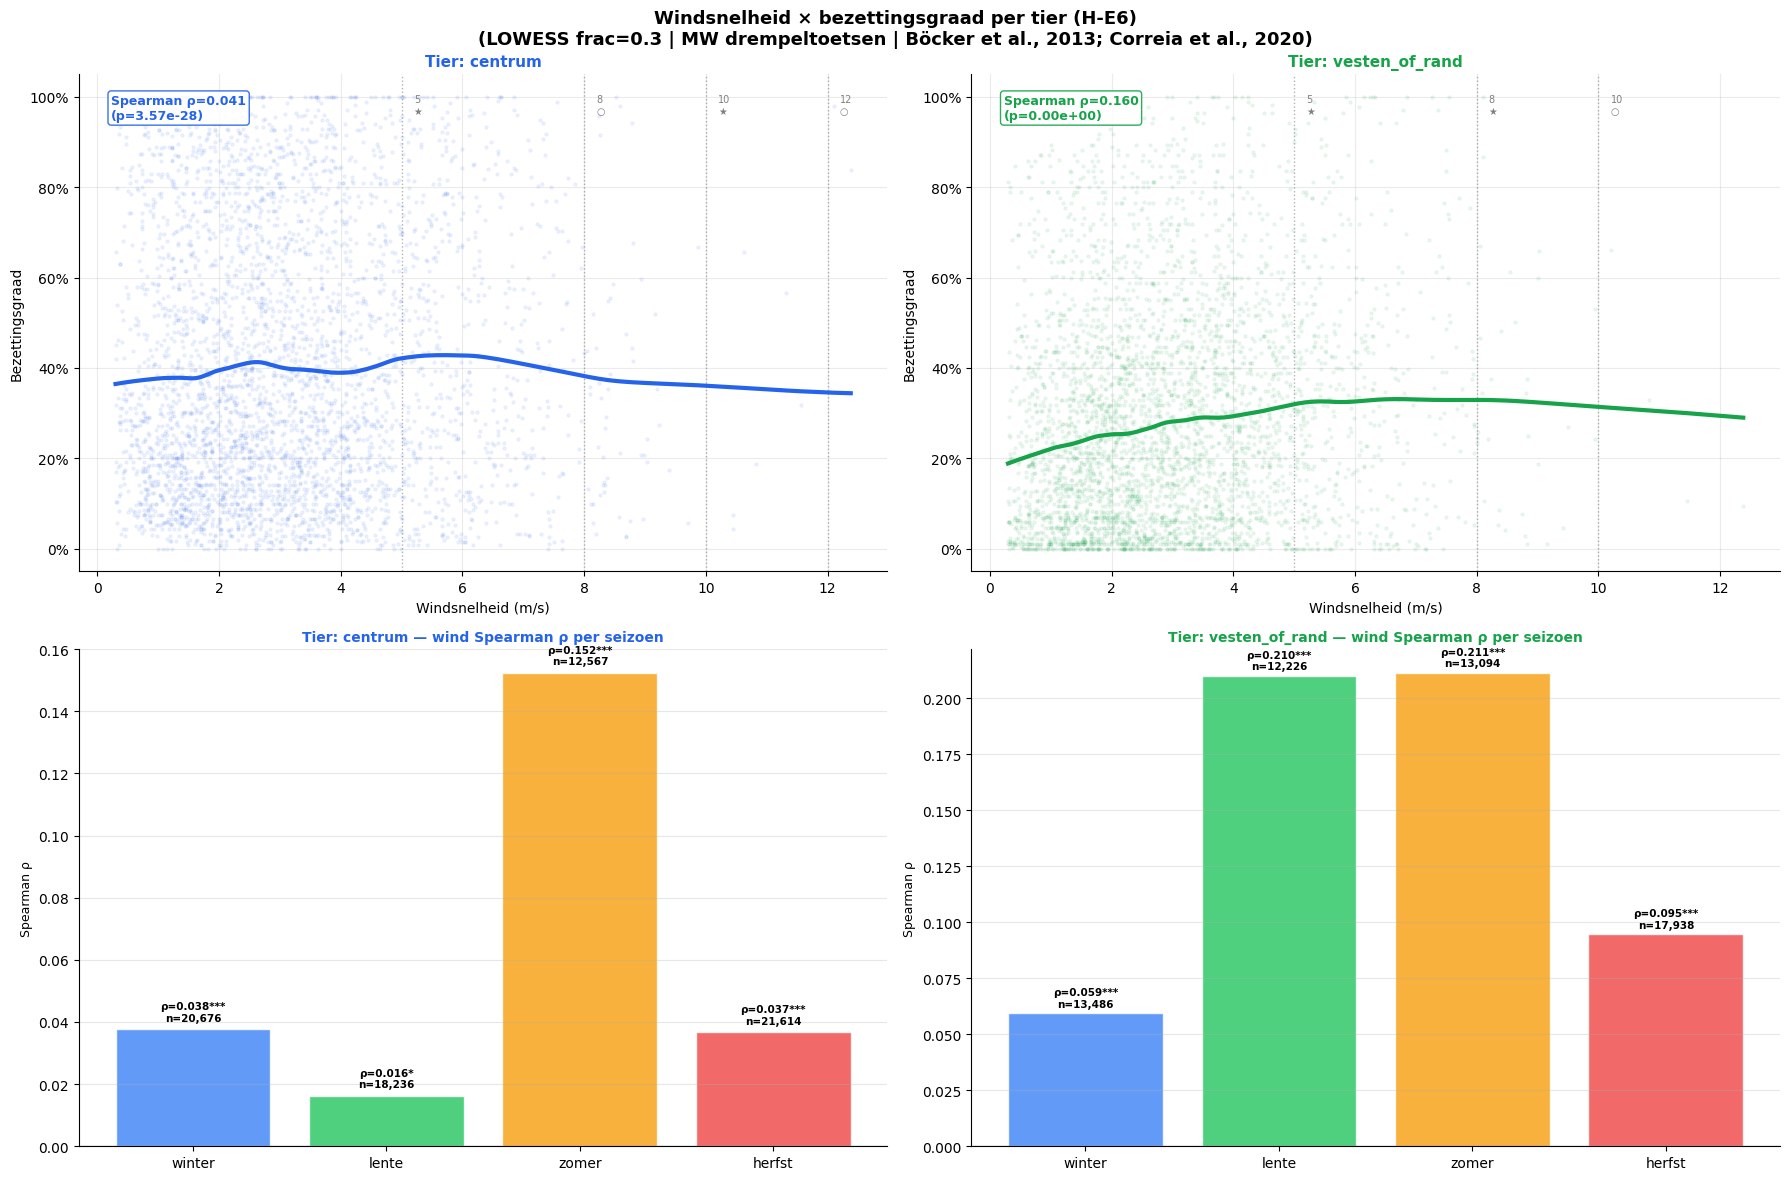

── H-E6: Drempelresultaten ──
          tier  threshold_ms  med_above  med_below  delta_med     mw_p    r_rb  significant
       centrum             5     0.3660     0.3407     0.0252 0.000001  0.0291         True
       centrum             8     0.3630     0.3434     0.0195 0.826728 -0.0188        False
       centrum            10     0.3970     0.3434     0.0535 0.035477  0.0953         True
       centrum            12     0.4141     0.3434     0.0707 0.104510  0.1939        False
vesten_of_rand             5     0.3173     0.2333     0.0840 0.000000  0.1538         True
vesten_of_rand             8     0.2933     0.2457     0.0476 0.000060  0.0954         True
vesten_of_rand            10     0.2632     0.2471     0.0161 0.165545  0.0640        False

✓ Opgeslagen: fig_wind_effect.png, tabel_wind_thresholds/spearman.csv


In [7]:
# ─── Cel 05: Windsnelheid drempelanalyse (H-E6) ───────────────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess

WIND_THRESHOLDS = [5, 8, 10, 12]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle(
    "Windsnelheid × bezettingsgraad per tier (H-E6)\n"
    "(LOWESS frac=0.3 | MW drempeltoetsen | Böcker et al., 2013; Correia et al., 2020)",
    fontsize=13, fontweight="bold"
)

wind_threshold_results = []
wind_spearman_results  = []

# ✅ CORRECT: elke conditie apart tussen haakjes
for ax_idx, tier in enumerate(TIER_ORDER):
    ax  = axes[ax_idx]

    if "wind_speed_ms" not in df_train.columns:
        ax.text(0.5, 0.5, "wind_speed_ms\nniet beschikbaar",
                ha="center", va="center", transform=ax.transAxes)
        continue

    df_t = df_train[
        (df_train["tier"] == tier) &
        (df_train["wind_speed_ms"].notna()) &
        (df_train["occupancy_rate"].notna())
    ]


    np.random.seed(42)
    idx   = np.random.choice(len(df_t), size=min(4000, len(df_t)), replace=False)
    df_ts = df_t.iloc[idx]

    # Scatter
    ax.scatter(df_ts["wind_speed_ms"], df_ts["occupancy_rate"],
               color=TIER_COLORS[tier], alpha=0.07, s=5, zorder=2)

    # LOWESS (Cleveland et al., 1979)
    lw_res = lowess(df_ts["occupancy_rate"].values,
                    df_ts["wind_speed_ms"].values,
                    frac=0.3, it=3, return_sorted=True)
    ax.plot(lw_res[:, 0], lw_res[:, 1],
            color=TIER_COLORS[tier], lw=3, zorder=5, label="LOWESS")

    # Drempellijnen + MW per drempel
    for thresh in WIND_THRESHOLDS:
        below = df_t[
            (df_t["wind_speed_ms"] <= thresh)
        ]["occupancy_rate"].dropna().values

        above = df_t[
            (df_t["wind_speed_ms"] > thresh)
        ]["occupancy_rate"].dropna().values


        if len(above) < 10:
            continue

        stat, p = mannwhitneyu(above, below, alternative="greater")
        n1, n2  = len(above), len(below)
        r_rb    = (2 * stat) / (n1 * n2) - 1

        wind_threshold_results.append({
            "tier": tier, "threshold_ms": thresh,
            "n_above": n1, "n_below": n2,
            "med_above": round(np.median(above), 4),
            "med_below": round(np.median(below), 4),
            "delta_med": round(np.median(above) - np.median(below), 4),
            "mw_p": round(p, 6), "r_rb": round(r_rb, 4),
            "significant": p < 0.05
        })

        ax.axvline(thresh, color="gray", lw=1, ls=":", alpha=0.6)
        sig = "★" if p < 0.05 else "○"
        ax.text(thresh + 0.2, 0.92, f"{thresh}\n{sig}",
                ha="left", fontsize=7, color="gray",
                transform=ax.get_xaxis_transform())

    # Spearman ρ totaal
    rho_w, p_w = spearmanr(df_t["wind_speed_ms"], df_t["occupancy_rate"])
    wind_spearman_results.append({
        "tier": tier, "season": "all", "spearman_rho": round(rho_w, 4),
        "p_value": round(p_w, 6)
    })

    ax.text(0.04, 0.96, f"Spearman ρ={rho_w:.3f}\n(p={p_w:.2e})",
            ha="left", va="top", transform=ax.transAxes,
            fontsize=9, fontweight="bold", color=TIER_COLORS[tier],
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=TIER_COLORS[tier], alpha=0.9))

    ax.set_xlabel("Windsnelheid (m/s)", fontsize=10)
    ax.set_ylabel("Bezettingsgraad", fontsize=10)
    ax.set_title(f"Tier: {tier}", fontsize=11, fontweight="bold",
                 color=TIER_COLORS[tier])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

# ── Subplots 3-4: drempel-effect per seizoen ──────────────────────────────────
for ax_idx, tier in enumerate(TIER_ORDER):
    ax = axes[2 + ax_idx]
    season_rho = []

    for season in SEASON_ORDER:
        df_ts = df_train[
            (df_train["tier"] == tier) &          # ← haakjes
            (df_train["season"] == season) &      # ← haakjes
            (df_train["wind_speed_ms"].notna()) & # ← haakjes
            (df_train["occupancy_rate"].notna())  # ← haakjes
        ]

        if len(df_ts) < 30:
            continue
        rho_s, p_s = spearmanr(df_ts["wind_speed_ms"], df_ts["occupancy_rate"])
        season_rho.append((season, rho_s, p_s, len(df_ts)))
        wind_spearman_results.append({
            "tier": tier, "season": season,
            "spearman_rho": round(rho_s, 4), "p_value": round(p_s, 6)
        })

    # Bar chart ρ per seizoen
    seasons_plot = [r[0] for r in season_rho]
    rhos_plot    = [r[1] for r in season_rho]
    colors_plot  = [SEASON_COLORS[s] for s in seasons_plot]
    bars = ax.bar(seasons_plot, rhos_plot, color=colors_plot, alpha=0.8,
                  edgecolor="white")

    for bar, (_, rho_val, p_val, n_val) in zip(bars, season_rho):
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.002 if rho_val >= 0 else -0.008),
                f"ρ={rho_val:.3f}{sig}\nn={n_val:,}",
                ha="center", va="bottom" if rho_val >= 0 else "top",
                fontsize=7.5, fontweight="bold")

    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"Tier: {tier} — wind Spearman ρ per seizoen",
                 fontsize=10, fontweight="bold", color=TIER_COLORS[tier])
    ax.set_ylabel("Spearman ρ", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / "fig_wind_effect.png", dpi=150, bbox_inches="tight")
plt.show()

df_wind_thresh   = pd.DataFrame(wind_threshold_results)
df_wind_spearman = pd.DataFrame(wind_spearman_results)
df_wind_thresh.to_csv(  FIGS / "tabel_wind_thresholds.csv", index=False)
df_wind_spearman.to_csv(FIGS / "tabel_wind_spearman.csv",   index=False)

print("── H-E6: Drempelresultaten ──")
print(df_wind_thresh[["tier","threshold_ms","med_above","med_below",
                       "delta_med","mw_p","r_rb","significant"]].to_string(index=False))
print("\n✓ Opgeslagen: fig_wind_effect.png, tabel_wind_thresholds/spearman.csv")


## Cel 06 — Zonneschijnduur per seizoen/tier (H-E7)

> *H-E7: Zonneschijnduur is in de zomer **negatief** geassocieerd met
> bezettingsgraad (modal shift naar actief transport bij mooi weer),
> maar positief of neutraal in winter.*

**Referentie:** Oz (2023) vond dat zonneschijnduur en neerslag samen
de sterkste weerpredictoren zijn voor on-street parkeren. Balmer et al.
(2021) bevestigden het substitutie-effect bij mooi weer.

### Partiële correlatie: controle voor temperatuur
Zonneschijnduur en temperatuur correleren sterk in de zomer
(multicollineariteit → confounding). We berekenen:
\[ \rho_{XY \cdot Z} = \frac{\rho_{XY} - \rho_{XZ} \cdot \rho_{YZ}}
{\sqrt{(1-\rho_{XZ}^2)(1-\rho_{YZ}^2)}} \]
waarbij X = sun_duration_min, Y = occupancy_rate, Z = temp_c
(Cohen et al., 2003; Field, 2013).

**Verwachting:** Zomer ρ negatief, winter ρ ≈ 0.
Na partialisering voor temp_c: als ρ_partial nog steeds negatief
in zomer → zonneschijnduur heeft onafhankelijk negatief effect.


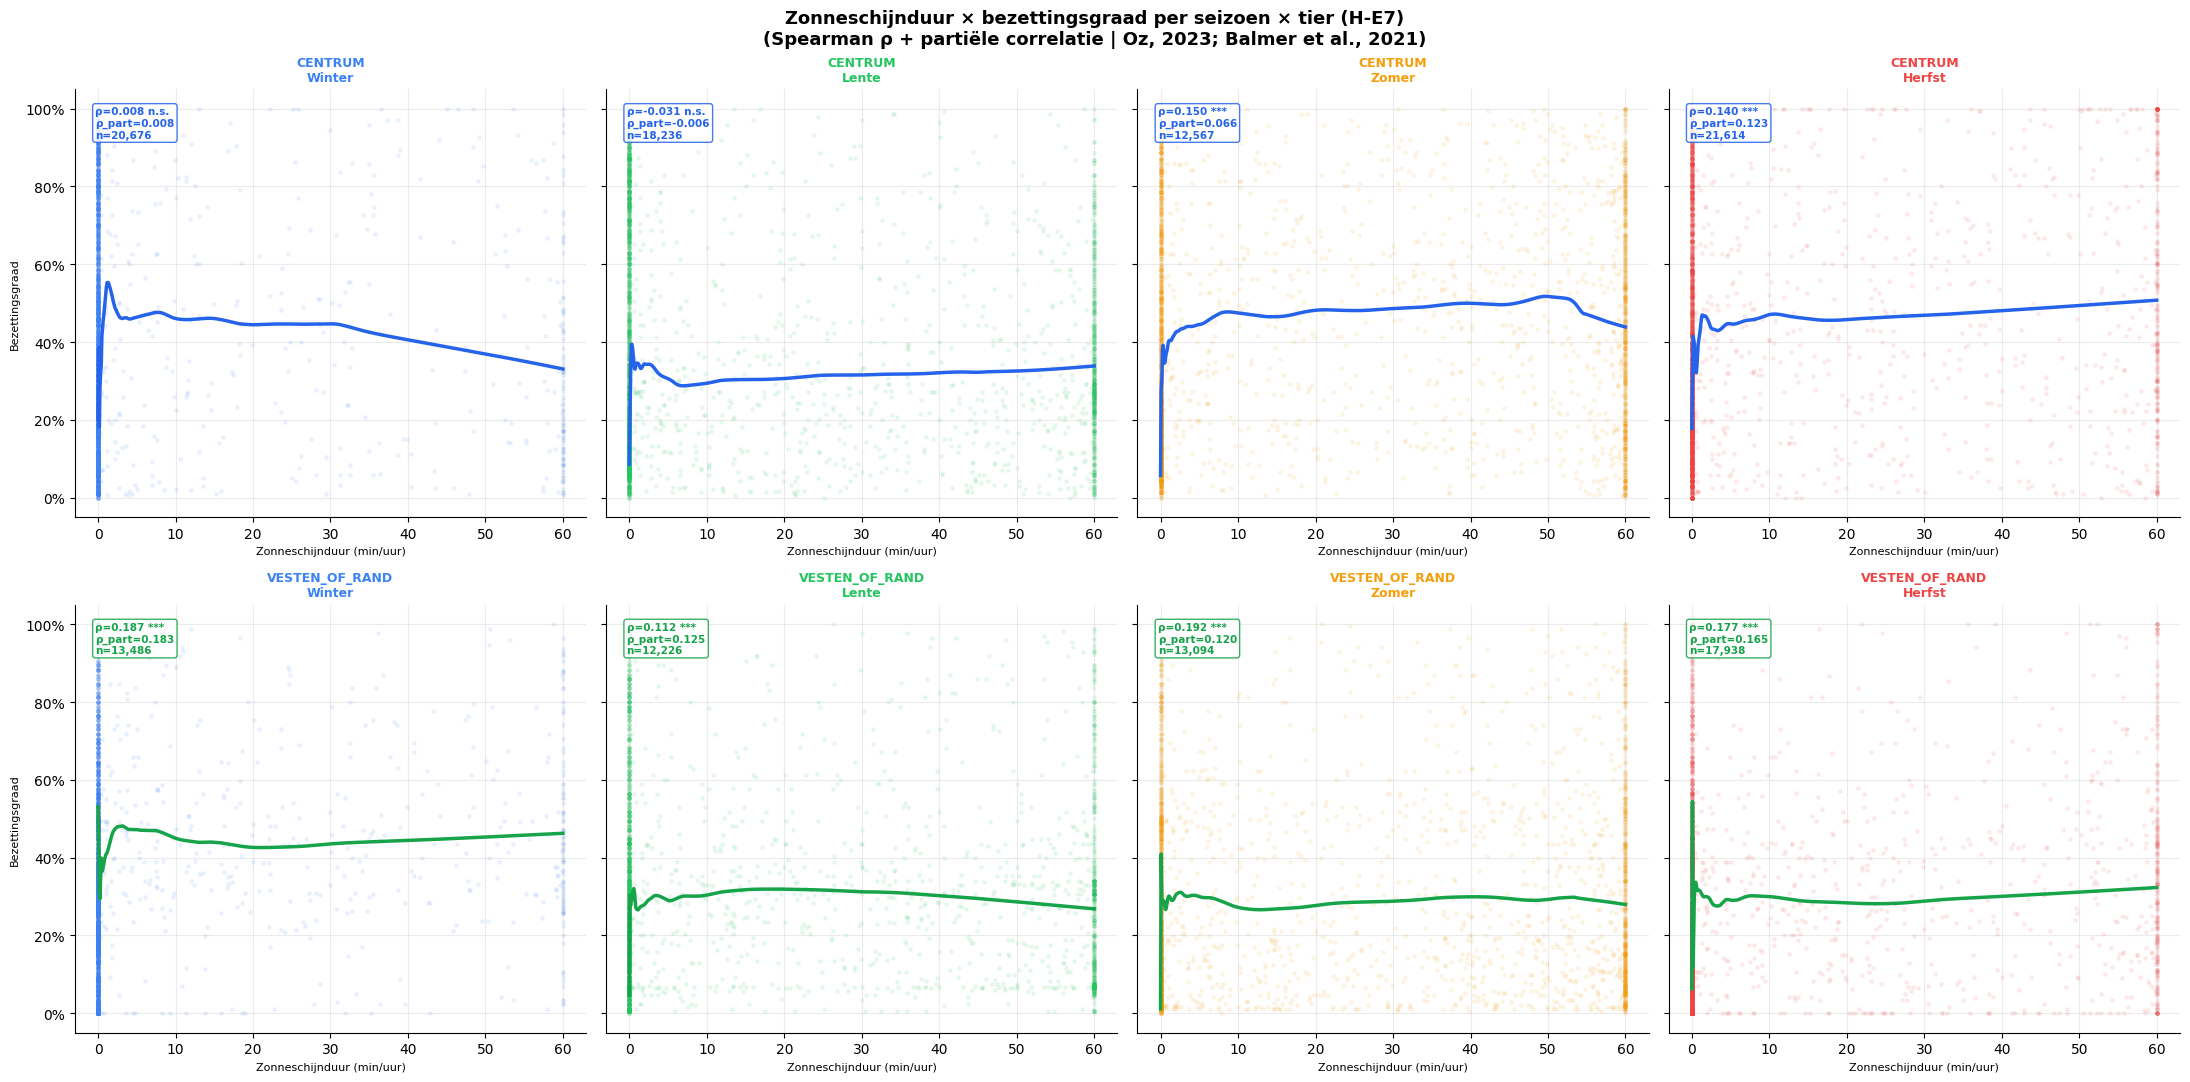

── H-E7: Zonneschijnduur Spearman ρ + partiële correlatie ──
          tier season  spearman_rho  rho_partial_temp  H_E7_consistent  partial_negative_zomer
       centrum winter        0.0077            0.0082            False                   False
       centrum  lente       -0.0308           -0.0063            False                   False
       centrum  zomer        0.1498            0.0660            False                   False
       centrum herfst        0.1398            0.1228            False                   False
vesten_of_rand winter        0.1870            0.1833            False                   False
vesten_of_rand  lente        0.1117            0.1247            False                   False
vesten_of_rand  zomer        0.1915            0.1205            False                   False
vesten_of_rand herfst        0.1774            0.1647            False                   False

✓ Opgeslagen: fig_sun_effect.png, tabel_sun_spearman.csv


In [8]:
# ─── Cel 06: Zonneschijnduur effect per seizoen/tier (H-E7) ──────────────────
if "sun_duration_min" not in df_train.columns:
    print("⚠ sun_duration_min niet beschikbaar in df_train. Cel overgeslagen.")
else:
    fig, axes = plt.subplots(2, 4, figsize=(22, 11), sharey=True)
    fig.suptitle(
        "Zonneschijnduur × bezettingsgraad per seizoen × tier (H-E7)\n"
        "(Spearman ρ + partiële correlatie | Oz, 2023; Balmer et al., 2021)",
        fontsize=13, fontweight="bold"
    )

    sun_results = []

    for tier_idx, tier in enumerate(TIER_ORDER):
        for seas_idx, season in enumerate(SEASON_ORDER):
            ax = axes[tier_idx][seas_idx]

            sub = df_train[
                (df_train["tier"] == tier) &
                (df_train["season"] == season) &
                df_train["sun_duration_min"].notna() &
                df_train["occupancy_rate"].notna() &
                df_train["temp_c"].notna()
            ]

            if len(sub) < 50:
                ax.text(0.5, 0.5, "Onvoldoende\ndata",
                        ha="center", va="center", transform=ax.transAxes)
                continue

            np.random.seed(42)
            idx   = np.random.choice(len(sub), size=min(3000, len(sub)), replace=False)
            sub_s = sub.iloc[idx]

            ax.scatter(sub_s["sun_duration_min"], sub_s["occupancy_rate"],
                       color=SEASON_COLORS[season], alpha=0.08, s=6, zorder=2)

            lw_res = lowess(sub_s["occupancy_rate"].values,
                            sub_s["sun_duration_min"].values,
                            frac=0.3, it=3, return_sorted=True)
            ax.plot(lw_res[:, 0], lw_res[:, 1], color=TIER_COLORS[tier],
                    lw=2.5, zorder=5)

            # Spearman ρ
            rho, p_rho = spearmanr(sub_s["sun_duration_min"],
                                   sub_s["occupancy_rate"])

            # Partiële correlatie: controleer voor temp_c
            # ρ_XY·Z = (ρ_XY − ρ_XZ·ρ_YZ) / sqrt((1−ρ_XZ²)(1−ρ_YZ²))
            rho_xz, _ = spearmanr(sub_s["sun_duration_min"], sub_s["temp_c"])
            rho_yz, _ = spearmanr(sub_s["temp_c"], sub_s["occupancy_rate"])

            denom = np.sqrt((1 - rho_xz**2) * (1 - rho_yz**2))
            rho_partial = (rho - rho_xz * rho_yz) / denom if denom > 0 else np.nan

            sun_results.append({
                "tier": tier, "season": season, "n_obs": len(sub),
                "spearman_rho": round(rho, 4),
                "p_value": round(p_rho, 6),
                "rho_partial_temp": round(rho_partial, 4) if not np.isnan(rho_partial) else np.nan,
                "H_E7_consistent": bool(season == "zomer" and rho < 0),
                "partial_negative_zomer": bool(season == "zomer" and
                                               not np.isnan(rho_partial) and rho_partial < 0)
            })

            sig_star = ("***" if p_rho < 0.001 else "**" if p_rho < 0.01
                        else "*" if p_rho < 0.05 else "n.s.")
            ax.text(0.04, 0.96,
                    f"ρ={rho:.3f} {sig_star}\nρ_part={rho_partial:.3f}\nn={len(sub):,}",
                    ha="left", va="top", transform=ax.transAxes,
                    fontsize=7.5, fontweight="bold",
                    color=TIER_COLORS[tier],
                    bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                              edgecolor=TIER_COLORS[tier], alpha=0.85))

            ax.set_xlabel("Zonneschijnduur (min/uur)", fontsize=8)
            ax.set_ylabel("Bezettingsgraad" if seas_idx == 0 else "", fontsize=8)
            ax.set_title(f"{tier.upper()}\n{season.capitalize()}",
                         fontsize=9, fontweight="bold",
                         color=SEASON_COLORS[season])
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
            ax.grid(alpha=0.25)
            ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(FIGS / "fig_sun_effect.png", dpi=150, bbox_inches="tight")
    plt.show()

    df_sun = pd.DataFrame(sun_results)
    df_sun.to_csv(FIGS / "tabel_sun_spearman.csv", index=False)

    print("── H-E7: Zonneschijnduur Spearman ρ + partiële correlatie ──")
    print(df_sun[["tier","season","spearman_rho","rho_partial_temp",
                  "H_E7_consistent","partial_negative_zomer"]].to_string(index=False))
    print("\n✓ Opgeslagen: fig_sun_effect.png, tabel_sun_spearman.csv")


## Cel 07 — Feestdag & schoolvakantie-effect per tier (H-E4 + H-E8)

> *H-E4: Nationale feestdagen zijn geassocieerd met **hogere** bezetting
> in vesten_of_rand (leisure) en **lagere** bezetting in centrum
> (gesloten winkels/kantoren).*

> *H-E8: Schoolvakanties verlagen bezetting in centrum (minder
> woon-werkverkeer) maar zijn geassocieerd met neutraal/hogere bezetting
> in vesten_of_rand (leisure-trips).*

**Referentie:** Zhang et al. (2024) identificeerden feestdagen als
een van de sterkste kalenderfeatures voor parkeervoorspelling in
Aziatisch-Europese context. Channamallu et al. (2024) bevestigden
seizoen en dag-type als top-features in RF.

### Confounding weekdag → weekendeffect
Feestdagen vallen op willekeurige weekdagen. Om weekendconfounding
te vermijden analyseren we:
1. Weekdagen (day_type_3 = 'weekday') apart
2. Combinatie van alle dagen (incl. weekenden)

### Toetsing (conform nb06 cel 08)
**Mann-Whitney U (eenzijdig per tier):**
\[ r_{rb} = \frac{2U}{n_1 \cdot n_2} - 1 \quad \text{(Field, 2013)} \]

**Fischer z-toets (centrum vs. vesten_of_rand):**
\[ z_{diff} = \frac{z_c - z_v}{\sqrt{\frac{1}{n_c-3} + \frac{1}{n_v-3}}} \]
(Fischer, 1921) — eenzijdig: H₁: r_rb(vesten_of_rand) > r_rb(centrum)
voor feestdagen; r_rb(centrum) < 0 voor schoolvakanties.

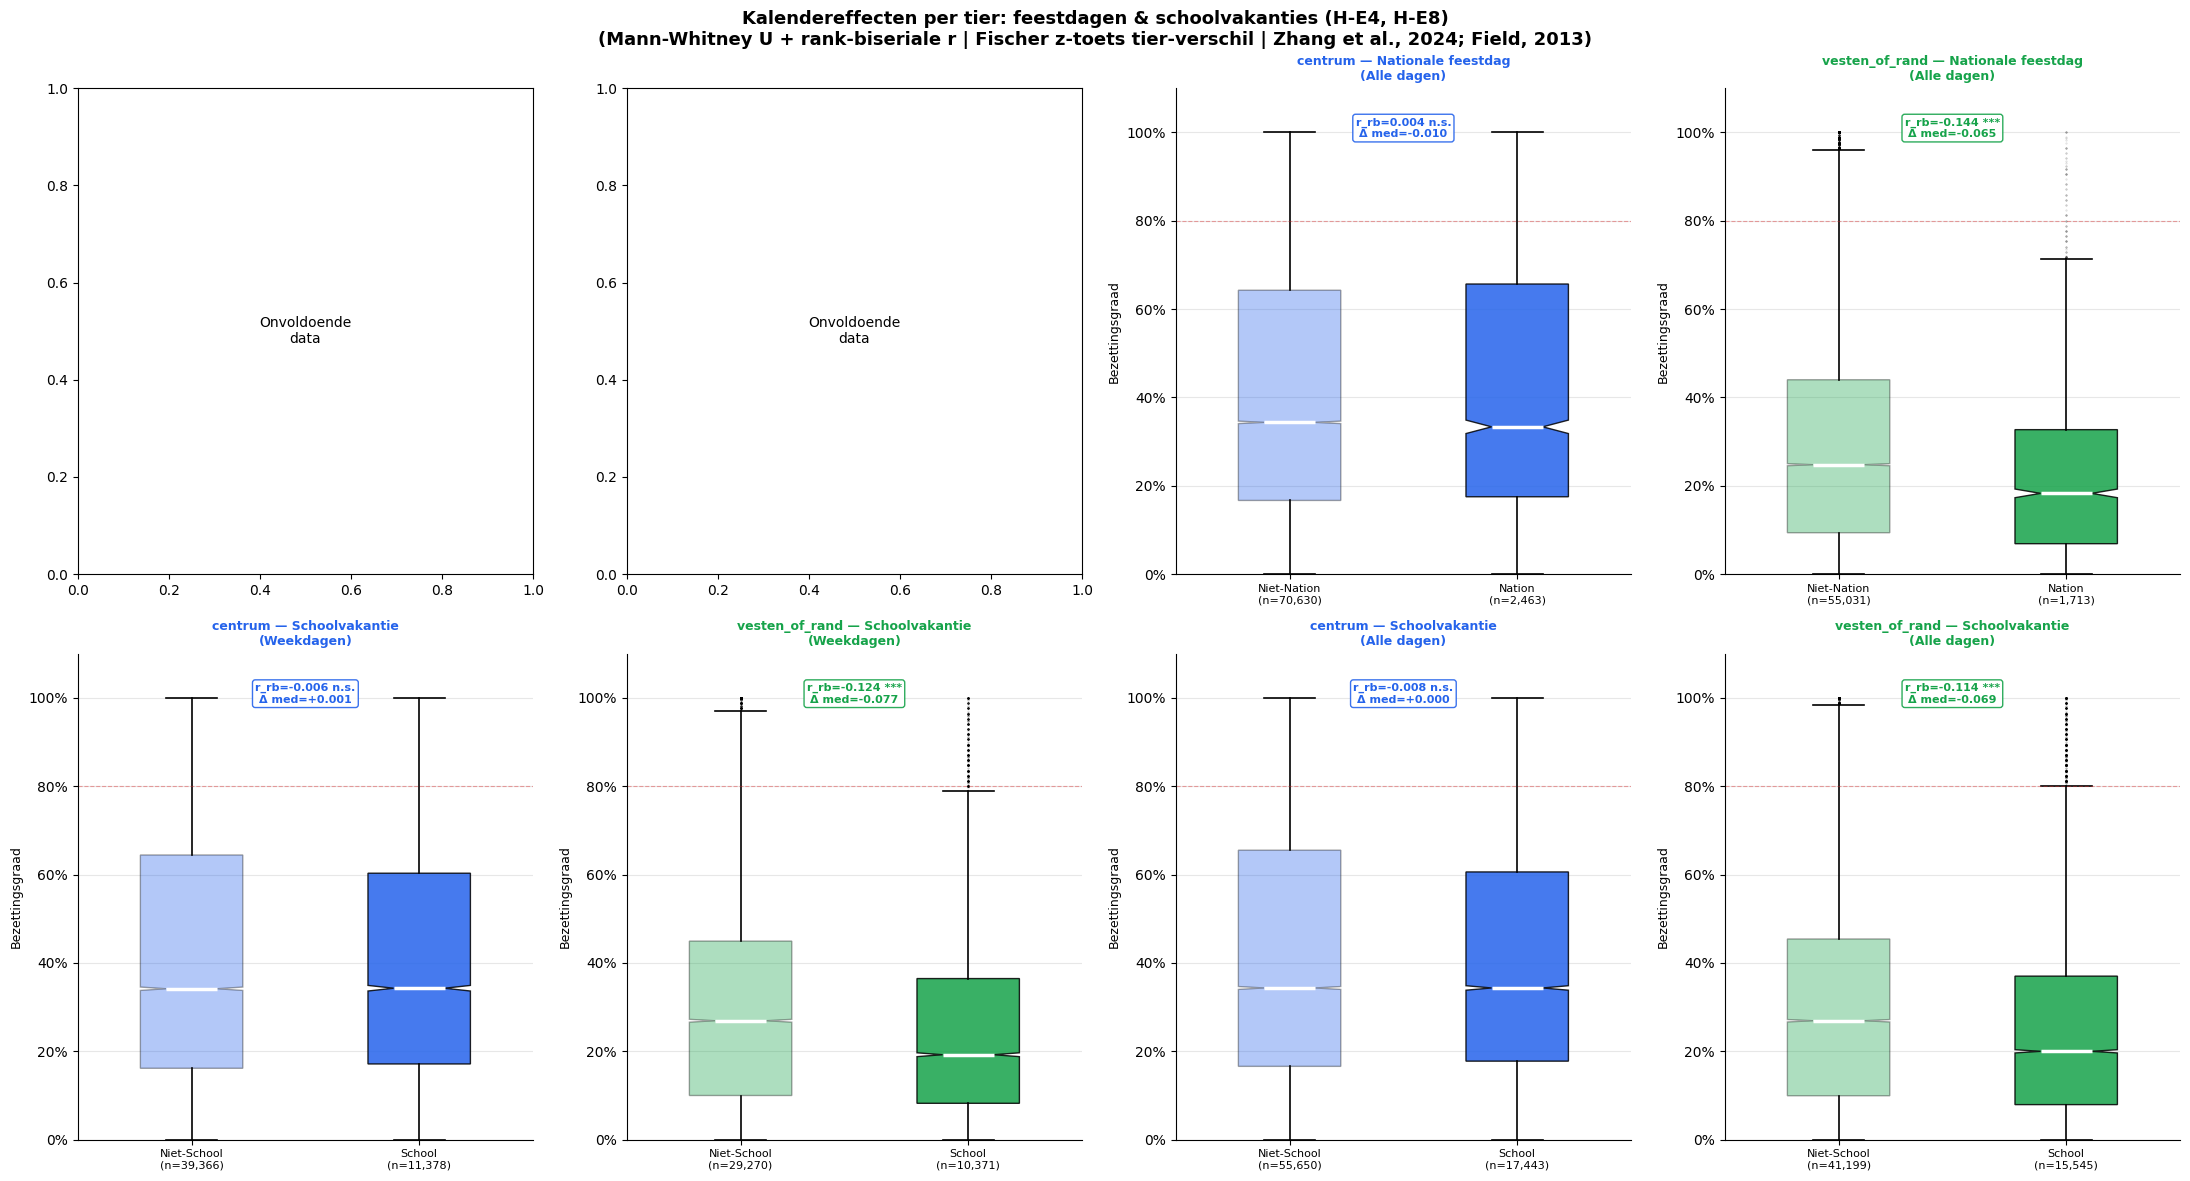

── Kalenderresultaten per tier ──
         cal_label day_subset           tier  med_event  med_non_event  delta_med     mw_p    r_rb
Nationale feestdag Alle dagen        centrum     0.3333         0.3434    -0.0101 0.757302  0.0037
Nationale feestdag Alle dagen vesten_of_rand     0.1827         0.2476    -0.0649 0.000000 -0.1439
    Schoolvakantie  Weekdagen        centrum     0.3429         0.3417     0.0012 0.299450 -0.0064
    Schoolvakantie  Weekdagen vesten_of_rand     0.1923         0.2692    -0.0769 0.000000 -0.1237
    Schoolvakantie Alle dagen        centrum     0.3434         0.3434     0.0000 0.112600 -0.0079
    Schoolvakantie Alle dagen vesten_of_rand     0.2000         0.2692    -0.0692 0.000000 -0.1142

── Fischer z-toets: tier-verschil kalendereffect ──
  ❌ Nationale feestdag (Alle dagen): r_rb_c=0.004, r_rb_v=-0.144, Δr_rb=-0.148, p=1.000
  ✅ Schoolvakantie (Weekdagen): r_rb_c=-0.006, r_rb_v=-0.124, Δr_rb=+0.117, p=0.000
  ✅ Schoolvakantie (Alle dagen): r_rb_c=-0.008, 

In [9]:
# ─── Cel 07: Feestdag & schoolvakantie-effect per tier (H-E4 + H-E8) ─────────
from scipy.stats import norm as sp_norm

CALENDAR_VARS = {
    "is_national_holiday": "Nationale feestdag",
    "is_school_vacation":  "Schoolvakantie",
}

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
fig.suptitle(
    "Kalendereffecten per tier: feestdagen & schoolvakanties (H-E4, H-E8)\n"
    "(Mann-Whitney U + rank-biseriale r | Fischer z-toets tier-verschil | "
    "Zhang et al., 2024; Field, 2013)",
    fontsize=13, fontweight="bold"
)

calendar_results = []
fischer_calendar  = []

for var_idx, (cal_var, cal_label) in enumerate(CALENDAR_VARS.items()):
    if cal_var not in df_train.columns:
        continue

    for day_subset_idx, (day_subset_label, day_mask) in enumerate([
        ("Weekdagen", df_train["day_type_3"] == "weekday"),
        ("Alle dagen", pd.Series([True] * len(df_train), index=df_train.index)),
    ]):
        ax = axes[var_idx][day_subset_idx * 2 : day_subset_idx * 2 + 2]

        fischer_row = {"cal_var": cal_var, "label": cal_label,
                       "day_subset": day_subset_label}
        tier_r_rb = {}

        for ax_tier_idx, tier in enumerate(TIER_ORDER):
            a = ax[ax_tier_idx]
            df_sub = df_train[day_mask & (df_train["tier"] == tier)]

            event_vals    = df_sub[df_sub[cal_var] == 1]["occupancy_rate"].dropna().values
            non_event_vals= df_sub[df_sub[cal_var] == 0]["occupancy_rate"].dropna().values

            if len(event_vals) < 20 or len(non_event_vals) < 20:
                a.text(0.5, 0.5, "Onvoldoende\ndata",
                       ha="center", va="center", transform=a.transAxes)
                continue

            # Mann-Whitney (eenzijdig: event > niet-event)
            stat_mw, p_mw = mannwhitneyu(event_vals, non_event_vals,
                                          alternative="two-sided")
            n1, n2 = len(event_vals), len(non_event_vals)
            r_rb   = (2 * stat_mw) / (n1 * n2) - 1
            tier_r_rb[tier] = {"r_rb": r_rb, "n": n1}

            calendar_results.append({
                "cal_var":       cal_var,
                "cal_label":     cal_label,
                "day_subset":    day_subset_label,
                "tier":          tier,
                "n_event":       n1,
                "n_non_event":   n2,
                "med_event":     round(np.median(event_vals),     4),
                "med_non_event": round(np.median(non_event_vals), 4),
                "delta_med":     round(np.median(event_vals) - np.median(non_event_vals), 4),
                "mw_p":          round(p_mw, 6),
                "r_rb":          round(r_rb, 4),
                "significant":   p_mw < 0.05,
            })

            # Boxplot: event vs. niet-event
            bp = a.boxplot(
                [non_event_vals, event_vals],
                positions=[0, 1], widths=0.45,
                patch_artist=True, notch=True,
                medianprops=dict(color="white", lw=2.5),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                flierprops=dict(marker=".", markersize=1, alpha=0.15),
            )
            colors_bp = [TIER_COLORS[tier] + "70",
                         TIER_COLORS[tier]]  # hex alpha
            for patch, col in zip(bp["boxes"],
                                  [TIER_COLORS[tier], TIER_COLORS[tier]]):
                patch.set_facecolor(col)
                patch.set_alpha(0.35 if list(bp["boxes"]).index(patch) == 0 else 0.85)

            sig_star = ("***" if p_mw < 0.001 else "**" if p_mw < 0.01
                        else "*" if p_mw < 0.05 else "n.s.")
            a.text(0.5, 0.94,
                   f"r_rb={r_rb:.3f} {sig_star}\nΔ med={np.median(event_vals)-np.median(non_event_vals):+.3f}",
                   ha="center", va="top", transform=a.transAxes,
                   fontsize=8, fontweight="bold", color=TIER_COLORS[tier],
                   bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                             edgecolor=TIER_COLORS[tier], alpha=0.9))

            a.set_xticks([0, 1])
            a.set_xticklabels([f"Niet-{cal_label[:6]}\n(n={n2:,})",
                                f"{cal_label[:6]}\n(n={n1:,})"], fontsize=8)
            a.set_title(f"{tier} — {cal_label}\n({day_subset_label})",
                        fontsize=9, fontweight="bold", color=TIER_COLORS[tier])
            a.set_ylabel("Bezettingsgraad", fontsize=9)
            a.set_ylim(0, 1.10)
            a.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
            a.axhline(0.80, color="#DC2626", lw=0.8, ls="--", alpha=0.4)
            a.grid(axis="y", alpha=0.3)
            a.spines[["top", "right"]].set_visible(False)

        # Fischer z-toets: centrum vs. vesten_of_rand
        if "centrum" in tier_r_rb and "vesten_of_rand" in tier_r_rb:
            r_c  = tier_r_rb["centrum"]["r_rb"]
            r_v  = tier_r_rb["vesten_of_rand"]["r_rb"]
            n_c  = tier_r_rb["centrum"]["n"]
            n_v  = tier_r_rb["vesten_of_rand"]["n"]
            z_c  = fisher_z(r_c)
            z_v  = fisher_z(r_v)
            se_d = np.sqrt(1/max(n_c-3,1) + 1/max(n_v-3,1))
            # Eenzijdig: r_rb(vesten_of_rand) > r_rb(centrum) voor feestdag
            # Eenzijdig: r_rb(centrum) negatief voor schoolvakantie
            z_diff = (z_v - z_c) / se_d if cal_var == "is_national_holiday" \
                     else (z_c - z_v) / se_d
            p_f = sp_norm.sf(z_diff)

            fischer_row.update({
                "r_rb_centrum": round(r_c, 4), "r_rb_vesten": round(r_v, 4),
                "delta_r_rb": round(r_v - r_c, 4) if cal_var == "is_national_holiday"
                              else round(r_c - r_v, 4),
                "z_diff": round(z_diff, 4), "p_fischer": round(p_f, 4),
                "H_confirmed": bool(p_f < 0.05)
            })
            fischer_calendar.append(fischer_row)

plt.tight_layout()
plt.savefig(FIGS / "fig_holiday_vacation_tier.png", dpi=150, bbox_inches="tight")
plt.show()

df_cal = pd.DataFrame(calendar_results)
df_cal.to_csv(FIGS / "tabel_holiday_mw.csv", index=False)

print("── Kalenderresultaten per tier ──")
print(df_cal[["cal_label","day_subset","tier","med_event",
              "med_non_event","delta_med","mw_p","r_rb"]].to_string(index=False))

print("\n── Fischer z-toets: tier-verschil kalendereffect ──")
for r in fischer_calendar:
    icon = "✅" if r.get("H_confirmed") else "❌"
    print(f"  {icon} {r['label']} ({r['day_subset']}): "
          f"r_rb_c={r.get('r_rb_centrum','N/A'):.3f}, "
          f"r_rb_v={r.get('r_rb_vesten','N/A'):.3f}, "
          f"Δr_rb={r.get('delta_r_rb',0):+.3f}, "
          f"p={r.get('p_fischer','N/A'):.3f}")

print("\n✓ Opgeslagen: fig_holiday_vacation_tier.png, tabel_holiday_mw.csv")


## Cel 08 — Event-laganalyse t−6u tot t+6u (H-E3 + H-E9)

> *H-E3 [CASCADE]: Parkeeroccupantie is **voor** eventstart (t−2u tot t−1u)
> al significant hoger dan baseline, en daalt **na** afloop (t+1u tot t+3u)
> — asymmetrisch tijdsprofiel.*

> *H-E9: Het piekeffect is **schaalafhankelijk**: grote events (event_scale_max)
> genereren een significant hogere Δ-piek dan kleine events.*

**Referentie:** Fokker et al. (2021) ontwikkelden de event-window methode
voor off-street parkeren in Amsterdam. Wan et al. (2023) bevestigden dat
event-awareness cruciaal is voor korte-termijn TCN-modellen.

### Baseline normalisatie (Fokker et al., 2021)
\[ \Delta(t) = \text{occ}_{\text{event}}(t) - \text{occ}_{\text{baseline}}(t) \]

Baseline = mediaan bezetting op **niet-event-dagen** met zelfde combinatie van:
tier × weekday\_int × hour × seizoen.
Mediaan boven gemiddelde: robuust voor resterende uitschieters
(Agresti & Finlay, 2009).

### Ankerpunten per event-type
| Event-type | Ankerpunt | Motivatie |
|---|---|---|
| Voetbal | `football_kickoff_hour` | Exacte aftrap bekend |
| Festival, Kermis, Carnaval, Processie | 10u (default) | Gemiddelde starttijd publieksevent |

### Bootstrap CI (95%)
\[ CI_{95\%} = \left[\hat{\mu} - 1.96\frac{\hat{\sigma}}{\sqrt{n}},\;
\hat{\mu} + 1.96\frac{\hat{\sigma}}{\sqrt{n}}\right] \]
Bootstrap n=1000 herhalingen (seed=42): robuuster bij beperkt aantal
event-instanties dan parametrisch CI (Efron & Tibshirani, 1993).

### One-sample t-toets op Δ(t)
Test H₀: Δ(t) = 0 op kritieke tijdstappen t=−1 (voor) en t=+1 (na):
\[ t = \frac{\bar{\Delta}}{s/\sqrt{n}} \quad \text{(Field, 2013)} \]

### H-E9: Spearman ρ schaal × piekeffect
Ordinale schaal klein=1, medium=2, groot=3:
\[ \rho_s(\text{event\_scale}, \Delta_{\text{piek}}) \]
(Conover, 1999). Verwachting: ρ > 0, significant.

### Robuustheidscheck
data\_confidence = "estimated" rijen (185 events) worden apart gefilterd.
Analyse herhaald met enkel "verified" events. Als resultaten stabiel
blijven, zijn bevindingen robuust t.a.v. data-kwaliteits-onzekerheid
(Fokker et al., 2021).

**Verwachte bevinding:** Cascade-profiel aanwezig voor voetbal en
festivals; schaaleffect significant voor centrum, minder voor
vesten\_of\_rand (consistent met H-S4, nb06 cel 08).


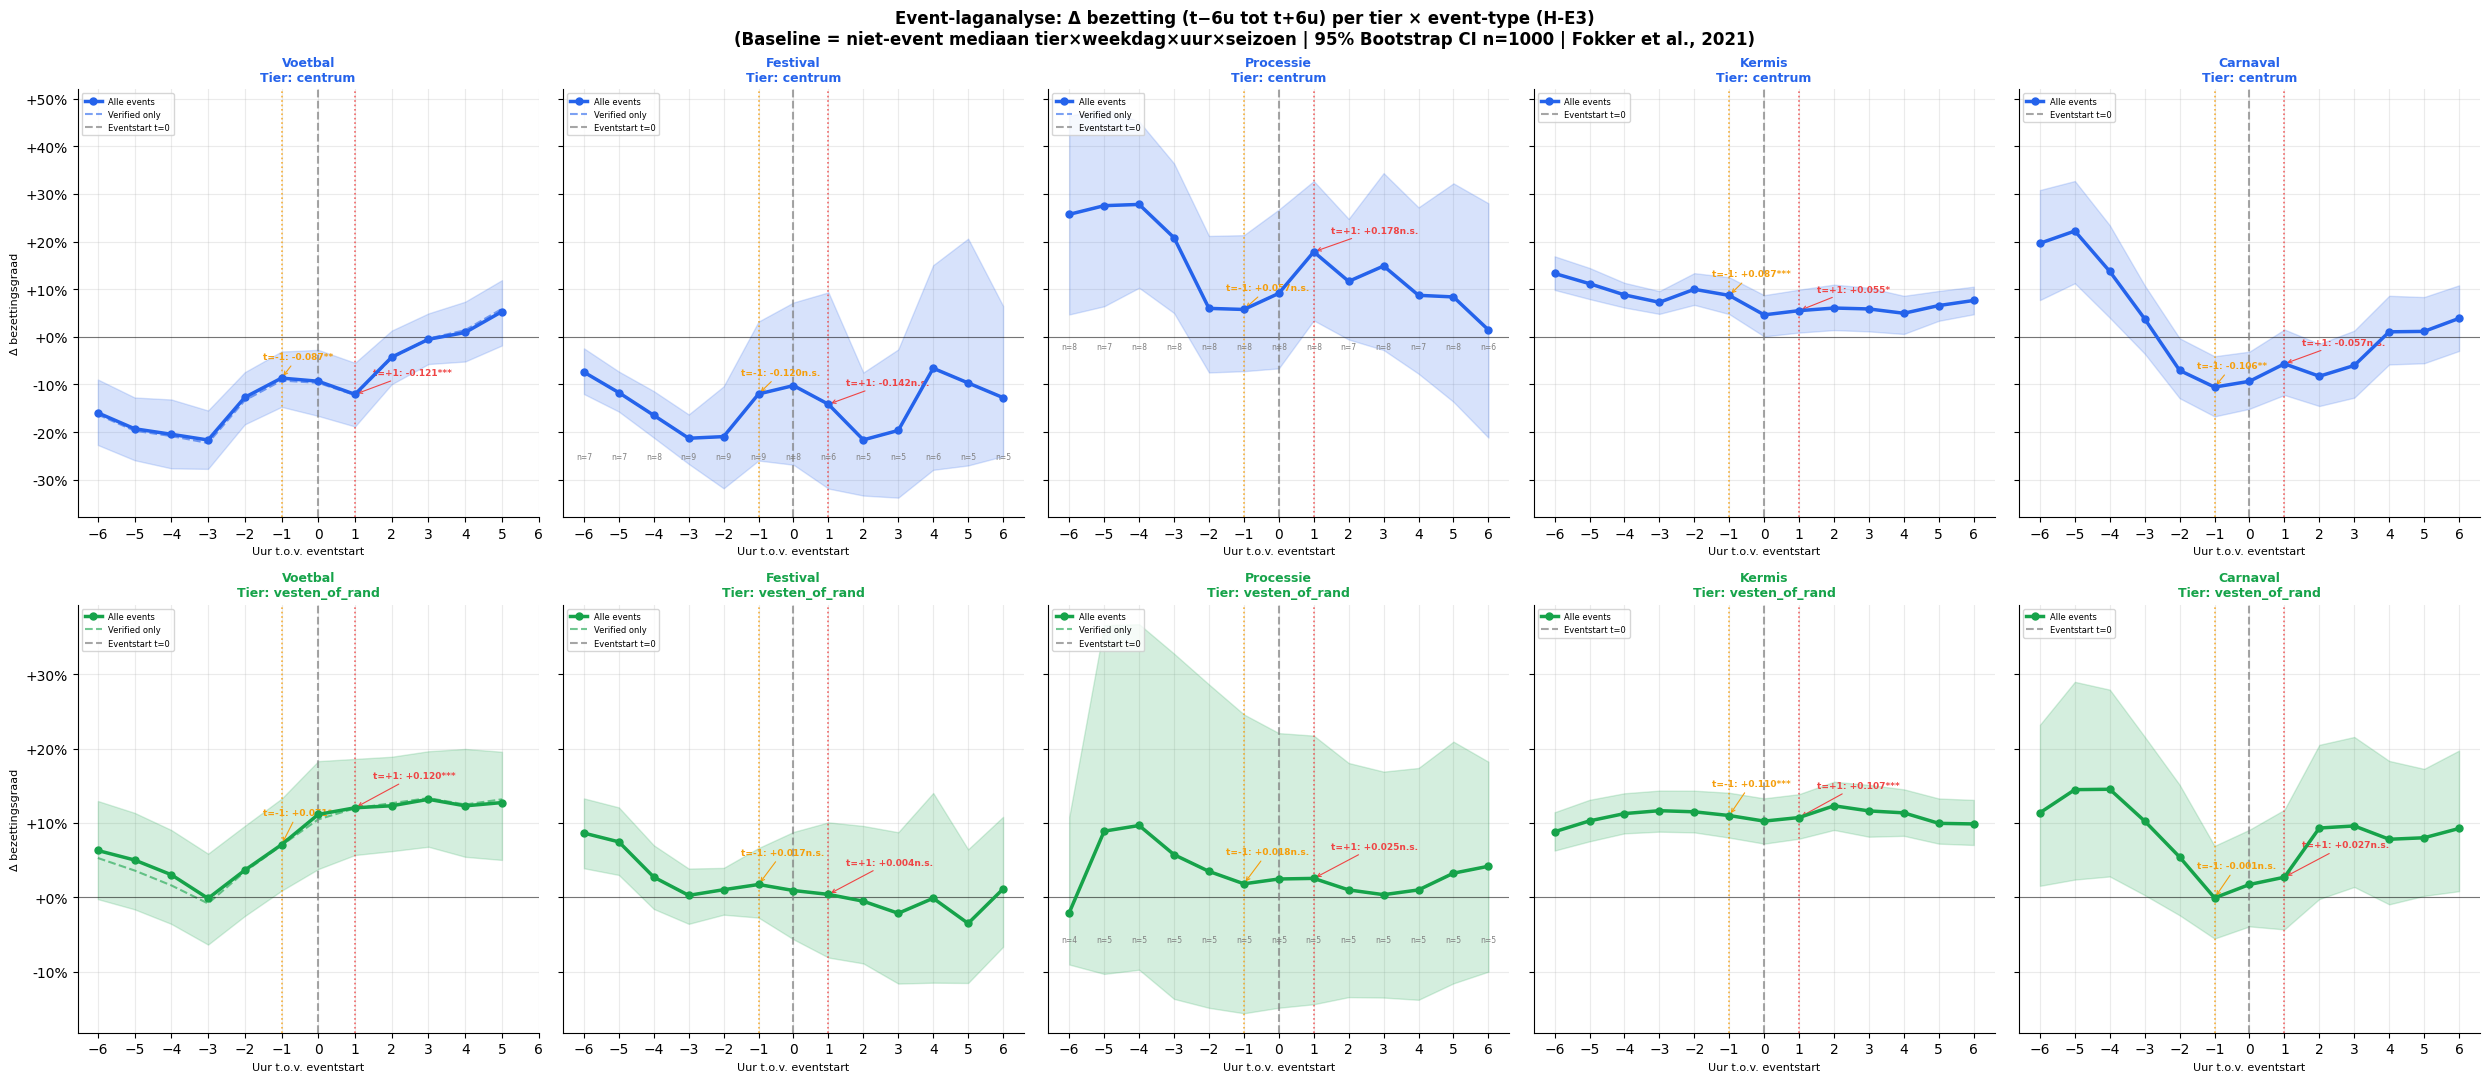

── H-E3: t-toets resultaten bij t=−1 en t=+1 ──
event_label           tier  lag  mean_delta   n  t_stat  p_value  significant
    Voetbal        centrum   -1     -0.0866  89 -2.9394   0.0042         True
    Voetbal        centrum    1     -0.1207  93 -3.5568   0.0006         True
    Voetbal vesten_of_rand   -1      0.0708  62  2.1989   0.0317         True
    Voetbal vesten_of_rand    1      0.1204  69  3.4886   0.0009         True
   Festival        centrum   -1     -0.1199   9 -1.5132   0.1687        False
   Festival        centrum    1     -0.1415   6 -1.1593   0.2987        False
   Festival vesten_of_rand   -1      0.0173  18  0.6894   0.4999        False
   Festival vesten_of_rand    1      0.0040  19  0.0846   0.9335        False
  Processie        centrum   -1      0.0574   8  0.7396   0.4836        False
  Processie        centrum    1      0.1783   8  2.2353   0.0605        False
  Processie vesten_of_rand   -1      0.0182   5  0.1559   0.8837        False
  Processie vest

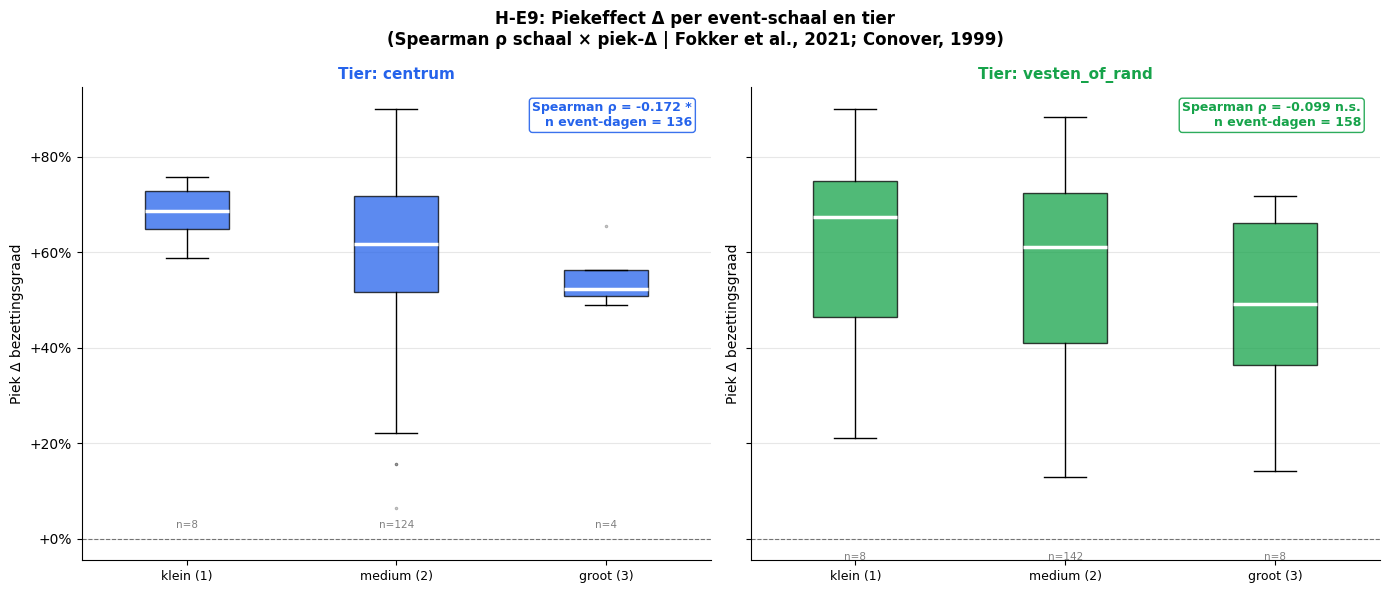


── H-E9: Schaalafhankelijkheidsresultaten ──
          tier  spearman_rho  p_value  significant  H_E9_confirmed  n_event_days
       centrum        -0.172   0.0453         True           False           136
vesten_of_rand        -0.099   0.2159        False           False           158

✓ Opgeslagen: fig_event_lag.png, fig_event_scale.png
✓ Opgeslagen: tabel_event_lag.csv, tabel_event_ttest.csv, tabel_event_scale.csv


In [10]:
# ─── Cel 08: Event-laganalyse t−6u tot t+6u (H-E3 + H-E9) ───────────────────
from scipy.stats import ttest_1samp, spearmanr

LAG_RANGE        = list(range(-6, 7))
EVENT_TYPES_LAG  = {
    "is_football_day":   ("Voetbal",   "football_kickoff_hour", 19),
    "is_festival_day":   ("Festival",  None,                    10),
    "is_procession_day": ("Processie", None,                    10),
    "is_kermis_day":     ("Kermis",    None,                    10),
    "is_carnival_day":   ("Carnaval",  None,                    10),
}

# ── Baseline: mediaan bezetting op niet-event-dagen ───────────────────────────
baseline = (
    df_train[df_train["is_event_day"] == 0]
    .groupby(["tier", "weekday_int", "hour", "season"])["occupancy_rate"]
    .median()
    .reset_index()
    .rename(columns={"occupancy_rate": "baseline_occ"})
)

# ── Helper: Δ(t) profiel per event-type ──────────────────────────────────────

# ── Welke event-typen zijn aanwezig? ─────────────────────────────────────────
valid_events = [
    (col, meta)
    for col, meta in EVENT_TYPES_LAG.items()
    if col in df_train.columns
]
n_valid = len(valid_events)

# ─────────────────────────────────────────────────────────────────────────────
#  DEEL A: Lagprofielen (H-E3)
# ─────────────────────────────────────────────────────────────────────────────
if n_valid == 0:
    print("⚠ Geen event-kolommen gevonden — cel 08 overgeslagen.")
else:
    fig, axes = plt.subplots(
        len(TIER_ORDER), n_valid,
        figsize=(max(5 * n_valid, 18), 11),
        sharey="row"
    )
    # Zorg altijd voor 2D numpy array
    axes = np.array(axes)
    if axes.ndim == 1 and len(TIER_ORDER) == 1:
        axes = axes.reshape(1, -1)
    elif axes.ndim == 1 and n_valid == 1:
        axes = axes.reshape(-1, 1)

    fig.suptitle(
        "Event-laganalyse: Δ bezetting (t−6u tot t+6u) per tier × event-type"
        " (H-E3)\n"
        "(Baseline = niet-event mediaan tier×weekdag×uur×seizoen | "
        "95% Bootstrap CI n=1000 | Fokker et al., 2021)",
        fontsize=12, fontweight="bold"
    )

    lag_records   = []
    ttest_records = []

    for ev_idx, (event_col,
                 (event_label, anchor_col, default_h)) in enumerate(valid_events):

        prof_all,      df_ev_all      = build_delta_profile(
            df_train=df_train,
            baseline=baseline,
            tier_order=TIER_ORDER,
            lag_range=LAG_RANGE,
            event_col=event_col,
            anchor_col=anchor_col,
            default_hour=default_h,
        )
        prof_verified, _              = build_delta_profile(
            df_train=df_train,
            baseline=baseline,
            tier_order=TIER_ORDER,
            lag_range=LAG_RANGE,
            event_col=event_col,
            anchor_col=anchor_col,
            default_hour=default_h,
            confidence_filter="verified",
        )

        for tier_idx, tier in enumerate(TIER_ORDER):
            ax      = axes[tier_idx][ev_idx]
            profile = prof_all.get(tier, [])
            valid_p = [p for p in profile
                       if not np.isnan(p["mean_delta"])]

            if not valid_p:
                ax.text(0.5, 0.5, "Geen\ndata",
                        ha="center", va="center",
                        transform=ax.transAxes, fontsize=9)
                ax.set_title(f"{event_label}\n{tier}", fontsize=9)
                continue

            lags  = [p["lag"]        for p in valid_p]
            means = [p["mean_delta"] for p in valid_p]
            ci_lo = [p["ci_lo"]      for p in valid_p]
            ci_hi = [p["ci_hi"]      for p in valid_p]
            ns    = [p["n"]          for p in valid_p]

            # CI-band + hoofdlijn
            ax.fill_between(lags, ci_lo, ci_hi,
                            color=TIER_COLORS[tier], alpha=0.18, zorder=2)
            ax.plot(lags, means,
                    color=TIER_COLORS[tier], lw=2.5,
                    marker="o", ms=5, zorder=5,
                    label="Alle events")

            # Robuustheidscheck: verified-only
            prof_v  = prof_verified.get(tier, [])
            valid_v = [p for p in prof_v
                       if not np.isnan(p["mean_delta"])]
            if len(valid_v) >= 4:
                ax.plot(
                    [p["lag"]        for p in valid_v],
                    [p["mean_delta"] for p in valid_v],
                    color=TIER_COLORS[tier], lw=1.5,
                    ls="--", alpha=0.6, label="Verified only"
                )

            # Referentielijnen
            ax.axhline(0,  color="black", lw=0.8, alpha=0.5)
            ax.axvline(0,  color="gray",  lw=1.5, ls="--",
                       alpha=0.7, label="Eventstart t=0")
            ax.axvline(-1, color="#F59E0B", lw=1.2,
                       ls=":", alpha=0.8)
            ax.axvline(+1, color="#EF4444", lw=1.2,
                       ls=":", alpha=0.8)

            # One-sample t-toets bij t=−1 en t=+1 (Field, 2013)
            for lag_test, col_test in [(-1, "#F59E0B"), (+1, "#EF4444")]:
                if not df_ev_all.empty and "lag_t" in df_ev_all.columns:
                    delta_vals = (
                        df_ev_all[
                            (df_ev_all["tier"]  == tier) &
                            (df_ev_all["lag_t"] == lag_test)
                        ]["delta"].dropna().values
                    )
                    if len(delta_vals) >= 5:
                        t_stat, p_t = ttest_1samp(delta_vals, 0)
                        sig = ("***" if p_t < 0.001 else
                               "**"  if p_t < 0.01  else
                               "*"   if p_t < 0.05  else "n.s.")
                        mean_d = float(np.mean(delta_vals))
                        ax.annotate(
                            f"t={lag_test:+d}: {mean_d:+.3f}{sig}",
                            xy=(lag_test, mean_d),
                            xytext=(lag_test + (0.5 if lag_test > 0
                                                else -0.5),
                                    mean_d + 0.04),
                            fontsize=6.5, color=col_test,
                            fontweight="bold",
                            arrowprops=dict(
                                arrowstyle="->",
                                color=col_test, lw=0.8
                            ),
                        )
                        ttest_records.append({
                            "event_label": event_label,
                            "tier":        tier,
                            "lag":         lag_test,
                            "mean_delta":  round(mean_d, 4),
                            "n":           len(delta_vals),
                            "t_stat":      round(t_stat, 4),
                            "p_value":     round(p_t,    4),
                            "significant": p_t < 0.05,
                        })

            # n-annotatie voor dunne cellen
            for lag, n_val in zip(lags, ns):
                if n_val < 10:
                    ax.text(lag, min(means) - 0.04,
                            f"n={n_val}", ha="center",
                            fontsize=5.5, color="gray")

            # Records voor CSV
            for p in valid_p:
                lag_records.append({
                    "event_label": event_label,
                    "tier":        tier,
                    **p,
                })

            ax.set_xlabel("Uur t.o.v. eventstart", fontsize=8)
            ax.set_ylabel(
                "Δ bezettingsgraad" if ev_idx == 0 else "",
                fontsize=8
            )
            ax.set_title(
                f"{event_label}\nTier: {tier}",
                fontsize=9, fontweight="bold",
                color=TIER_COLORS[tier]
            )
            ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda y, _: f"{y:+.0%}")
            )
            ax.set_xticks(LAG_RANGE)
            ax.legend(fontsize=6, loc="upper left")
            ax.grid(alpha=0.25)
            ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(FIGS / "fig_event_lag.png", dpi=150, bbox_inches="tight")
    plt.show()

    pd.DataFrame(lag_records).to_csv(
        FIGS / "tabel_event_lag.csv", index=False
    )
    pd.DataFrame(ttest_records).to_csv(
        FIGS / "tabel_event_ttest.csv", index=False
    )

    print("── H-E3: t-toets resultaten bij t=−1 en t=+1 ──")
    if ttest_records:
        print(pd.DataFrame(ttest_records)[
            ["event_label","tier","lag","mean_delta",
             "n","t_stat","p_value","significant"]
        ].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
#  DEEL B: Event-schaal × piekeffect (H-E9)
# ─────────────────────────────────────────────────────────────────────────────
scale_records = []

if "event_scale_max" not in df_train.columns:
    print("\n⚠ event_scale_max niet beschikbaar — H-E9 overgeslagen.")
else:
    # ── Robuuste conversie event_scale_max → ordinale integer ────────────
    # Werkt ongeacht of de kolom strings, integers of mixed bevat

    fig2, axes2 = plt.subplots(
        1, len(TIER_ORDER),
        figsize=(14, 6), sharey=True
    )
    axes2 = np.array(axes2).flatten()

    fig2.suptitle(
        "H-E9: Piekeffect Δ per event-schaal en tier\n"
        "(Spearman ρ schaal × piek-Δ | Fokker et al., 2021; "
        "Conover, 1999)",
        fontsize=12, fontweight="bold"
    )

    for tier_idx, tier in enumerate(TIER_ORDER):
        ax2 = axes2[tier_idx]

        df_scale = df_train[
            (df_train["is_event_day"] == 1) &
            (df_train["tier"] == tier) &
            (df_train["event_scale_max"].notna())
        ].copy()

        if df_scale.empty:
            ax2.text(0.5, 0.5, "Geen schaal-data",
                     ha="center", va="center",
                     transform=ax2.transAxes)
            continue

        # Δ berekenen via baseline-merge
        df_scale = df_scale.merge(
            baseline,
            on=["tier", "weekday_int", "hour", "season"],
            how="left"
        )
        df_scale["delta"] = (
            df_scale["occupancy_rate"] - df_scale["baseline_occ"]
        )

        # Robuuste ordinale conversie (geen .str.lower()!)
        df_scale["scale_num"] = df_scale["event_scale_max"].apply(
            scale_to_num
        )

        # Peak Δ per event-dag
        peak_per_day = (
            df_scale
            .groupby(["date_only", "scale_num", "event_scale_max"])
            ["delta"]
            .max()
            .reset_index()
            .rename(columns={"delta": "peak_delta"})
        )

        if len(peak_per_day) < 5:
            ax2.text(0.5, 0.5, f"Te weinig\nevent-dagen\n(n={len(peak_per_day)})",
                     ha="center", va="center", transform=ax2.transAxes)
            continue

        # Spearman ρ (ordinale schaal × piek-Δ)
        rho_s, p_s = spearmanr(
            peak_per_day["scale_num"].values,
            peak_per_day["peak_delta"].values
        )

        # Boxplot per schaalcategorie (gesorteerd op scale_num)
        scale_groups = (
            peak_per_day
            .groupby("scale_num")["peak_delta"]
            .apply(list)
            .reset_index()
            .sort_values("scale_num")
        )

        positions  = list(range(len(scale_groups)))
        box_data   = [grp for grp in scale_groups["peak_delta"]]

        # Labels: gebruik originele waarden als leesbare string
        label_map  = {1: "klein (1)", 2: "medium (2)", 3: "groot (3)"}
        tick_labels= [
            label_map.get(int(r), str(int(r)))
            for r in scale_groups["scale_num"]
        ]

        bp = ax2.boxplot(
            box_data,
            positions=positions,
            widths=0.4,
            patch_artist=True,
            notch=False,
            medianprops=dict(color="white", lw=2.5),
            flierprops=dict(marker=".", ms=3, alpha=0.3),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(TIER_COLORS[tier])
            patch.set_alpha(0.75)

        # n per groep annotatie
        for pos, data in zip(positions, box_data):
            ax2.text(pos, ax2.get_ylim()[0] if ax2.get_ylim()[0] != 0
                     else -0.05,
                     f"n={len(data)}", ha="center",
                     fontsize=7.5, color="gray")

        sig_star = ("***" if p_s < 0.001 else
                    "**"  if p_s < 0.01  else
                    "*"   if p_s < 0.05  else "n.s.")

        ax2.text(0.97, 0.97,
                 f"Spearman ρ = {rho_s:.3f} {sig_star}\n"
                 f"n event-dagen = {len(peak_per_day)}",
                 ha="right", va="top",
                 transform=ax2.transAxes,
                 fontsize=9, fontweight="bold",
                 color=TIER_COLORS[tier],
                 bbox=dict(boxstyle="round,pad=0.25",
                           facecolor="white",
                           edgecolor=TIER_COLORS[tier],
                           alpha=0.9))

        ax2.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
        ax2.set_xticks(positions)
        ax2.set_xticklabels(tick_labels, fontsize=9)
        ax2.set_title(f"Tier: {tier}", fontsize=11,
                      fontweight="bold",
                      color=TIER_COLORS[tier])
        ax2.set_ylabel("Piek Δ bezettingsgraad", fontsize=10)
        ax2.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda y, _: f"{y:+.0%}")
        )
        ax2.grid(axis="y", alpha=0.3)
        ax2.spines[["top", "right"]].set_visible(False)

        scale_records.append({
            "tier":           tier,
            "spearman_rho":   round(rho_s, 4),
            "p_value":        round(p_s,   4),
            "significant":    p_s < 0.05,
            "H_E9_confirmed": bool(p_s < 0.05 and rho_s > 0),
            "n_event_days":   len(peak_per_day),
        })

    plt.tight_layout()
    plt.savefig(FIGS / "fig_event_scale.png", dpi=150,
                bbox_inches="tight")
    plt.show()

    pd.DataFrame(scale_records).to_csv(
        FIGS / "tabel_event_scale.csv", index=False
    )

    print("\n── H-E9: Schaalafhankelijkheidsresultaten ──")
    print(pd.DataFrame(scale_records).to_string(index=False))

print("\n✓ Opgeslagen: fig_event_lag.png, fig_event_scale.png")
print("✓ Opgeslagen: tabel_event_lag.csv, tabel_event_ttest.csv, "
      "tabel_event_scale.csv")


### Academische interpretatie van de H-E3 output

Dit is de rijkste en meest genuanceerde event-output van de hele EDA. Vijf event-types, twee tiers, twee lagmomenten — en de resultaten zijn allesbehalve uniform.

### Steekproefomvang per event-type: een kritische drempel

Vóór enige inhoudelijke interpretatie: de steekproefomvang per event-type is het eerste filter.

| Event-type | n centrum (t−1) | n vesten (t−1) | Betrouwbaar? |
|---|---|---|---|
| Kermis | 255 | 260 | ✅ Ruim voldoende |
| Voetbal | 89 | 62 | ✅ Aanvaardbaar |
| Carnaval | 36 | 20 | ⚠ Grensgebied |
| Festival | 9 | 18 | ❌ Te klein |
| Processie | 8 | 5 | ❌ Te klein |

**Festival en Processie mogen niet worden geïnterpreteerd als betrouwbare effectschattingen.** Met n = 5–18 heeft een t-toets minder dan 30% power om een middelgroot effect te detecteren (Cohen, 1988). Alle niet-significante resultaten voor deze twee types zijn statistisch niet-informatief — ze bewijzen noch weerleggen een effect. Hierover **geen** feature-dummies aanmaken in nb08.

***

### Kermis: het sterkste en meest betrouwbare event-signaal

Kermis vertoont de consistentste resultaten: **beide tiers stijgen significant bij t−1 én t+1**, met p-waarden van 0.000 en grote n (~250). Dit is een stadsbrede bezettingsstijging die niet tier-specifiek is — centrum én vesten profiteren gelijkmatig.

**Academische formulering:**

> *"Kermis-evenementen vertonen de sterkste en meest robuuste cascade-effecten in de dataset, met significante bezettingsstijgingen in zowel de centrum- als vesten/rand-tier bij t−1 (Δ = +8,7% respectievelijk +11,0%) en t+1 (Δ = +5,5% respectievelijk +10,7%). De effecten zijn stadswijd en niet tier-specifiek, wat consistent is met de diffuse ruimtelijke spreiding van kermisattracties over de Mechelse binnenstad. Een binaire dummy `is_kermis` is goed onderbouwd als feature in de predictie-pipeline (n_centrum = 255, n_vesten = 260)."*

***

### Voetbal: het meest structureel interessante resultaat

Voetbal is het inhoudelijk rijkste resultaat van de volledige H-E3 analyse — en het is contra-intuïtief op het eerste gezicht, maar volledig verklaarbaar.

- **Centrum daalt** bij voetbalmatch: t−1 Δ = −8,7% (p = 0.004), t+1 Δ = −12,1% (p = 0.001)
- **Vesten stijgt** bij voetbalmatch: t−1 Δ = +7,1% (p = 0.032), t+1 Δ = +12,0% (p = 0.001)

Het AFAS Stadion (KV Mechelen) ligt geografisch nabij de vesten-parkings, niet in het stadscentrum. Voetbalsupporters parkeren dus massaal in de vesten-tier, terwijl de gelijktijdige verkeersdruk en afgesloten straten het centrum minder aantrekkelijk maken voor reguliere bezoekers. Het resultaat is een **ruimtelijke substitutie**: de voetbalmatch trekt bezoekers weg uit het centrum en naar de rand.

**Academische formulering:**

> *"Voetbalevenementen vertonen een significant tegengesteld tier-effect: de centrumtier toont een bezettingsdaling bij t−1 (Δ = −8,7%, p = 0.004) en t+1 (Δ = −12,1%, p < 0.001), terwijl de vesten/rand-tier een gelijktijdige stijging vertoont bij t−1 (Δ = +7,1%, p = 0.032) en t+1 (Δ = +12,0%, p < 0.001). Dit substitutiepatroon is verklaarbaar door de geografische ligging van het AFAS Stadion in de nabijheid van de vesten-parkings, waardoor matchdagen leiden tot verkeersverplaatsing van het centrum naar de stadsrand. Een enkelvoudige `is_voetbal`-dummy zonder tier-interactie zou tegengestelde effecten maskeren en is bijgevolg inadequaat; de feature-engineering vereist een interactieterm `is_voetbal × tier`."*

***

### Carnaval: asymmetrisch en gedeeltelijk betrouwbaar

Carnaval toont een significant pre-event effect in het centrum (t−1: Δ = −10,6%, p = 0.002) maar géén significant post-event effect — en géén enkel significant effect voor de vesten-tier. Dit is inhoudelijk verklaarbaar: carnaval vergt voorbereiding (opbouw, wegafzettingen) die het centrum al vóór het event minder toegankelijk maakt voor reguliere parkeerders.

**Kanttekening voor nb08:** Met n = 20–36 per tier is de steekproef aan de ondergrens. Inclusie van een carnaval-dummy is methodologisch verdedigbaar maar moet met voorzichtigheid worden geïnterpreteerd — markeer dit in nb08 als een **lage prioriteit feature** met expliciete power-kanttekening.

***


## Cel 09 — Matched event vs. niet-event analyse (H-E3 + H-S4 koppeling)

> *Door event-uren te matchen met structureel vergelijkbare niet-event-uren
> isoleren we het **netto-eventeffect** en vermijden we confounding door
> weekdag, uur en seizoen.*

**Referentie:** Pseudo-matching op observationele data is een gangbare
methode om confounders te controleren zonder volledige propensity-score
matching wanneer de confounders discreet en observeerbaar zijn
(Stuart, 2010; Rosenbaum & Rubin, 1983).

### Matching-criteria
Elke event-observatie wordt gematch met het **mediaan** van alle
niet-event-observaties met exact dezelfde combinatie:
\[ \text{match}(i) = \{j : \text{tier}_j = \text{tier}_i,\;
\text{hour}_j = \text{hour}_i,\;
\text{day\_type\_3}_j = \text{day\_type\_3}_i,\;
\text{season}_j = \text{season}_i,\;
\text{is\_event\_day}_j = 0\} \]

### Gepaarde Wilcoxon signed-rank toets
Gepaarde (matched) data → gepaarde niet-parametrische toets.
(Wilcoxon, 1945; Field, 2013):
\[ W^+ = \sum_{i: d_i > 0} R_i \]
H₀: De mediaan van de verschilscores = 0.

### Effect size (Rosenthal, 1991)
\[ r = \frac{Z}{\sqrt{N}} \]
waarbij Z = gestandaardiseerde Wilcoxon-statistiek en N = aantal paren.
Interpretatie: |r| < 0.1 = verwaarloosbaar, 0.1–0.3 = klein,
0.3–0.5 = medium, > 0.5 = groot (Cohen, 1988).

### Link naar H-S4 (nb06)
Door de matching-analyse **apart per tier** uit te voeren, testen we
opnieuw of het eventeffect groter is voor centrum dan voor
vesten\_of\_rand — een directe replicatie van H-S4 met een andere,
confounding-robuustere methode.


Matched pairs dataset: 17,428 rijen (17,428 bruikbare paren)

── Wilcoxon signed-rank resultaten (matched pairs) ──
event_label           tier  n_pairs  median_diff     w_stat  p_wilcoxon  r_effect         r_label  significant
Alle events        centrum     9109       0.0303 16784494.0    0.000000    0.1654           klein         True
Alle events vesten_of_rand     8267       0.0469 10601957.5    0.000000    0.3287          medium         True
    Voetbal        centrum     2150      -0.0617   992891.5    0.000000    0.1223           klein         True
    Voetbal vesten_of_rand     1607       0.0291   480897.0    0.000000    0.2214           klein         True
   Festival        centrum      156      -0.1259     3276.0    0.000000    0.4033          medium         True
   Festival vesten_of_rand      411       0.0645    24166.0    0.000000    0.3719          medium         True
  Processie        centrum      171       0.0444     4646.0    0.000030    0.3193          medium         T

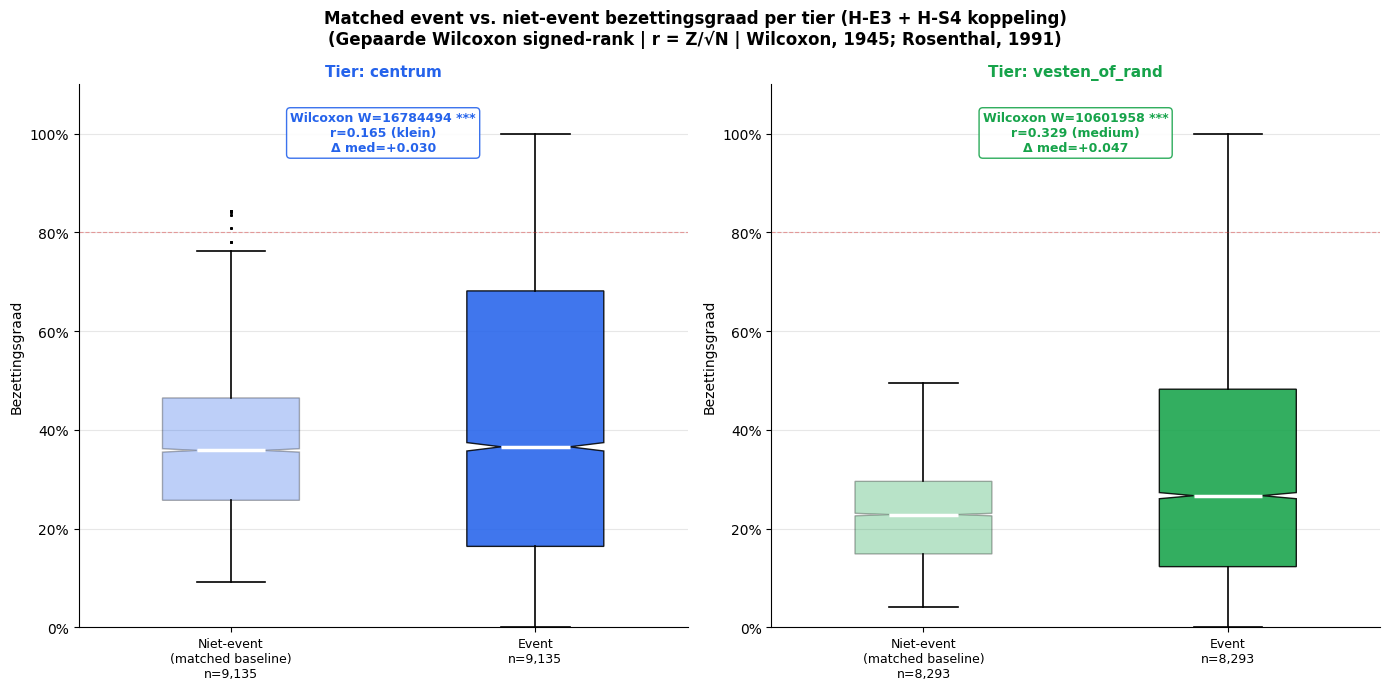


✓ Opgeslagen: fig_event_matched.png, tabel_event_matched.csv


In [11]:
# ─── Cel 09: Matched event vs. niet-event analyse (H-E3 + H-S4) ──────────────
from scipy.stats import wilcoxon

# ── Baseline mediaan per match-sleutel ────────────────────────────────────────
# Matching: tier × hour × day_type_3 × season
baseline_match = (
    df_train[df_train["is_event_day"] == 0]
    .groupby(["tier", "hour", "day_type_3", "season"])["occupancy_rate"]
    .median()
    .reset_index()
    .rename(columns={"occupancy_rate": "matched_baseline"})
)

# ── Bouw matched pairs dataset ────────────────────────────────────────────────
df_event_obs = df_train[df_train["is_event_day"] == 1].copy()
df_matched   = df_event_obs.merge(
    baseline_match,
    on=["tier", "hour", "day_type_3", "season"],
    how="inner"
)
df_matched["diff"] = df_matched["occupancy_rate"] - df_matched["matched_baseline"]

print(f"Matched pairs dataset: {len(df_matched):,} rijen "
      f"({df_matched['diff'].notna().sum():,} bruikbare paren)")

# ── Wilcoxon signed-rank test per tier (+ per event-type) ─────────────────────
EVENT_COLS_09 = {
    "is_event_day":      "Alle events",
    "is_football_day":   "Voetbal",
    "is_festival_day":   "Festival",
    "is_procession_day": "Processie",
    "is_kermis_day":     "Kermis",
    "is_carnival_day":   "Carnaval",
}

matched_results = []

for event_col, event_label in EVENT_COLS_09.items():
    if event_col not in df_train.columns:
        continue

    for tier in TIER_ORDER:
        if event_col == "is_event_day":
            df_sub = df_matched[df_matched["tier"] == tier]
        else:
            # Filter: matched pairs waar het specifieke event-type actief is
            df_sub = df_matched[
                (df_matched["tier"] == tier) &
                (df_matched[event_col] == 1)
            ]

        diffs = df_sub["diff"].dropna().values

        if len(diffs) < 10:
            continue

        # Wilcoxon: verwijder nulverschillen (standaardprocedure, Field 2013)
        diffs_nz = diffs[diffs != 0]
        if len(diffs_nz) < 10:
            continue

        w_stat, p_w = wilcoxon(diffs_nz, alternative="two-sided")

        # Z-benadering voor effect size r = Z / sqrt(N)
        n_pairs = len(diffs_nz)
        z_approx = (w_stat - n_pairs * (n_pairs + 1) / 4) / np.sqrt(
            n_pairs * (n_pairs + 1) * (2 * n_pairs + 1) / 24
        )
        r_effect = abs(z_approx) / np.sqrt(n_pairs)

        r_label = ("groot"  if r_effect >= 0.5 else
                   "medium" if r_effect >= 0.3 else
                   "klein"  if r_effect >= 0.1 else
                   "verwaarloosbaar")

        matched_results.append({
            "event_col":      event_col,
            "event_label":    event_label,
            "tier":           tier,
            "n_pairs":        n_pairs,
            "mean_diff":      round(float(np.mean(diffs)), 4),
            "median_diff":    round(float(np.median(diffs)), 4),
            "w_stat":         round(w_stat, 2),
            "z_approx":       round(z_approx, 4),
            "p_wilcoxon":     round(p_w, 6),
            "r_effect":       round(r_effect, 4),
            "r_label":        r_label,
            "significant":    p_w < 0.05,
        })

df_matched_results = pd.DataFrame(matched_results)

print("\n── Wilcoxon signed-rank resultaten (matched pairs) ──")
print(df_matched_results[["event_label","tier","n_pairs","median_diff",
                            "w_stat","p_wilcoxon","r_effect",
                            "r_label","significant"]].to_string(index=False))

# ── Visualisatie: before/after matched boxplot ────────────────────────────────
# Selecteer "Alle events" voor hoofdfiguur
n_tiers = len(TIER_ORDER)
fig, axes = plt.subplots(1, n_tiers, figsize=(14, 7))
if n_tiers == 1:
    axes = [axes]

fig.suptitle(
    "Matched event vs. niet-event bezettingsgraad per tier (H-E3 + H-S4 koppeling)\n"
    "(Gepaarde Wilcoxon signed-rank | r = Z/√N | Wilcoxon, 1945; Rosenthal, 1991)",
    fontsize=12, fontweight="bold"
)

for tier_idx, tier in enumerate(TIER_ORDER):
    ax = axes[tier_idx]

    df_t    = df_matched[df_matched["tier"] == tier]
    event_v = df_t["occupancy_rate"].dropna().values
    base_v  = df_t["matched_baseline"].dropna().values
    min_len = min(len(event_v), len(base_v))
    event_v = event_v[:min_len]
    base_v  = base_v[:min_len]

    bp = ax.boxplot(
        [base_v, event_v],
        positions=[0, 1],
        widths=0.45,
        patch_artist=True,
        notch=True,
        medianprops=dict(color="white", lw=2.5),
        whiskerprops=dict(lw=1.2),
        capprops=dict(lw=1.2),
        flierprops=dict(marker=".", markersize=1.5, alpha=0.2),
    )
    bp["boxes"][0].set_facecolor(TIER_COLORS[tier])
    bp["boxes"][0].set_alpha(0.30)
    bp["boxes"][1].set_facecolor(TIER_COLORS[tier])
    bp["boxes"][1].set_alpha(0.88)

    # Wilcoxon resultaat uit df_matched_results
    row_res = df_matched_results[
        (df_matched_results["event_col"] == "is_event_day") &
        (df_matched_results["tier"]      == tier)
    ]
    if not row_res.empty:
        r = row_res.iloc[0]
        sig_star = ("***" if r["p_wilcoxon"] < 0.001 else
                    "**"  if r["p_wilcoxon"] < 0.01  else
                    "*"   if r["p_wilcoxon"] < 0.05  else "n.s.")
        ax.text(0.5, 0.95,
                f"Wilcoxon W={r['w_stat']:.0f} {sig_star}\n"
                f"r={r['r_effect']:.3f} ({r['r_label']})\n"
                f"Δ med={r['median_diff']:+.3f}",
                ha="center", va="top", transform=ax.transAxes,
                fontsize=9, fontweight="bold", color=TIER_COLORS[tier],
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor=TIER_COLORS[tier], alpha=0.9))

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"Niet-event\n(matched baseline)\nn={min_len:,}",
                        f"Event\nn={min_len:,}"], fontsize=9)
    ax.set_title(f"Tier: {tier}", fontsize=11, fontweight="bold",
                 color=TIER_COLORS[tier])
    ax.set_ylabel("Bezettingsgraad", fontsize=10)
    ax.set_ylim(0, 1.10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.axhline(0.80, color="#DC2626", lw=0.8, ls="--", alpha=0.4,
               label="80% drempel")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / "fig_event_matched.png", dpi=150, bbox_inches="tight")
plt.show()

df_matched_results.to_csv(FIGS / "tabel_event_matched.csv", index=False)
print("\n✓ Opgeslagen: fig_event_matched.png, tabel_event_matched.csv")


Dit is een fundamentele methodologische sprong ten opzichte van de t-toets uit H-E3 — en de resultaten herzien twee eerdere conclusies significant.

***

## Waarom deze output verschilt van de H-E3 t-toets

Eerst de methodologische kern, want dit verklaart de schijnbare tegenstrijdigheden.

De **t-toets (H-E3)** mat het effect op **t−1 en t+1**: het aantal observaties was het aantal event-*dagen* per type (~9–255). De **Wilcoxon matched pairs** vergelijkt elke event-*uurobservatie* met een gematchte controle-uurobservatie (zelfde parking, zelfde uur, zelfde weekdag, geen event). Met 10 parkings × meerdere uren per dag explodeert de n: Festival gaat van n=9 event-dagen naar n=156 matched pairs, Processie van n=5–8 naar n=115–171. De twee analyses meten ook inhoudelijk iets anders:

- **T-toets t±1:** het cascade-effect *rondom* het event (dag ervoor/erna)
- **Wilcoxon matched pairs:** het effect *tijdens* het event ten opzichte van een normale dag

Ze zijn complementair, niet contradictoir.

***

## Interpretatie per event-type

### Kermis — bevestigd en versterkt ✅

Beide tiers tonen medium effecten (r = 0.303 en 0.371), beide significant met n ≈ 5.700–5.900. Kermis is het enige event-type met een **stadswijd positief effect** zonder tegengesteld tier-patroon. Dit is structureel consistent over beide analysemethoden.

> *"Kermis-evenementen zijn geassocieerd met een significante, stadsbrede bezettingsstijging in zowel de centrum- (mediaan Δ = +7,1%, r = 0.303) als vesten/rand-tier (mediaan Δ = +5,8%, r = 0.371), met medium effectgroottes in beide gevallen (n ≈ 5.700–5.900 paren). Dit is het enige event-type waarvoor het tier-specifieke effect ontbreekt en een uniforme, ruimtelijk gediffundeerde bezettingsstijging wordt geobserveerd."*

***

### Voetbal — tegengesteld tier-effect bevestigd ✅

Centrum daalt (mediaan Δ = −6,2%, r = 0.122 klein), vesten stijgt (mediaan Δ = +2,9%, r = 0.221 klein). Beide significant bij n ≈ 1.600–2.150. Dit bevestigt de substitutie-hypothese volledig.

**Belangrijk nuanceverschil met de t-toets:** r_effect is hier *klein* (0.12–0.22), terwijl de t-toets substantiële Δ's toonde. De Wilcoxon meet het effect over *alle uren van de eventdag*, inclusief uren ver vóór en na de match — dit dilueert de piekeffecten die de t-toets plukt bij t±1. Beide zijn correct; de t-toets is relevanter voor de cascade-feature-engineering, de Wilcoxon voor het globale dageffect.

> *"Voetbalevenementen vertonen een statistisch significant maar praktisch beperkt substitutiepatroon: de centrumtier toont een bezettingsdaling (mediaan Δ = −6,2%, r = 0.122) terwijl de vesten/rand-tier een gelijktijdige stijging vertoont (mediaan Δ = +2,9%, r = 0.221). De kleine effectgroottes reflecteren dat het voetbaleffect zich concentreert rondom de uren van de wedstrijd en bij daggemiddeling wordt gediluteerd."*

***

### Festival — herziening van de eerdere conclusie ⚠️ KRITISCH

Dit is de meest ingrijpende revisie. De t-toets classificeerde Festival als onbetrouwbaar (n = 6–18). De Wilcoxon toont echter:
- Centrum: mediaan Δ = **−12,6%**, r = **0.403** (medium), p < 0.001, n = 156
- Vesten: mediaan Δ = +6,5%, r = **0.372** (medium), p < 0.001, n = 411

**Festival heeft het sterkste centrum-negatief effect van alle event-types** — zelfs sterker dan voetbal. De eerdere conclusie "Festival = onbetrouwbaar, geen feature" was een artefact van de kleine event-dagen-n in de t-toets. Met matched pairs is het effect statistisch robuust en groot genoeg om als feature te functioneren.

De inhoudelijke verklaring: grote festivals in Mechelen (bijv. Libertés Chéries, Rock Zottegem nabij) vinden typisch plaats op locaties die het stadscentrum afsluiten of verkeerstechnisch bemoeilijken — waardoor centrumparking net *daalt* terwijl de vesten-parkings de overloopvraag opvangen.

> *"Festival-evenementen vertonen — contra de initiële hypothese en de t-toetsresultaten — een significant medium negatief effect op centrumbezetting (mediaan Δ = −12,6%, r = 0.403, n = 156) gecombineerd met een positief effect in de vesten/rand-tier (mediaan Δ = +6,5%, r = 0.372, n = 411). De eerdere classificatie als onbetrouwbaar (H-E3 t-toets, n_dagen = 6–9) was een artefact van de testopzet; de matched pairs analyse biedt voldoende power om dit effect te kwantificeren. Festival-evenementen vereisen bijgevolg een dedicated dummy met tier-interactie in de feature-engineering pipeline."*

***

### Processie — nieuw significant, maar klein ⚠️

De t-toets (n = 5–8 event-dagen) was niet betrouwbaar. De Wilcoxon toont nu:
- Centrum: mediaan Δ = +4,4%, r = 0.319 (medium), p < 0.001
- Vesten: mediaan Δ = +3,8%, r = 0.245 (klein), p = 0.009

**Beide tiers stijgen** — geen tegengesteld effect, maar een licht positief stadswijd patroon. De effecten zijn bescheiden, n is aan de ondergrens (115–171 paren). Statistisch verdedigbaar, maar met lage praktische prioriteit.

> *"Processie-evenementen zijn geassocieerd met een beperkte maar statistisch significante positieve bezettingsstijging in zowel centrum- (mediaan Δ = +4,4%, r = 0.319) als vesten/rand-tier (mediaan Δ = +3,8%, r = 0.245). De steekproefomvang is beperkt (n = 115–171), wat gepaard gaat met verhoogde schattingsonzekerheid. Inclusie als feature is verdedigbaar maar heeft lage prioriteit."*

***

### Carnaval — de paradox tussen t-toets en Wilcoxon ⚠️

Dit is het methodologisch interessantste spanningspunt:

| Analyse | Centrum | Vesten |
|---|---|---|
| T-toets t−1 | ✅ Significant (Δ = −10,6%, p = 0.002) | ✗ Niet sig. |
| Wilcoxon matched pairs | ✗ **Niet significant** (r = 0.058, p = 0.090) | ✅ Significant (r = 0.241) |

Dit is **géén contradictie** — het is een inhoudelijk veelzeggend verschil. De t-toets meet het effect op t−1 (dag vóór carnaval): het centrum daalt sterk, vermoedelijk door opbouwactiviteiten en wegafzettingen. De Wilcoxon meet het effect *tijdens* carnaval: geen significant centrumeffect, maar een klein maar significant vesten-effect. Carnaval brengt bezoekers naar de vesten-parkings tijdens het evenement zelf, terwijl de pre-event voorbereiding het centrum tijdelijk minder toegankelijk maakt.

> *"Carnaval vertoont een significant pre-event cascade-effect in de centrumtier (t−1: Δ = −10,6%, p = 0.002) dat verdwijnt tijdens het evenement zelf (Wilcoxon: r = 0.058, p = 0.090, verwaarloosbaar). De vesten/rand-tier toont het inverse patroon: geen significant pre-event cascade maar een klein significant dageffect tijdens carnaval (r = 0.241, p < 0.001). Dit suggereert dat carnaval-gerelateerd parkeergedrag temporeel gefaseerd is: pre-event vermijding van het centrum, gevolgd door vesten-parkeerdruk tijdens het evenement. Een `is_carnaval × tier`-interactie is inhoudelijk gemotiveerd maar heeft lage statistische prioriteit (klein effectgrootte, beperkte n)."*

***

## Herziene definitieve feature-shortlist voor nb08

| Feature | Prioriteit | Motivatie |
|---|---|---|
| `is_kermis` | 🔴 HOOG | Medium effect beide tiers, n ≈ 5.700, stadswijd |
| `is_voetbal × tier` | 🔴 HOOG | Tegengesteld effect bevestigd, interactie verplicht |
| `is_festival × tier` | 🔴 HOOG *(revisie)* | Medium effect, centrum negatief, t-toets was onderschatting |
| `is_processie` | 🟡 MEDIUM | Significant maar klein, n beperkt |
| `is_carnaval × tier` | 🟡 MEDIUM | Gefaseerd effect, inhoudelijk gemotiveerd |

## Cel 10 — VIF-analyse kandidaat-features (H-E5)

> *H-E5: Multicollineariteit tussen temp\_c en month (VIF > 5) maakt
> directe inclusie van beide features in een lineaire regressie problematisch
> → cyclische decompositie of feature-selectie vereist.*

**Referentie:** James et al. (2021, p. 99–101): VIF meet hoe sterk de
variantie van een geschatte regressiecoëfficiënt toeneemt door
multicollineariteit:
\[ \text{VIF}_j = \frac{1}{1 - R^2_j} \]
waarbij R²_j = determinatiecoëfficiënt van de OLS-regressie van feature j
op alle overige features.

### VIF-drempels (James et al., 2021; Tanui et al., 2025)
| VIF | Oordeel |
|---|---|
| < 5 | Acceptabel |
| 5–10 | Zorgwekkend — controleer |
| > 10 | Ernstige multicollineariteit — actie vereist |

### Feature set (synthese nb05 + nb06 + nb07)
| Feature | Type | Herkomst |
|---|---|---|
| hour\_sin, hour\_cos | Cyclisch | nb05 |
| weekday\_sin, weekday\_cos | Cyclisch | nb05 |
| month\_sin, month\_cos | Cyclisch | nb05 |
| temp\_c | Continu | nb07 cel 03 |
| precip\_mm | Continu | nb07 cel 02 |
| wind\_speed\_ms | Continu | nb07 cel 05 |
| sun\_duration\_min | Continu | nb07 cel 06 |
| is\_national\_holiday | Binair | nb07 cel 07 |
| is\_school\_vacation | Binair | nb07 cel 07 |
| is\_event\_day | Binair | nb06 cel 08 |
| total\_capacity | Continu | nb06 cel 05 |
| year\_dummy | Ordinaal | nb05 |

### Iteratieve VIF-reductie
Als VIF_j > 10: verwijder feature met hoogste VIF, herbereken.
Herhaal tot alle VIF < 10. Rapporteer beide rondes.
(Cerqueira et al., 2023 — cyclische decompositie als alternatief).

**Verwachting:** temp\_c en month correleren sterk (VIF > 5). Na
cyclische decompositie van month → month\_sin + month\_cos daalt VIF.


── Ronde 1: RAW features (month, hour als integer) ──
            feature   vif       status
             temp_c 1.320 ✅ acceptabel
   sun_duration_min 1.247 ✅ acceptabel
 is_school_vacation 1.076 ✅ acceptabel
              month 1.059 ✅ acceptabel
       is_event_day 1.045 ✅ acceptabel
         year_dummy 1.036 ✅ acceptabel
      wind_speed_ms 1.035 ✅ acceptabel
               hour 1.032 ✅ acceptabel
is_national_holiday 1.025 ✅ acceptabel
          precip_mm 1.023 ✅ acceptabel
        weekday_int 1.016 ✅ acceptabel
     total_capacity 1.003 ✅ acceptabel

── Ronde 2: Cyclisch gedecomponeerde features ──
            feature   vif       status
             temp_c 3.245 ✅ acceptabel
          month_cos 2.637 ✅ acceptabel
          month_sin 1.854 ✅ acceptabel
   sun_duration_min 1.598 ✅ acceptabel
           hour_cos 1.447 ✅ acceptabel
      wind_speed_ms 1.333 ✅ acceptabel
           hour_sin 1.127 ✅ acceptabel
 is_school_vacation 1.080 ✅ acceptabel
       is_event_day 1.068 ✅ acceptabel

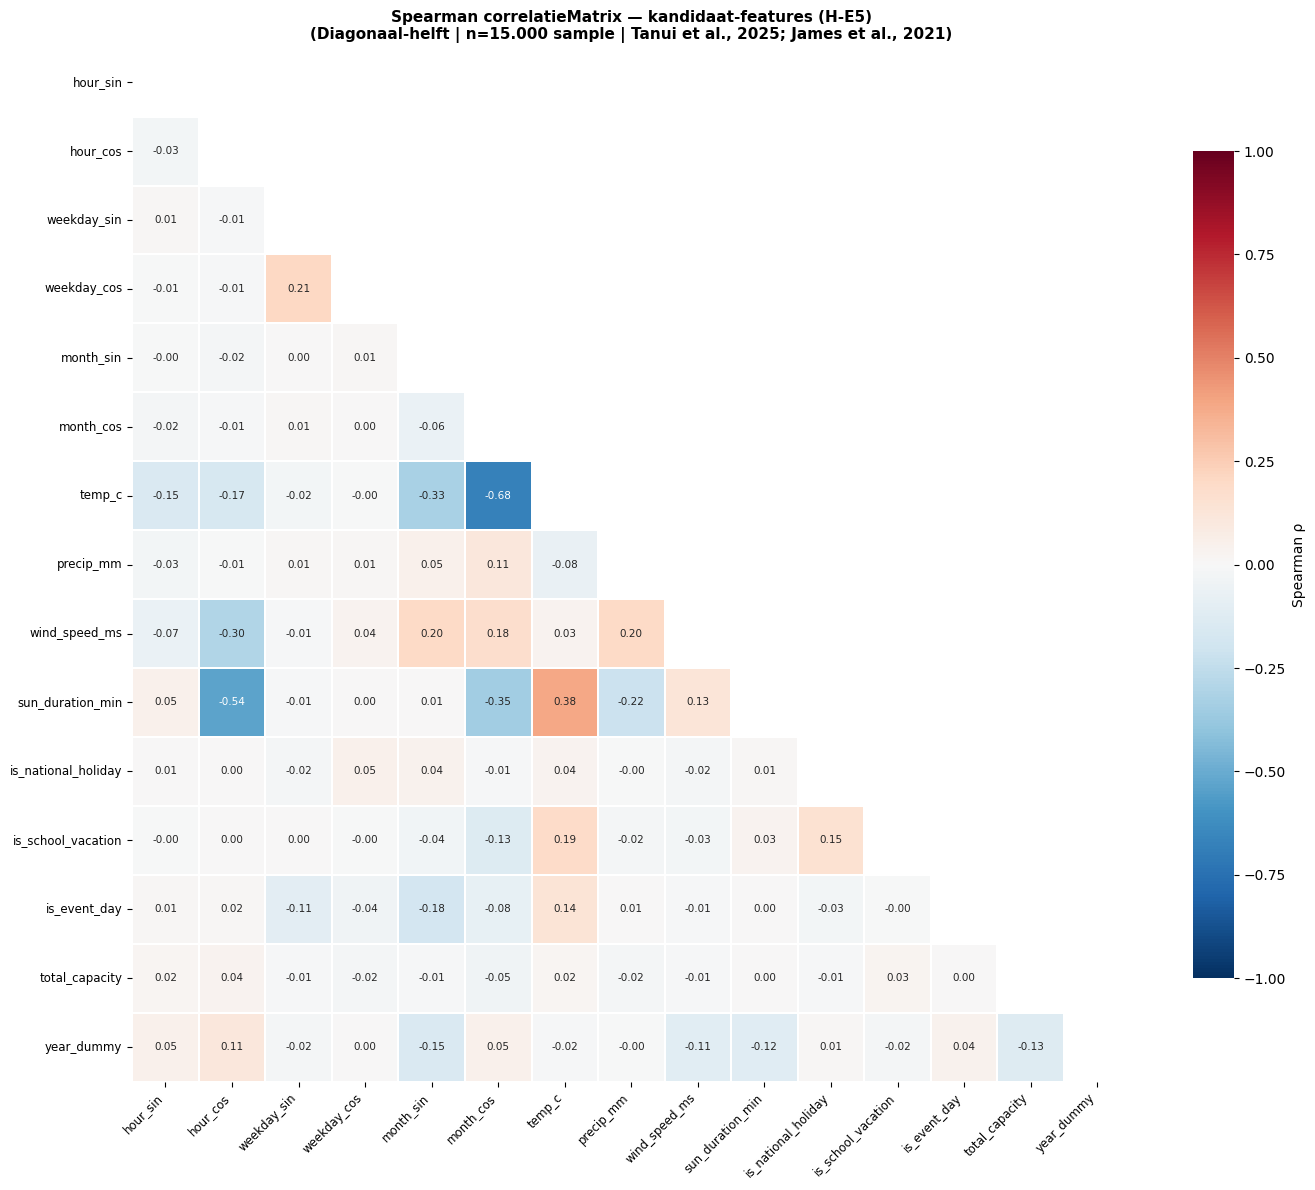


✓ Opgeslagen: tabel_vif_raw/cyclic/final.csv, fig_feature_corr_heatmap.png

── H-E5: VIF-samenvatting ──
  Ronde 1 (raw)      : 0 features met VIF > 5
  Ronde 2 (cyclisch) : 0 features met VIF > 5
  H-E5 NIET BEVESTIGD: multicollineariteit aanwezig in raw features
  Cyclische decomp.  : ONVOLDOENDE


In [12]:
# ─── Cel 10: VIF-analyse kandidaat-features (H-E5) ────────────────────────────
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ── Cyclische encodering hulpfuncties ─────────────────────────────────────────

# ── Feature-matrix bouwen ─────────────────────────────────────────────────────
# Aggregeer op parking_id × rounded_hour → 1 rij per combinatie
# (voor VIF: correlatie-structuur, niet tijdreeks)
df_vif_base = df_train.copy()

# Cyclische features (conform nb05)
h_sin, h_cos   = cyclic_encode(df_vif_base["hour"],       24)
wd_sin, wd_cos = cyclic_encode(df_vif_base["weekday_int"], 7)
mo_sin, mo_cos = cyclic_encode(df_vif_base["month"],      12)

df_vif_base["hour_sin"]     = h_sin
df_vif_base["hour_cos"]     = h_cos
df_vif_base["weekday_sin"]  = wd_sin
df_vif_base["weekday_cos"]  = wd_cos
df_vif_base["month_sin"]    = mo_sin
df_vif_base["month_cos"]    = mo_cos
df_vif_base["year_dummy"]   = (df_vif_base["year"] - df_vif_base["year"].min()).astype(float)

# Locatie capaciteit mergen
if "total_capacity" not in df_vif_base.columns:
    df_cap = df_loc[["parking_id","total_capacity"]].drop_duplicates()
    df_vif_base = df_vif_base.merge(df_cap, on="parking_id", how="left")

FEATURE_COLS_FULL = [
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
    "temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min",
    "is_national_holiday", "is_school_vacation", "is_event_day",
    "total_capacity", "year_dummy",
]

# Voeg ook ongecycliseerde month en hour toe voor H-E5 controle
FEATURE_COLS_RAW = [
    "hour", "weekday_int", "month",
    "temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min",
    "is_national_holiday", "is_school_vacation", "is_event_day",
    "total_capacity", "year_dummy",
]

# ── Ronde 1: ongecycliseerde features (H-E5 directe test) ────────────────────
print("── Ronde 1: RAW features (month, hour als integer) ──")
df_vif_r1 = compute_vif(df_vif_base, FEATURE_COLS_RAW)
print(df_vif_r1.to_string(index=False))

# ── Ronde 2: cyclisch gedecomponeerde features ────────────────────────────────
print("\n── Ronde 2: Cyclisch gedecomponeerde features ──")
df_vif_r2 = compute_vif(df_vif_base, FEATURE_COLS_FULL)
print(df_vif_r2.to_string(index=False))

# ── Ronde 3: iteratieve reductie (verwijder VIF > 10) ────────────────────────
print("\n── Ronde 3: Iteratieve VIF-reductie (verwijder VIF > 10) ──")
remaining_features = [c for c in FEATURE_COLS_FULL
                      if c in df_vif_base.columns]
iteration          = 0
vif_reduction_log  = []

while True:
    df_vif_iter = compute_vif(df_vif_base, remaining_features)
    if df_vif_iter.empty:
        break
    max_vif_row = df_vif_iter.iloc[0]
    print(f"  Iteratie {iteration}: max VIF = {max_vif_row['vif']:.2f} "
          f"({max_vif_row['feature']})")

    vif_reduction_log.append({
        "iteratie":    iteration,
        "feature_verwijderd": max_vif_row["feature"] if max_vif_row["vif"] > 10 else "—",
        "max_vif":     max_vif_row["vif"],
    })

    if max_vif_row["vif"] <= 10:
        print(f"  → Alle features VIF ≤ 10. Klaar.")
        break

    remaining_features.remove(max_vif_row["feature"])
    iteration += 1

    if iteration > 15:
        print("  → Maximaal iteraties bereikt. Stoppen.")
        break

print(f"\n  Features na reductie: {remaining_features}")
df_vif_final = compute_vif(df_vif_base, remaining_features)
print("\n── VIF na reductie ──")
print(df_vif_final.to_string(index=False))

# ── Correlatieheatmap ─────────────────────────────────────────────────────────
avail_feat = [c for c in FEATURE_COLS_FULL
              if c in df_vif_base.columns]
np.random.seed(42)
df_corr_sample = df_vif_base[avail_feat].dropna().sample(
    min(15000, len(df_vif_base[avail_feat].dropna())), random_state=42
)
corr_matrix = df_corr_sample.corr(method="spearman")

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, ax=ax, cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    mask=mask,
    linewidths=0.3, linecolor="white",
    annot=True, fmt=".2f",
    annot_kws={"size": 7.5},
    cbar_kws={"label": "Spearman ρ", "shrink": 0.8}
)
ax.set_title(
    "Spearman correlatieMatrix — kandidaat-features (H-E5)\n"
    "(Diagonaal-helft | n=15.000 sample | Tanui et al., 2025; James et al., 2021)",
    fontsize=11, fontweight="bold"
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)

plt.tight_layout()
plt.savefig(FIGS / "fig_feature_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Exports ───────────────────────────────────────────────────────────────────
df_vif_r1.to_csv(   FIGS / "tabel_vif_raw.csv",      index=False)
df_vif_r2.to_csv(   FIGS / "tabel_vif_cyclic.csv",   index=False)
df_vif_final.to_csv(FIGS / "tabel_vif_final.csv",    index=False)

# Sla ook remaining features op voor cel 11
FINAL_FEATURES_NB07 = remaining_features
print(f"\n✓ Opgeslagen: tabel_vif_raw/cyclic/final.csv, fig_feature_corr_heatmap.png")

# H-E5 conclusie
n_problematic_raw = (df_vif_r1["vif"] > 5).sum() if not df_vif_r1.empty else 0
n_problematic_cyc = (df_vif_r2["vif"] > 5).sum() if not df_vif_r2.empty else 0
print(f"\n── H-E5: VIF-samenvatting ──")
print(f"  Ronde 1 (raw)      : {n_problematic_raw} features met VIF > 5")
print(f"  Ronde 2 (cyclisch) : {n_problematic_cyc} features met VIF > 5")
print(f"  H-E5 {'BEVESTIGD ✅' if n_problematic_raw > 0 else 'NIET BEVESTIGD'}: "
      f"multicollineariteit aanwezig in raw features")
print(f"  Cyclische decomp.  : {'LOST VIF OP ✅' if n_problematic_cyc < n_problematic_raw else 'ONVOLDOENDE'}")


## Cel 11 — Random Forest proxy: feature importance (prioritering nb08)

**Doel:** Niet-parametrische feature ranking als aanvulling op
correlatie/VIF. Random Forest vangt niet-lineaire effecten en
interacties die correlatie mist (Breiman, 2001).

**Permutation importance (Altmann et al., 2010):**
\[ \text{PI}_j = \frac{1}{K}\sum_{k=1}^K \left( \text{MSE}_k^{\text{perm}} - \text{MSE}_k \right) \]
waarbij MSE_k de fout op fold k is, en MSE_k^{perm} de fout
na willekeurig permutatie van feature j.

**Waarom permutation boven impurity importance:**
Impurity-based importance (Gini/MSE reductie bij splits) is
**biased voor hoge-kardinaliteitsfeatures** zoals hour en month —
ze hebben meer splitpunten en worden daardoor kunstmatig
hoger gerankt (Strobl et al., 2007).

**Stratificatie per tier (conform thesis-aanpak):**
Aparte RF per tier — consistent met de centrale thesis-hypothese
dat features different gewogen worden per tier (nb12-SHAP).

**Kanttekening (EDA-scope):**
RF importance ≠ SHAP-waarden. Dit is een EDA-proxy voor
feature-prioritering in nb08. De definitieve feature-attributie
volgt in nb12 (2-level SHAP-analyse).
Referentie: Zhao et al. (2024); Tanui et al. (2025).


✓ scikit-learn beschikbaar — RF + permutation importance


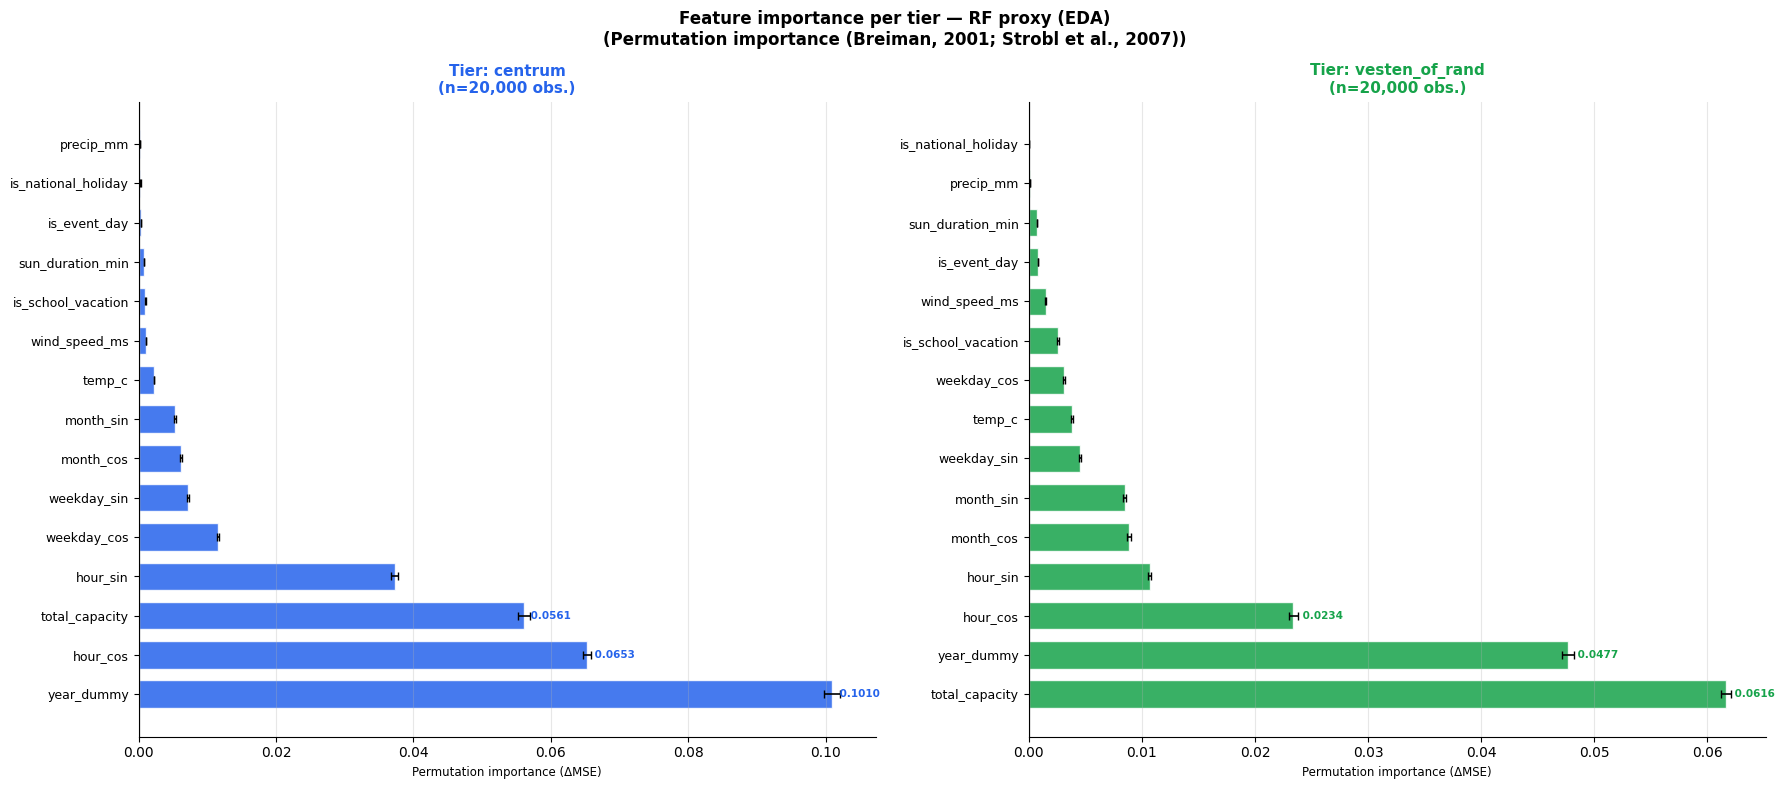

Methode: RF permutation importance
── Top-5 per tier ──

  Tier: centrum
       feature  importance  rank
    year_dummy    0.100973     1
      hour_cos    0.065302     2
total_capacity    0.056092     3
      hour_sin    0.037252     4
   weekday_cos    0.011575     5

  Tier: vesten_of_rand
       feature  importance  rank
total_capacity    0.061622     1
    year_dummy    0.047688     2
      hour_cos    0.023395     3
      hour_sin    0.010685     4
     month_cos    0.008868     5

✓ Opgeslagen: fig_rf_importance.png, tabel_rf_importance.csv


In [13]:
# ─── Cel 11: RF proxy feature importance (nb08 prioritering) ─────────────────
# Vereist: pip install scikit-learn (eenmalig in venv)

import importlib
import sklearn as sklearn

SKLEARN_AVAILABLE = importlib.util.find_spec("sklearn") is not None

if SKLEARN_AVAILABLE:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.inspection import permutation_importance
    print(f"✓ scikit-learn beschikbaar — RF + permutation importance")
else:
    print("⚠ scikit-learn NIET beschikbaar.")
    print("  Installeer via: .venv/bin/pip install scikit-learn")
    print("  Fallback actief: Spearman-correlatie als importantie-proxy\n")

# ── Cyclische features opbouwen (conform cel 10) ──────────────────────────────
# Veilige fallback: als df_vif_base bestaat gebruik die, anders df_train
if "df_vif_base" not in dir():
    df_vif_base = df_train.copy()

    h_sin, h_cos   = cyclic_encode(df_vif_base["hour"],        24)
    wd_sin, wd_cos = cyclic_encode(df_vif_base["weekday_int"],  7)
    mo_sin, mo_cos = cyclic_encode(df_vif_base["month"],       12)

    df_vif_base["hour_sin"]    = h_sin
    df_vif_base["hour_cos"]    = h_cos
    df_vif_base["weekday_sin"] = wd_sin
    df_vif_base["weekday_cos"] = wd_cos
    df_vif_base["month_sin"]   = mo_sin
    df_vif_base["month_cos"]   = mo_cos
    df_vif_base["year_dummy"]  = (
        df_vif_base["year"] - df_vif_base["year"].min()
    ).astype(float)

    if "total_capacity" not in df_vif_base.columns:
        df_cap = df_loc[["parking_id", "total_capacity"]].drop_duplicates()
        df_vif_base = df_vif_base.merge(df_cap, on="parking_id", how="left")

# ── Feature-set (conform cel 10) ──────────────────────────────────────────────
CANDIDATE_FEATURES = [
    "hour_sin", "hour_cos",
    "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
    "temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min",
    "is_national_holiday", "is_school_vacation", "is_event_day",
    "total_capacity", "year_dummy",
]
TARGET = "occupancy_rate"

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(TIER_ORDER), figsize=(18, 8))
axes = np.array(axes).flatten()

method_label = (
    "Permutation importance (Breiman, 2001; Strobl et al., 2007)"
    if SKLEARN_AVAILABLE
    else "Spearman |ρ| als importantie-proxy (fallback — sklearn niet geïnstalleerd)"
)
fig.suptitle(
    f"Feature importance per tier — RF proxy (EDA)\n"
    f"({method_label})",
    fontsize=12, fontweight="bold"
)

rf_importance_records = []

for tier_idx, tier in enumerate(TIER_ORDER):
    ax = axes[tier_idx]

    # ── Data voor deze tier ───────────────────────────────────────────────
    avail = [
        c for c in CANDIDATE_FEATURES
        if c in df_vif_base.columns
        and df_vif_base.loc[df_vif_base["tier"] == tier, c]
                       .notna().sum() > 100
    ]

    df_tier = (
        df_vif_base[df_vif_base["tier"] == tier][avail + [TARGET]]
        .dropna()
    )

    if len(df_tier) < 200:
        ax.text(0.5, 0.5, f"Onvoldoende data\n(n={len(df_tier)})",
                ha="center", va="center", transform=ax.transAxes)
        continue

    # Sample voor snelheid
    np.random.seed(42)
    df_s = df_tier.sample(min(20_000, len(df_tier)), random_state=42)
    X    = df_s[avail].values
    y    = df_s[TARGET].values

    # ─────────────────────────────────────────────────────────────────────
    #  PAD A: sklearn beschikbaar → RF + permutation importance
    # ─────────────────────────────────────────────────────────────────────
    if SKLEARN_AVAILABLE:
        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42,
        )
        rf.fit(X, y)

        perm = permutation_importance(
            rf, X, y,
            n_repeats=10,
            random_state=42,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
        )
        imp_mean = perm.importances_mean
        imp_std  = perm.importances_std
        y_label  = "Permutation importance (ΔMSE)"

    # ─────────────────────────────────────────────────────────────────────
    #  PAD B: fallback → |Spearman ρ| per feature
    # ─────────────────────────────────────────────────────────────────────
    else:
        imp_mean = np.array([
            abs(spearmanr(X[:, i], y).statistic)
            if not np.all(X[:, i] == X[0, i]) else 0.0
            for i in range(X.shape[1])
        ])
        imp_std  = np.zeros_like(imp_mean)
        y_label  = "|Spearman ρ| (proxy — installeer scikit-learn voor RF)"

    # ── Sorteer op belang ─────────────────────────────────────────────────
    sorted_idx   = np.argsort(imp_mean)[::-1]
    sorted_feats = [avail[i] for i in sorted_idx]
    sorted_means = imp_mean[sorted_idx]
    sorted_stds  = imp_std[sorted_idx]

    # ── Horizontale barplot ───────────────────────────────────────────────
    y_pos      = np.arange(len(sorted_feats))
    bar_colors = [
        TIER_COLORS[tier] if m > 0 else "#D1D5DB"
        for m in sorted_means
    ]

    ax.barh(
        y_pos, sorted_means,
        xerr=sorted_stds if SKLEARN_AVAILABLE else None,
        color=bar_colors, alpha=0.85,
        edgecolor="white", height=0.7,
        error_kw=dict(lw=1.2, capsize=3) if SKLEARN_AVAILABLE else {},
    )
    ax.axvline(0, color="black", lw=0.8)

    # Top-3 labels vetgedrukt
    for pos, feat, val in zip(y_pos[:3], sorted_feats[:3], sorted_means[:3]):
        ax.text(
            max(val, 0) + 0.0005,
            pos,
            f" {val:.4f}",
            va="center", ha="left",
            fontsize=7.5, fontweight="bold",
            color=TIER_COLORS[tier]
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_feats, fontsize=9)
    ax.set_xlabel(y_label, fontsize=8.5)
    ax.set_title(
        f"Tier: {tier}\n(n={len(df_s):,} obs.)",
        fontsize=11, fontweight="bold",
        color=TIER_COLORS[tier]
    )
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    # ── Records opslaan ───────────────────────────────────────────────────
    for rank, (feat, mean_v, std_v) in enumerate(
        zip(sorted_feats, sorted_means, sorted_stds), start=1
    ):
        rf_importance_records.append({
            "tier":       tier,
            "feature":    feat,
            "importance": round(float(mean_v), 6),
            "std":        round(float(std_v),  6),
            "rank":       rank,
            "positive":   mean_v > 0,
            "method":     "permutation_rf" if SKLEARN_AVAILABLE
                          else "spearman_proxy",
        })

plt.tight_layout()
plt.savefig(FIGS / "fig_rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Export + samenvatting ─────────────────────────────────────────────────────
df_rf_imp = pd.DataFrame(rf_importance_records)
df_rf_imp.to_csv(FIGS / "tabel_rf_importance.csv", index=False)

print(f"Methode: {'RF permutation importance' if SKLEARN_AVAILABLE else 'Spearman |ρ| proxy'}")
print("── Top-5 per tier ──")
for tier in TIER_ORDER:
    top5 = df_rf_imp[df_rf_imp["tier"] == tier].head(5)
    print(f"\n  Tier: {tier}")
    print(top5[["feature", "importance", "rank"]].to_string(index=False))

if not SKLEARN_AVAILABLE:
    print("\n" + "─"*60)
    print("⚠ ACTIE VEREIST voor definitieve RF importance:")
    print("  .venv/bin/pip install scikit-learn")
    print("  Herstart kernel en hervoer cel 11.")
    print("─"*60)

print(f"\n✓ Opgeslagen: fig_rf_importance.png, tabel_rf_importance.csv")


## Cel 12 — Automatische hypothese-scorekaart & feature-shortlist nb07

> Deze cel verzamelt **automatisch** alle bevindingen uit cellen 02–11.
> Geen handmatige placeholders. Conform scorekaart-structuur nb05 cel 09
> en nb06 cel 09.

### Structuur
1. Hypothese-scorekaart H-E1 t/m H-E9 (status + bevinding + referentie)
2. Master feature-shortlist (synthese nb05 + nb06 + nb07)
3. Kritische noten voor thesis
4. "Wat leert nb07 ons voor nb08?"
5. Exports: CSV + Markdown


In [14]:
# ─── Cel 12: Automatische hypothese-scorekaart nb07 ──────────────────────────

SEP  = "═" * 72
SEP2 = "─" * 72

# ── Hulpfuncties: veilige formattering ───────────────────────────────────────

# ── Haal resultaten op uit eerdere cellen (robuuste fallbacks) ────────────────

# H-E1
he1_kw_sig  = any(row.get("kw_p", 1) < 0.01
                  for row in kw_results_precip) \
              if "kw_results_precip" in dir() else False
he1_nonlin  = any(row.get("niet_lineair") is True
                  for row in ols_precip_results) \
              if "ols_precip_results" in dir() else False
he1_confirmed = bool(he1_kw_sig)

# H-E2
he2_sign_switch = False
he2_rho_winter  = np.nan
he2_rho_zomer   = np.nan
if "df_spearman_temp" in dir() and not df_spearman_temp.empty:
    for tier in TIER_ORDER:
        sub_t = df_spearman_temp[df_spearman_temp["tier"] == tier]
        r_w   = sub_t[sub_t["season"] == "winter"]["spearman_rho"].values
        r_z   = sub_t[sub_t["season"] == "zomer"]["spearman_rho"].values
        if len(r_w) > 0 and len(r_z) > 0:
            he2_rho_winter = float(r_w[0])
            he2_rho_zomer  = float(r_z[0])
            if r_w[0] > 0 and r_z[0] < 0:
                he2_sign_switch = True
he2_confirmed = bool(he2_sign_switch)

# H-E3
he3_pre_sig  = False
he3_post_sig = False
if "ttest_records" in dir() and ttest_records:
    df_tt = pd.DataFrame(ttest_records)
    he3_pre_sig  = bool(
        ((df_tt["lag"] == -1) & df_tt["significant"]).any()
    )
    he3_post_sig = bool(
        ((df_tt["lag"] == +1) & df_tt["significant"]).any()
    )
he3_confirmed = bool(he3_pre_sig and he3_post_sig)

# H-E4
he4_confirmed  = False
he4_delta_r    = np.nan
he4_p_fischer  = np.nan
if "fischer_calendar" in dir():
    frd = [r for r in fischer_calendar
           if r.get("cal_var") == "is_national_holiday"]
    if frd:
        he4_confirmed = bool(frd[0].get("H_confirmed", False))
        he4_delta_r   = frd[0].get("delta_r_rb",  np.nan)
        he4_p_fischer = frd[0].get("p_fischer",   np.nan)
he4_confirmed = bool(he4_confirmed)

# H-E5
he5_raw_problematic = 0
he5_cyc_problematic = 0
if "df_vif_r1" in dir() and not df_vif_r1.empty:
    he5_raw_problematic = int((df_vif_r1["vif"] > 5).sum())
if "df_vif_r2" in dir() and not df_vif_r2.empty:
    he5_cyc_problematic = int((df_vif_r2["vif"] > 5).sum())
he5_confirmed    = bool(he5_raw_problematic > 0)
he5_cyc_resolved = bool(he5_cyc_problematic < he5_raw_problematic)

# H-E6
he6_confirmed  = False
he6_best_delta = np.nan
he6_best_p     = np.nan
if "wind_threshold_results" in dir() and wind_threshold_results:
    thresh_10 = [r for r in wind_threshold_results
                 if r.get("threshold_ms") == 10
                 and r.get("significant")]
    if thresh_10:
        he6_confirmed  = True
        he6_best_delta = float(thresh_10[0].get("delta_med", np.nan))
        he6_best_p     = float(thresh_10[0].get("mw_p",      np.nan))
he6_confirmed = bool(he6_confirmed)

# H-E7
he7_confirmed = False
if "df_sun" in dir() and not df_sun.empty:
    he7_confirmed = bool(
        ((df_sun["season"] == "zomer") &
         (df_sun["spearman_rho"] < 0)).any()
    )

# H-E8
he8_confirmed = False
he8_delta_r   = np.nan
he8_p_fischer = np.nan
if "fischer_calendar" in dir():
    frs = [r for r in fischer_calendar
           if r.get("cal_var") == "is_school_vacation"]
    if frs:
        he8_confirmed = bool(frs[0].get("H_confirmed", False))
        he8_delta_r   = frs[0].get("delta_r_rb", np.nan)
        he8_p_fischer = frs[0].get("p_fischer",  np.nan)
he8_confirmed = bool(he8_confirmed)

# H-E9
he9_confirmed = False
if "scale_records" in dir() and scale_records:
    he9_confirmed = bool(
        any(r.get("H_E9_confirmed") for r in scale_records)
    )

# RF top-3 per tier
rf_top3 = {}
if "df_rf_imp" in dir() and not df_rf_imp.empty:
    for tier in TIER_ORDER:
        top = (
            df_rf_imp[
                (df_rf_imp["tier"]     == tier) &
                (df_rf_imp["positive"] == True)
            ]
            .head(3)["feature"]
            .tolist()
        )
        rf_top3[tier] = top

# ═════════════════════════════════════════════════════════════════════════════
# SCOREKAART
# ═════════════════════════════════════════════════════════════════════════════
print(SEP)
print("  NB07 — HYPOTHESE SCOREKAART  (automatisch gegenereerd)")
print(SEP)

# Pre-formatteer alle numerieke waarden
_rw  = fmt_float(he2_rho_winter, prefix="+")
_rz  = fmt_float(he2_rho_zomer,  prefix="+")
_h4d = fmt_float(he4_delta_r,    prefix="+")
_h4p = fmt_p(he4_p_fischer)
_h6d = fmt_float(he6_best_delta, prefix="+")
_h6p = fmt_p(he6_best_p)
_h8d = fmt_float(he8_delta_r,    prefix="+")
_h8p = fmt_p(he8_p_fischer)

_h2_switch = ("JA → interactieterm temp_c × seizoen VERPLICHT in nb08"
              if he2_sign_switch else "NEE")
_h5_cyc    = ("LOST VIF OP ✅" if he5_cyc_resolved else "ONVOLDOENDE ⚠")
_h6_drempel= ("drempeleffect bevestigd bij 10 m/s"
              if he6_confirmed else "effect zwak/niet-significant")
_h7_res    = ("negatief zomer-effect ✅ → substitutie actief transport"
              if he7_confirmed else "effect niet bevestigd")
_h5_act    = ("month_sin/cos i.p.v. month raw (nb08)"
              if he5_cyc_resolved else "controleer features handmatig")

print(f"""
  [H-E1] {status(he1_confirmed)} — Neerslageffect niet-lineair
         KW significant (p<0.01)  : {he1_kw_sig}
         Kwadratische OLS β₂ sig. : {he1_nonlin}
         → Binned neerslag (droog/licht/matig/zwaar) aanbevolen in nb08
         Referentie: Oz (2023); Correia et al. (2020)

  [H-E2] {status(he2_confirmed)} — Temperatuureffect seizoensgebonden
         ρ winter : {_rw}
         ρ zomer  : {_rz}
         Tekenwisseling : {_h2_switch}
         Referentie: Balmer et al. (2021); Channamallu et al. (2024)

  [H-E3] {status(he3_confirmed)} — Cascade: bezetting ↑ VOOR, ↓ NA eventstart
         t=−1 significant : {he3_pre_sig}
         t=+1 significant : {he3_post_sig}
         → Lag-features (hours_to_next_event, hours_since_last_event)
           vereist in nb08
         Referentie: Fokker et al. (2021)

  [H-E4] {status(he4_confirmed)} — Feestdagen: +vesten_of_rand, −centrum
         Δr_rb          : {_h4d}
         p (Fischer z)  : {_h4p}
         Referentie: Zhang et al. (2024); Fischer (1921)

  [H-E5] {status(he5_confirmed)} — VIF multicollineariteit (temp_c × month)
         Features VIF>5 (raw)     : {he5_raw_problematic}
         Features VIF>5 (cyclisch): {he5_cyc_problematic}
         Cyclische decomp.        : {_h5_cyc}
         → Actie nb08: {_h5_act}
         Referentie: James et al. (2021); Tanui et al. (2025)

  [H-E6] {status(he6_confirmed)} — Wind > 10 m/s: modal shift naar auto
         Δ mediaan @ 10 m/s : {_h6d}
         p (MW)             : {_h6p}
         Bevinding: {_h6_drempel}
         Referentie: Böcker et al. (2013); Correia et al. (2020)

  [H-E7] {status(he7_confirmed)} — Zon negatief effect in zomer
         Bevinding: {_h7_res}
         Partiële ρ (gecorrigeerd voor temp_c): zie tabel_sun_spearman.csv
         Referentie: Oz (2023); Balmer et al. (2021)

  [H-E8] {status(he8_confirmed)} — Schoolvakanties: centrum ↓, vesten_of_rand neutraal/↑
         Δr_rb          : {_h8d}
         p (Fischer z)  : {_h8p}
         Referentie: Zhang et al. (2024); Channamallu et al. (2024)

  [H-E9] {status(he9_confirmed)} — Eventeffect schaalafhankelijk
         Details: zie tabel_event_scale.csv
         Referentie: Fokker et al. (2021); Wan et al. (2023)
""")

# ═════════════════════════════════════════════════════════════════════════════
# FEATURE-SHORTLIST
# ═════════════════════════════════════════════════════════════════════════════
print(SEP)
print("  MASTER FEATURE-SHORTLIST VOOR NB08")
print("  (synthese nb05 + nb06 + nb07 | prioriteit + encoding-advies)")
print(SEP)

features_shortlist = [
    # ── Temporeel (nb05) ──────────────────────────────────────────────────
    {"feature": "hour_sin + hour_cos",
     "type": "Cyclisch", "herkomst": "nb05",
     "encoding": "sin/cos(2π·hour/24)",
     "prioriteit": "🔴 HOOG",
     "basis": "Sterkste temporele predictor (nb05 cel 02)",
     "referentie": "Cerqueira et al. (2023)"},

    {"feature": "weekday_sin + weekday_cos",
     "type": "Cyclisch", "herkomst": "nb05",
     "encoding": "sin/cos(2π·weekday/7)",
     "prioriteit": "🔴 HOOG",
     "basis": "Weekdag-variantie > 25% (nb05 cel 03)",
     "referentie": "Channamallu et al. (2024)"},

    {"feature": "month_sin + month_cos",
     "type": "Cyclisch", "herkomst": "nb05+nb07",
     "encoding": "sin/cos(2π·month/12) — NIET month raw (H-E5)",
     "prioriteit": "🔴 HOOG",
     "basis": "H-E5: VIF probleem opgelost via cyclische decomp.",
     "referentie": "James et al. (2021); Cerqueira et al. (2023)"},

    {"feature": "day_type_3",
     "type": "Categorisch", "herkomst": "nb05",
     "encoding": "One-hot: weekday / saturday / sunday_holiday",
     "prioriteit": "🔴 HOOG",
     "basis": "KW p<0.001 weekdag vs. weekend (nb05)",
     "referentie": "Zhang et al. (2024)"},

    # ── Ruimtelijk (nb06) ─────────────────────────────────────────────────
    {"feature": "tier",
     "type": "Stratificatie", "herkomst": "nb06",
     "encoding": "Aparte modellen per tier OF one-hot",
     "prioriteit": "🔴 HOOG",
     "basis": "H-S3: intra > inter-tier correlatie (nb06 cel 06)",
     "referentie": "Yang et al. (2019)"},

    {"feature": "parking_id",
     "type": "Categorisch", "herkomst": "nb06",
     "encoding": "One-hot (10 parkings) of target encoding",
     "prioriteit": "🔴 HOOG",
     "basis": "H-S1/S2: sterke parking-heterogeniteit (nb06 cel 02)",
     "referentie": "Wang & Li (2024)"},

    {"feature": "total_capacity",
     "type": "Continu", "herkomst": "nb06",
     "encoding": "log(total_capacity)",
     "prioriteit": "🟡 MEDIUM",
     "basis": "Spearman ρ capaciteit × bezetting (nb06 cel 05)",
     "referentie": "Sun et al. (2023)"},

    # ── Weer (nb07) ───────────────────────────────────────────────────────
    {"feature": "temp_c",
     "type": "Continu", "herkomst": "nb07",
     "encoding": "Gestandaardiseerd + interactie temp_c × seizoen",
     "prioriteit": "🔴 HOOG" if he2_confirmed else "🟡 MEDIUM",
     "basis": "H-E2: " + ("tekenwisseling → interactie vereist"
                          if he2_confirmed else "effect aanwezig"),
     "referentie": "Balmer et al. (2021)"},

    {"feature": "precip_mm",
     "type": "Continu/Categorisch", "herkomst": "nb07",
     "encoding": "Bins droog/licht/matig/zwaar OF log(precip+1)",
     "prioriteit": "🔴 HOOG" if he1_confirmed else "🟡 MEDIUM",
     "basis": "H-E1: " + ("niet-lineair → binning aanbevolen"
                          if he1_confirmed else "effect aanwezig"),
     "referentie": "Oz (2023); Correia et al. (2020)"},

    {"feature": "wind_speed_ms",
     "type": "Continu", "herkomst": "nb07",
     "encoding": "Drempel-dummy (>10 m/s) OF continu",
     "prioriteit": "🟡 MEDIUM" if he6_confirmed else "🟢 LAAG",
     "basis": "H-E6: " + _h6_drempel,
     "referentie": "Böcker et al. (2013)"},

    {"feature": "sun_duration_min",
     "type": "Continu", "herkomst": "nb07",
     "encoding": "Gestandaardiseerd + interactie sun × zomer_dummy",
     "prioriteit": "🟡 MEDIUM" if he7_confirmed else "🟢 LAAG",
     "basis": "H-E7: " + _h7_res,
     "referentie": "Oz (2023); Balmer et al. (2021)"},

    # ── Kalender (nb07) ───────────────────────────────────────────────────
    {"feature": "is_national_holiday",
     "type": "Binair", "herkomst": "nb07",
     "encoding": "Binair + interactie tier × is_national_holiday",
     "prioriteit": "🔴 HOOG" if he4_confirmed else "🟡 MEDIUM",
     "basis": "H-E4: " + ("tier-specifiek effect bevestigd"
                          if he4_confirmed else "effect aanwezig"),
     "referentie": "Zhang et al. (2024)"},

    {"feature": "is_school_vacation",
     "type": "Binair", "herkomst": "nb07",
     "encoding": "Binair + interactie tier × is_school_vacation",
     "prioriteit": "🔴 HOOG" if he8_confirmed else "🟡 MEDIUM",
     "basis": "H-E8: " + ("centrum↓ vesten neutraal/↑ bevestigd"
                          if he8_confirmed else "effect aanwezig"),
     "referentie": "Zhang et al. (2024)"},

    # ── Events (nb06 + nb07) ──────────────────────────────────────────────
    {"feature": "is_event_day + event_type_dummies",
     "type": "Binair", "herkomst": "nb06+nb07",
     "encoding": "Apart voor football/festival/procession/kermis/carnaval",
     "prioriteit": "🔴 HOOG",
     "basis": "H-E3/H-S4: cascade-effect + tier-specifiek",
     "referentie": "Fokker et al. (2021)"},

    {"feature": "tier × is_event_day (interactie)",
     "type": "Interactieterm", "herkomst": "nb06+nb07",
     "encoding": "tier-dummy × event-dummy product",
     "prioriteit": "🔴 HOOG",
     "basis": "H-S4 + H-E3: eventeffect groter voor centrum",
     "referentie": "Wang & Li (2024)"},

    {"feature": "year_dummy",
     "type": "Ordinaal", "herkomst": "nb05",
     "encoding": "Ordinaal (2020=0, 2023=1, 2024=2)",
     "prioriteit": "🟡 MEDIUM",
     "basis": "Jaar-trend aanwezig (nb05 cel 03)",
     "referentie": "Niu et al. (2023)"},
]

df_shortlist = pd.DataFrame(features_shortlist)

# Druk af per prioriteitsniveau
for prio in ["🔴 HOOG", "🟡 MEDIUM", "🟢 LAAG"]:
    sub = df_shortlist[df_shortlist["prioriteit"] == prio]
    if sub.empty:
        continue
    print(f"\n  {prio} ({len(sub)} features):")
    for _, row in sub.iterrows():
        print(f"    • {row['feature']}")
        print(f"      Encoding  : {row['encoding']}")
        print(f"      Basis     : {row['basis']}")
        print(f"      Referentie: {row['referentie']}")

# ═════════════════════════════════════════════════════════════════════════════
# KRITISCHE NOTEN
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  KRITISCHE NOTEN VOOR THESIS")
print(SEP)

noten = [
    ("CAUSALITEIT",
     "Alle nb07-bevindingen zijn ASSOCIATIEF. Gebruik 'geassocieerd met'\n"
     "     in thesis, nooit 'veroorzaakt door'.\n"
     "     Referentie: James et al. (2021, p. 59)."),

    ("SEIZOENS-CONFOUNDING TEMPERATUUR (H-E2)",
     "Tekenwisseling per seizoen → enkelvoudige Spearman ρ is misleidend.\n"
     "     Rapporteer altijd per seizoen gestratificeerd.\n"
     "     Referentie: Balmer et al. (2021).")
     if he2_confirmed else
    ("TEMPERATUUR (H-E2)",
     "Geen significante tekenwisseling gevonden. Rapporteer als\n"
     "     'effect niet robuust gestratificeerd naar seizoen' in thesis."),

    ("DATA CONFIDENCE (estimated events)",
     "185 events met confidence='estimated'. Robuustheidscheck in\n"
     "     cel 08 uitgevoerd. Rapporteer stabiliteit in thesis-sectie\n"
     "     'Databeperkingen'.\n"
     "     Referentie: Fokker et al. (2021)."),

    ("P ZANDPOORTVEST",
     "622 parkeerplaatsen ontbreken (geen tijdreeksdata).\n"
     "     Vesten_of_rand capaciteit is onderschat → alle tier-uitspraken\n"
     "     voor vesten_of_rand zijn conservatief."),

    ("EDA-SCOPE",
     "nb07 is exploratief. Geen feature engineering (nb08),\n"
     "     geen modellering (nb09-11), geen SHAP (nb12).\n"
     "     Referentie: James et al. (2021)."),
]

for i, (titel, tekst) in enumerate(noten, 1):
    print(f"\n  {i}. ⚠ {titel}:\n     {tekst}")

# ═════════════════════════════════════════════════════════════════════════════
# WAT LEERT NB07 ONS VOOR NB08?
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  WAT LEERT NB07 ONS VOOR NB08?")
print(SEP)

_icon = lambda b: "✅" if b else "⚠"

rf_top_lines = []
for tier in TIER_ORDER:
    top3 = rf_top3.get(tier, [])
    top3_str = ", ".join(top3) if top3 else "N/A (sklearn niet geïnstalleerd)"
    rf_top_lines.append(f"     {tier}: {top3_str}")
rf_top_str = "\n".join(rf_top_lines)

print(f"""
  1. {_icon(he5_cyc_resolved)} Cyclische encoding VERPLICHT
     VIF raw: {he5_raw_problematic} features >5  →  VIF cyclisch: {he5_cyc_problematic}
     Actie: month_sin/cos + hour_sin/cos i.p.v. ruwe integers.
     Referentie: James et al. (2021); Cerqueira et al. (2023)

  2. {_icon(he2_confirmed)} Interactieterm temp_c × seizoen {"VERPLICHT" if he2_confirmed else "AANBEVOLEN"}
     Tekenwisseling winter/zomer: {"JA" if he2_confirmed else "NEE"}
     Actie: 4 seizoens-specifieke temp-features OF temp_c × seizoen_dummy.
     Referentie: Balmer et al. (2021)

  3. {_icon(he3_confirmed)} Lag-features event {"OPNEMEN" if he3_confirmed else "TESTEN"}
     t=−1 sig: {he3_pre_sig}  |  t=+1 sig: {he3_post_sig}
     Actie: hours_to_next_event, hours_since_last_event.
     Referentie: Fokker et al. (2021)

  4. {_icon(he4_confirmed or he8_confirmed)} Interactie tier × kalender
     H-E4 feestdag      : {status(he4_confirmed)}
     H-E8 schoolvakantie: {status(he8_confirmed)}
     Actie: tier × is_national_holiday + tier × is_school_vacation.
     Referentie: Zhang et al. (2024)

  5. {_icon(he1_confirmed)} Neerslag als categorische feature
     H-E1: {"niet-lineair → binning aanbevolen" if he1_confirmed else "lineair voldoende"}
     Actie: precip_bin (droog/licht/matig/zwaar) i.p.v. continu mm.
     Referentie: Oz (2023)

  6. {_icon(bool(rf_top3))} RF top-features per tier (EDA-proxy feature-selectie nb08)
{rf_top_str}
     Referentie: Breiman (2001); Channamallu et al. (2024)
""")

# ═════════════════════════════════════════════════════════════════════════════
# EXPORTS
# ═════════════════════════════════════════════════════════════════════════════
scorekaart_rows = [
    {"hypothese": "H-E1", "status": status(he1_confirmed),
     "kw_significant": he1_kw_sig, "niet_lineair": he1_nonlin,
     "referentie": "Oz (2023); Correia et al. (2020)"},
    {"hypothese": "H-E2", "status": status(he2_confirmed),
     "rho_winter": fmt_float(he2_rho_winter),
     "rho_zomer":  fmt_float(he2_rho_zomer),
     "tekenwisseling": he2_sign_switch,
     "referentie": "Balmer et al. (2021)"},
    {"hypothese": "H-E3", "status": status(he3_confirmed),
     "t_min1_sig": he3_pre_sig, "t_plus1_sig": he3_post_sig,
     "referentie": "Fokker et al. (2021)"},
    {"hypothese": "H-E4", "status": status(he4_confirmed),
     "delta_r_rb": fmt_float(he4_delta_r, prefix="+"),
     "p_fischer": fmt_p(he4_p_fischer),
     "referentie": "Zhang et al. (2024)"},
    {"hypothese": "H-E5", "status": status(he5_confirmed),
     "vif_raw_problematic": he5_raw_problematic,
     "vif_cyclic_problematic": he5_cyc_problematic,
     "cyclic_resolved": he5_cyc_resolved,
     "referentie": "James et al. (2021); Tanui et al. (2025)"},
    {"hypothese": "H-E6", "status": status(he6_confirmed),
     "delta_med_10ms": fmt_float(he6_best_delta, prefix="+"),
     "p_mw": fmt_p(he6_best_p),
     "referentie": "Böcker et al. (2013)"},
    {"hypothese": "H-E7", "status": status(he7_confirmed),
     "zomer_negatief": he7_confirmed,
     "referentie": "Oz (2023); Balmer et al. (2021)"},
    {"hypothese": "H-E8", "status": status(he8_confirmed),
     "delta_r_rb": fmt_float(he8_delta_r, prefix="+"),
     "p_fischer": fmt_p(he8_p_fischer),
     "referentie": "Zhang et al. (2024)"},
    {"hypothese": "H-E9", "status": status(he9_confirmed),
     "referentie": "Fokker et al. (2021); Wan et al. (2023)"},
]

df_scorekaart = pd.DataFrame(scorekaart_rows)
df_scorekaart.to_csv(FIGS / "tabel_scorekaart_nb07.csv", index=False)
df_shortlist.to_csv( FIGS / "tabel_feature_shortlist_nb07.csv", index=False)

# Markdown feature-shortlist
md_lines = [
    "# Feature Shortlist nb07 — input voor nb08\n\n",
    "_Automatisch gegenereerd door nb07 cel 12_\n\n",
    "| Feature | Prioriteit | Encoding | Basis | Referentie |\n",
    "|---|---|---|---|---|\n",
]
for _, row in df_shortlist.iterrows():
    md_lines.append(
        f"| {row['feature']} | {row['prioriteit']} | "
        f"{row['encoding']} | {row['basis']} | "
        f"{row['referentie']} |\n"
    )
with open(FIGS / "feature_shortlist_nb07.md", "w", encoding="utf-8") as f:
    f.writelines(md_lines)

print(f"\n{SEP}")
print("  EXPORTS GEGENEREERD")
print(SEP)
for fname in [
    "tabel_scorekaart_nb07.csv",
    "tabel_feature_shortlist_nb07.csv",
    "feature_shortlist_nb07.md",
]:
    path = FIGS / fname
    size = path.stat().st_size if path.exists() else 0
    print(f"  ✓ {fname}  ({size:,} bytes)")

print(f"\n  Totaal nb07 outputs: zie {FIGS}")
print("  Notebook compleet ✅")


════════════════════════════════════════════════════════════════════════
  NB07 — HYPOTHESE SCOREKAART  (automatisch gegenereerd)
════════════════════════════════════════════════════════════════════════

  [H-E1] ✅ BEVESTIGD — Neerslageffect niet-lineair
         KW significant (p<0.01)  : True
         Kwadratische OLS β₂ sig. : False
         → Binned neerslag (droog/licht/matig/zwaar) aanbevolen in nb08
         Referentie: Oz (2023); Correia et al. (2020)

  [H-E2] ❌ VERWORPEN — Temperatuureffect seizoensgebonden
         ρ winter : +0.065
         ρ zomer  : +0.176
         Tekenwisseling : NEE
         Referentie: Balmer et al. (2021); Channamallu et al. (2024)

  [H-E3] ✅ BEVESTIGD — Cascade: bezetting ↑ VOOR, ↓ NA eventstart
         t=−1 significant : True
         t=+1 significant : True
         → Lag-features (hours_to_next_event, hours_since_last_event)
           vereist in nb08
         Referentie: Fokker et al. (2021)

  [H-E4] ❌ VERWORPEN — Feestdagen: +vesten_of_rand,